# Анализ влияния халвингов и институционального капитала на цикличность и стратегии крипторынка на примере Bitcoin


## 1. Цель анализа
Изучить, как менялись волатильность, структура ликвидности и ценовые паттерны Bitcoin в разные рыночные эры (до институционалов, ранняя институционализация, эра ETF) и в разные циклы халвинга. Оценить, связано ли появление фьючерсов CME и спотовых BTC ETF со структурными сдвигами на рынке.

### 1.1. Аналитические вопросы (6 гипотез)
1. **Волатильность по халвинг-циклам:** Меняется ли волатильность между циклами халвинга?
2. **Доля фьючерсов CME по эрам:** Как меняется доля фьючерсов CME по рыночным эрам?
3. **Корреляция притоков ETF и дневной доходности BTC:** Связана ли дневная доходность BTC с притоками в спотовые ETF?
4. **Кумулятивный приток ETF vs цена BTC:** Как соотносятся кумулятивный приток ETF и цена BTC?
5. **Фьючерсный спред (премия/дисконт):** Как меняется фьючерсный спред (премия/дисконт) по эрам и циклам?
6. **Корреляция доходности спота и объёма фьючерсов по эрам:** Связан ли объём фьючерсов CME с дневной доходностью спота?

### 1.2. Предметная область
Криптоаналитика, рынок BTC, макро-циклы Bitcoin (halving cycles), деривативы (CME Futures), институциональные потоки (Spot Bitcoin ETF), временные ряды (daily frequency).

## 2. Описание входных данных

- **Источник:** сводный датасет `btc_comprehensive_analysis.csv`
- **Период:** сентябрь 2014 — февраль 2026 (daily frequency)
- **Объём:** 4175 строк, 20 столбцов
- **Состав данных:** Подгтовка и слияние сводного датасета производилась в других ноутбуках поэтапно. В данном ноутбуке работа ведетсся уже с готовым объединенным датасетом. При объединении используется `left join` по базовому спотовому датасету, чтобы сохранить непрерывность временного ряда с 2014 года.
  - Спотовые котировки BTC (OHLCV) — базовый датасет из Kaggle в формате .csv (сентябрь 2014 - февраль 2026), https://www.kaggle.com/datasets/adilshamim8/bitcoin-historical-data/data;
  - Фьючерсные метрики CME (тикер BTC=F) — Yahoo Finance (с декабря 2017), скачивание рыночных данных и финансовой отчетности с веб-ресурса Yahoo Finance с помощью библиотеки yfinance;
  - Потоки капитала спотовых BTC ETF — Farside Investors (с января 2024), парсинг HTML с сайта https://farside.co.uk/bitcoin-etf-flow-all-data/.
- **Единица наблюдения:** один торговый день.
- **Ключевые поля:** `Date`, `Close`, `market_era`, `halving_cycle`, `Volatility_Pct`, `Daily_Return_Pct`, `Futures_Share_Pct`, `Futures_Spread_Pct`, `ETF_Total_Net_Flow_mln_usd`.
- **Расчетные признаки:** Впроцессе подготовки итогового датасета добавлены дополнительные расчетные признаки и итоговый датасет дополнен новыми столбцами:
  - `Volatility_Pct`- Дневная волатильность (%),
  - `Daily_Return_Pct` - Дневная доходность спота (%),
  - `Futures_Share_Pct`- Доля фьючерсов в общем обороте (%),
  - `Futures_Spread_Pct`- Фьючерсный спред / премия-дисконт (%).
- **Категориальные признаки:** Впроцессе подготовки итогового датасета добавлены дополнительные категориальные признаки и итоговый датасет дополнен новыми столбцами:
  - `market_era` (3 рыночные эры),
  - `halving_cycle` (4 цикла халвинга).

## 3. Импорт библиотек

Подключение `pandas`, `numpy`, `matplotlib`, `seaborn`, `yfinance`, `pathlib`, `requests`, `io`. 

Настройка стиля графиков и параметров отображения.

### Что делают основные библиотеки
- **pandas:** — загружает таблицы, преобразует столбцы, группирует данные и рассчитывает показатели;
- **numpy:** — выполняет численные операции и помогает работать с массивами;
- **matplotlib:** — создаёт базовые графики и итоговый дашборд;
- **seaborn:** — упрощает построение статистических графиков и тепловых карт;
- **yfinance** - скачивает рыночные данные и финансовые отчеты с веб-сервиса Yahoo Finance;
- **pathlib.Path:** — формирует пути к файлам независимо от операционной системы;
- **requests** - отправляет HTTP-запросы к веб-серверам;
- **io** - встроенный стандартный модуль для работы с потоковыми данными.

In [1]:
# ==============================================================================
# 3. Импорт библиотек и настройка окружения
# ==============================================================================

try:
    # Основные библиотеки для обработки данных
    import pandas as pd
    import numpy as np

    # Библиотеки для визуализации
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Библиотека для безопасной и кроссплатформенной работы с путями к файлам
    from pathlib import Path

    # Библиотека yfinance для загрузки данных с сервиса Yahoo Finance
    import yfinance as yf

    # Библиотека и встроенный модуль для парсинга HTML
    import requests
    import io

    # ------------------------------------------------------------------------------
    # Настройка параметров отображения pandas
    # ------------------------------------------------------------------------------
    # Показывать все столбцы (в нашем датасете их 20, 30 — безопасный лимит)
    pd.set_option('display.max_columns', 30)
    # Ограничить количество выводимых строк при просмотре df.head() / df.tail()
    pd.set_option('display.max_rows', 100)
    # Округлять числа с плавающей точкой до 2 знаков для удобства чтения в консоли
    pd.set_option('display.float_format', lambda x: '%.2f' % x)

    # ------------------------------------------------------------------------------
    # Настройка стиля графиков (matplotlib и seaborn)
    # ------------------------------------------------------------------------------
    # Устанавливаем чистый стиль с сеткой и приятную цветовую палитру
    sns.set_theme(style="whitegrid", palette="muted")

    # Глобальные параметры matplotlib для единообразия всех графиков в notebook
    plt.rcParams['figure.figsize'] = (12, 6)  # Стандартный размер: 12 дюймов в ширину, 6 в высоту
    plt.rcParams['font.size'] = 12            # Базовый размер шрифта для читаемости
    plt.rcParams['axes.titlesize'] = 14       # Размер заголовка графика

    # ВАЖНО для русскоязычных отчетов:
    # Настройка шрифтов, чтобы вместо кириллицы не отображались "квадратики"
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [
        'Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif'
    ]
    # Корректное отображение знака минуса на графиках при смене шрифта
    plt.rcParams['axes.unicode_minus'] = False

    # Если код дошёл до этой строки, значит все импорты и настройки прошли успешно
    print("✅ Библиотеки установлены и настроены корректно.")

except ImportError as e:
    # Сработает, если какой-то из модулей (pandas, numpy, matplotlib, seaborn) не установлен
    print(f"❌ Ошибка: не удалось импортировать библиотеки. Проверьте установку. Детали: {e}")
    
except Exception as e:
    # Сработает при любых других непредвиденных ошибках (например, конфликт версий при настройке sns)
    print(f"❌ Ошибка при настройке окружения: {e}")

✅ Библиотеки установлены и настроены корректно.


## 4. Загрузка данных
Загрузка объединенного и подготовленного итогового датасета `btc_comprehensive_analysis.csv`

In [2]:
# ==============================================================================
# 4. Загрузка данных
# ==============================================================================

# Указываем имя файла. 
# Лучше выносить его в переменную, чтобы при изменении имени файла 
# править код только в одном месте.
file_path = "btc_comprehensive_analysis.csv"

try:
    # Читаем CSV-файл и сохраняем его в переменную df (DataFrame)
    df = pd.read_csv(file_path)
    
    # Если код дошел до этой строки, значит ошибок не было. 
    # Выводим сообщение об успехе и размер таблицы для быстрой проверки.
    print(f"✅ Данные успешно загружены из файла: '{file_path}'")
    print(f"📊 Размер датасета: {df.shape[0]} строк и {df.shape[1]} столбцов")
    
except FileNotFoundError:
    # Этот блок сработает, если Python не может найти файл по указанному пути
    print(f"❌ Ошибка: файл '{file_path}' не найден.")
    print("💡 Проверьте, что файл лежит в той же папке, что и этот Jupyter Notebook.")
    
except Exception as e:
    # Этот блок перехватит любые другие непредвиденные ошибки
    print(f"❌ Произошла ошибка при загрузке данных: {e}")

✅ Данные успешно загружены из файла: 'btc_comprehensive_analysis.csv'
📊 Размер датасета: 4175 строк и 20 столбцов


## 5. Первичный осмотр
После загрузки проверяются:
- размер таблицы `df.shape`, `df.columns`
- первые и последние строки `df.head()`, `df.tail()`
- типы данных и пропуски `df.info()`
- базовые статистики `df.describe()`


In [3]:
# ==============================================================================
# 5. Первичный осмотр данных
# ==============================================================================

# 1. Размерность и список столбцов
print("=== 1. Размерность и столбцы ===")
print(f"Форма датасета (строки, столбцы): {df.shape}")
print(f"Список столбцов: {list(df.columns)}\n")

# 2. Визуальный осмотр первых и последних строк
print("=== 2. Первые 5 строк (df.head) ===")
display(df.head())

print("\n=== 3. Последние 5 строк (df.tail) ===")
display(df.tail())

# 3. Информация о типах данных и пропусках
print("\n=== 4. Общая информация (df.info) ===")
# df.info() покажет типы данных (dtype) и количество непустых значений (Non-Null Count)
df.info()

# 4. Базовые статистики по числовым признакам
print("\n=== 5. Базовые статистики (df.describe) ===")
# Округляем до 2 знаков после запятой для удобства чтения. 
# include='number' гарантирует, что мы смотрим только на числовые метрики.
display(df.describe(include='number').round(2))

=== 1. Размерность и столбцы ===
Форма датасета (строки, столбцы): (4175, 20)
Список столбцов: ['Date', 'Close', 'High', 'Low', 'Open', 'market_era', 'halving_cycle', 'Volume_mln', 'F_Close', 'F_High', 'F_Low', 'F_Open', 'F_Volume_Contracts', 'F_Volume_USD_Mln', 'ETF_Total_Net_Flow_mln_usd', 'ETF_Cumulative_Flow_mln_usd', 'Volatility_Pct', 'Daily_Return_Pct', 'Futures_Share_Pct', 'Futures_Spread_Pct']

=== 2. Первые 5 строк (df.head) ===


,Date,Close,High,Low,Open,market_era,halving_cycle,Volume_mln,F_Close,F_High,F_Low,F_Open,F_Volume_Contracts,F_Volume_USD_Mln,ETF_Total_Net_Flow_mln_usd,ETF_Cumulative_Flow_mln_usd,Volatility_Pct,Daily_Return_Pct,Futures_Share_Pct,Futures_Spread_Pct
0,2014-09-17,457.30,468.20,452.40,465.90,Pre_Institutional,1,21.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.50,NaN,NaN,NaN
1,2014-09-18,424.40,456.90,413.10,456.90,Pre_Institutional,1,34.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.30,-7.20,NaN,NaN
2,2014-09-19,394.80,427.80,384.50,424.10,Pre_Institutional,1,37.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.00,-7.00,NaN,NaN
3,2014-09-20,408.90,423.30,389.90,394.70,Pre_Institutional,1,36.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.20,3.60,NaN,NaN
4,2014-09-21,398.80,412.40,393.20,408.10,Pre_Institutional,1,26.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.80,-2.50,NaN,NaN



=== 3. Последние 5 строк (df.tail) ===


,Date,Close,High,Low,Open,market_era,halving_cycle,Volume_mln,F_Close,F_High,F_Low,F_Open,F_Volume_Contracts,F_Volume_USD_Mln,ETF_Total_Net_Flow_mln_usd,ETF_Cumulative_Flow_mln_usd,Volatility_Pct,Daily_Return_Pct,Futures_Share_Pct,Futures_Spread_Pct
4170,2026-02-16,68843.20,70067.20,67301.60,68782.40,ETF_Era,4,33618.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,0.10,NaN,NaN
4171,2026-02-17,67494.20,69201.90,66615.30,68843.10,ETF_Era,4,34866.90,67865.00,70170.00,66635.00,69120.00,10389.00,3525.20,-104.90,55320.10,3.80,-2.00,9.20,0.50
4172,2026-02-18,66425.30,68434.40,65845.90,67488.00,ETF_Era,4,33094.30,66330.00,68570.00,65895.00,67625.00,7503.00,2488.40,-133.30,55186.80,3.90,-1.60,7.00,-0.10
4173,2026-02-19,66957.50,67277.10,65637.40,66425.60,ETF_Era,4,31493.00,67205.00,67400.00,65680.00,66425.00,7266.00,2441.60,-165.80,55021.00,2.40,0.80,7.20,0.40
4174,2026-02-20,68005.40,68269.00,66452.50,66958.60,ETF_Era,4,47507.90,67825.00,68450.00,66565.00,66970.00,10745.00,3643.90,88.10,55109.10,2.70,1.60,7.10,-0.30



=== 4. Общая информация (df.info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4175 entries, 0 to 4174
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         4175 non-null   object 
 1   Close                        4175 non-null   float64
 2   High                         4175 non-null   float64
 3   Low                          4175 non-null   float64
 4   Open                         4175 non-null   float64
 5   market_era                   4175 non-null   object 
 6   halving_cycle                4175 non-null   int64  
 7   Volume_mln                   4175 non-null   float64
 8   F_Close                      2057 non-null   float64
 9   F_High                       2057 non-null   float64
 10  F_Low                        2057 non-null   float64
 11  F_Open                       2057 non-null   float64
 12  F_Volume_Contracts           2057 non

,Close,High,Low,Open,halving_cycle,Volume_mln,F_Close,F_High,F_Low,F_Open,F_Volume_Contracts,F_Volume_USD_Mln,ETF_Total_Net_Flow_mln_usd,ETF_Cumulative_Flow_mln_usd,Volatility_Pct,Daily_Return_Pct,Futures_Share_Pct,Futures_Spread_Pct
count,4175.00,4175.00,4175.00,4175.00,4175.00,4175.00,2057.00,2057.00,2057.00,2057.00,2057.00,2057.00,545.00,545.00,4175.00,4174.00,2057.00,2057.00
mean,27526.06,28059.75,26923.35,27510.89,2.51,21928.92,38040.62,38964.49,37073.32,38061.63,7877.96,1777.96,101.12,34350.41,4.32,0.18,4.30,-0.02
std,32063.85,32602.94,31471.31,32061.13,0.94,23023.43,32598.23,33237.42,31965.37,32632.06,4601.55,2034.06,343.56,19155.88,3.63,3.52,3.25,1.57
min,178.10,211.70,171.50,176.90,1.00,5.90,3145.00,3265.00,3120.00,3180.00,0.00,0.00,-903.20,655.30,0.30,-37.20,0.00,-11.30
25%,2807.30,2898.35,2691.80,2806.95,2.00,1383.15,9580.00,9790.00,9285.00,9585.00,4596.00,242.40,-104.10,16896.90,2.00,-1.30,1.60,-0.70
50%,10978.50,11349.80,10669.30,10978.30,3.00,17274.80,27915.00,28570.00,27270.00,27905.00,7184.00,1037.20,53.30,36587.80,3.40,0.10,3.30,0.00
75%,43080.25,43849.80,42198.95,43052.90,3.00,33735.90,58735.00,60100.00,57265.00,58530.00,10366.00,2634.60,292.30,55320.10,5.40,1.60,6.70,0.70
max,124752.50,126198.10,123196.00,124752.10,4.00,350967.90,126315.00,127240.00,123745.00,126125.00,44896.00,16824.00,1373.80,63849.60,61.70,25.20,16.60,20.90


## 6. Словарь данных
Составляем таблицу с описанием всех 20 столбцов: назначение, тип, аналитическая роль.

In [4]:
# ==============================================================================
# 6. Словарь данных
# ==============================================================================
# Создаём справочник с описанием всех 16 столбцов датасета.
# Это нужно, чтобы любой человек, открывший notebook, сразу понял,
# что означает каждое поле и как оно используется в анализе.

# 1. Задаём описания и аналитические роли в виде словаря
data_dict_info = {
    'Столбец': [
        'Date', 'Close', 'High', 'Low', 'Open',
        'market_era', 'halving_cycle', 'Volume_mln',
        'F_Close', 'F_High', 'F_Low', 'F_Open',
        'F_Volume_Contracts', 'F_Volume_USD_Mln',
        'ETF_Total_Net_Flow_mln_usd', 'ETF_Cumulative_Flow_mln_usd',
        'Volatility_Pct', 'Daily_Return_Pct',
        'Futures_Share_Pct', 'Futures_Spread_Pct'
     ],
    'Назначение': [
        'Дата торгового дня (UTC)',
        'Цена закрытия спотового рынка BTC, USD',
        'Максимальная цена дня на спотовом рынке, USD',
        'Минимальная цена дня на спотовом рынке, USD',
        'Цена открытия спотового рынка BTC, USD',
        'Рыночная эра: Pre_Institutional / Early_Institutional / ETF_Era',
        'Номер цикла халвинга (1, 2, 3 или 4)',
        'Дневной объём спотовых торгов, млн USD',
        'Цена закрытия фьючерса CME (BTC=F), USD',
        'Максимальная цена дня фьючерса CME, USD',
        'Минимальная цена дня фьючерса CME, USD',
        'Цена открытия фьючерса CME, USD',
        'Дневной объём торгов фьючерсами CME, в контрактах',
        'Дневной объём торгов фьючерсами CME, млн USD',
        'Дневной чистый приток/отток в спотовые BTC ETF, млн USD',
        'Накопительный (кумулятивный) приток в спотовые BTC ETF, млн USD',
        'Дневная волатильность (%)', 
        'Дневная доходность спота (%)',
        'Доля фьючерсов в общем обороте (%)',
        'Фьючерсный спред / премия-дисконт (%)'
    ],
    'Аналитическая роль': [
        'Временная метка, ключ для join и построения временных рядов',
        'Базовая цена для расчёта доходности, волатильности и трендов',
        'Используется для расчёта внутридневной волатильности (High - Low)',
        'Используется для расчёта внутридневной волатильности (High - Low)',
        'Используется для расчёта дневной доходности (Close / Open - 1)',
        'Категория для группировки и сравнения метрик между рыночными эрами',
        'Категория для группировки и анализа цикличности BTC',
        'Числовой показатель ликвидности спотового рынка',
        'Базовая цена фьючерса для расчёта спреда к споту (F_Close - Close)',
        'Используется для расчёта волатильности фьючерсного рынка',
        'Используется для расчёта волатильности фьючерсного рынка',
        'Используется для расчёта доходности фьючерса',
        'Сырой показатель активности на CME (до пересчёта в USD)',
        'Показатель институциональной активности на CME, млн USD',
        'Ключевой показатель потоков институциональных денег в ETF',
        'Показатель накопленного спроса институционалов на BTC через ETF',
        'Показатель дневной волатильности спотового рынка (%)',
        'Показатель дневной доходности спотового рынка (%)',
        'Показатель доли фьючерсов CME в общем обороте (%)',
        'Показатель фьючерсного спреда / премия-дисконт (%)'
    ]
}

# 2. Создаём DataFrame со словарём данных
df_data_dict = pd.DataFrame(data_dict_info)

# 3. Автоматически подтягиваем реальные типы данных из загруженного датасета
# Это гарантирует, что словарь всегда соответствует актуальному состоянию df
actual_dtypes = df.dtypes.reset_index()
actual_dtypes.columns = ['Столбец', 'Тип данных']

# 4. Объединяем описания с реальными типами данных
df_data_dict = df_data_dict.merge(actual_dtypes, on='Столбец', how='left')

# 5. Переупорядочиваем столбцы для удобства чтения
df_data_dict = df_data_dict[['Столбец', 'Тип данных', 'Назначение', 'Аналитическая роль']]

# 6. Выводим словарь данных в notebook
display(df_data_dict)

,Столбец,Тип данных,Назначение,Аналитическая роль
0,Date,object,Дата торгового дня (UTC),"Временная метка, ключ для join и построения вр..."
1,Close,float64,"Цена закрытия спотового рынка BTC, USD","Базовая цена для расчёта доходности, волатильн..."
2,High,float64,"Максимальная цена дня на спотовом рынке, USD",Используется для расчёта внутридневной волатил...
3,Low,float64,"Минимальная цена дня на спотовом рынке, USD",Используется для расчёта внутридневной волатил...
4,Open,float64,"Цена открытия спотового рынка BTC, USD",Используется для расчёта дневной доходности (C...
5,market_era,object,Рыночная эра: Pre_Institutional / Early_Instit...,Категория для группировки и сравнения метрик м...
6,halving_cycle,int64,"Номер цикла халвинга (1, 2, 3 или 4)",Категория для группировки и анализа цикличност...
7,Volume_mln,float64,"Дневной объём спотовых торгов, млн USD",Числовой показатель ликвидности спотового рынка
8,F_Close,float64,"Цена закрытия фьючерса CME (BTC=F), USD",Базовая цена фьючерса для расчёта спреда к спо...
9,F_High,float64,"Максимальная цена дня фьючерса CME, USD",Используется для расчёта волатильности фьючерс...


## 7. Проверка качества данных

- Пропуски (NaN) по столбцам: пропуски в столбцах CME `F_*` (до 2017 г.) и ETF `ETF_*` (до 2024 г.) соответствуют историческим датам запуска этих инструментов и календарю торговых сессий, являются историческим фактом. Заполнение нулями или средними не производилось.
- Дубликаты строк: полные дубликаты строк отсутствуют.
- Некорректные значения: нули в `F_Volume_Contracts`, отрицательные суммы в `ETF_Total_Net_Flow_mln_usd` являются нормой.
- Выбросы в числовых признаках: экстремальные значения волатильности и спреда проверены и признаны реальными рыночными событиями.

Данные прошли первичную очистку корректно. Структура надежна для дальнейшего анализа.


In [7]:
# ==============================================================================
# 7. Проверка качества данных
# ==============================================================================

# 0. Гарантия корректного типа данных для столбца Date
# Это предотвращает ошибки с аксессором .dt, если дата была загружена как обычная строка (object)
df['Date'] = pd.to_datetime(df['Date'])

print("--- 1. Проверка пропусков (NaN) в ключевых столбцах ---")
# Проверяем именно те столбцы, где ожидаем исторические пропуски
cols_to_check_na = ['F_Close', 'F_Volume_Contracts', 'ETF_Total_Net_Flow_mln_usd', 'ETF_Cumulative_Flow_mln_usd']
na_summary = df[cols_to_check_na].isna().sum()
print(na_summary)
print("💡 Примечание: Пропуски в F_* до декабря 2017 г. и в ETF_* до января 2024 г. — это исторический факт (инструментов не существовало).")

print("\n--- 2. Проверка полных дубликатов строк ---")
duplicates_count = df.duplicated().sum()
print(f"Найдено полных дубликатов строк: {duplicates_count}")

print("\n--- 3. Проверка некорректных значений (отрицательные цены или объемы) ---")
# Цены не могут быть <= 0. Объемы не могут быть < 0 (0 возможен, но требует проверки)
invalid_prices = df[(df['Close'] <= 0) | (df['F_Close'] <= 0)]
invalid_volumes = df[(df['Volume_mln'] < 0) | (df['F_Volume_Contracts'] < 0)]

print(f"Строк с ценой <= 0 (Spot или CME): {len(invalid_prices)}")
print(f"Строк с объемом < 0 (Spot или CME): {len(invalid_volumes)}")

# Проверка нулевых объемов торгов CME (важно отличать ошибку от выходного дня)
zero_cme_volume = df[df['F_Volume_Contracts'] == 0]
print(f"Строк с нулевым объемом торгов CME (F_Volume_Contracts == 0): {len(zero_cme_volume)}")

if len(zero_cme_volume) > 0:
    # ИСПРАВЛЕНИЕ: .astype(str).str[:10] надежно извлекает дату в формате 'YYYY-MM-DD' 
    # независимо от того, был ли столбец типом datetime или строкой.
    example_dates = zero_cme_volume['Date'].head(3).astype(str).str[:10].tolist()
    print(f"   -> Примеры дат с нулевым объемом CME: {example_dates} (вероятно, выходные или праздники США)")

print("\n--- 4. Быстрая оценка выбросов (экстремальные значения min/max) ---")
# Смотрим на границы числовых столбцов, чтобы заметить аномалии (например, цену 0 или объем 100 млн)
extremes = df[['Close', 'Volume_mln', 'F_Volume_Contracts', 'F_Volume_USD_Mln', 'ETF_Total_Net_Flow_mln_usd']].describe().loc[['min', 'max']]
print(extremes.round(2))

--- 1. Проверка пропусков (NaN) в ключевых столбцах ---
F_Close                        2118
F_Volume_Contracts             2118
ETF_Total_Net_Flow_mln_usd     3630
ETF_Cumulative_Flow_mln_usd    3630
dtype: int64
💡 Примечание: Пропуски в F_* до декабря 2017 г. и в ETF_* до января 2024 г. — это исторический факт (инструментов не существовало).

--- 2. Проверка полных дубликатов строк ---
Найдено полных дубликатов строк: 0

--- 3. Проверка некорректных значений (отрицательные цены или объемы) ---
Строк с ценой <= 0 (Spot или CME): 0
Строк с объемом < 0 (Spot или CME): 0
Строк с нулевым объемом торгов CME (F_Volume_Contracts == 0): 9
   -> Примеры дат с нулевым объемом CME: ['2018-02-23', '2018-07-03', '2018-08-31'] (вероятно, выходные или праздники США)

--- 4. Быстрая оценка выбросов (экстремальные значения min/max) ---
        Close  Volume_mln  F_Volume_Contracts  F_Volume_USD_Mln  \
min    178.10        5.90                0.00              0.00   
max 124752.50   350967.90          

## 8. Подготовка данных: 

* Приведение столбца `Date` к типу `datetime64[ns]` и столбца  `market_era` к типу `category`.

* Создание расчетных признаков
- Формулы расчетных признаков:
  - Дневная волатильность BTC (%) `Volatility_Pct` = (High − Low) / Close × 100
  - Дневная доходность спотового рынка (%) `Daily_Return_Pct` = pct_change(Close) × 100
  - Доля фьючерсов CME в общем обороте (%) `Futures_Share_Pct` = F_Volume_USD_Mln / (Volume_mln + F_Volume_USD_Mln) × 100
  - Фьючерсный спред / премия-дисконт (%) `Futures_Spread_Pct` = (F_Close − Close) / Close × 100
  
* Фильтрация NaN при агрегациях (без `fillna`)

In [8]:
# ==============================================================================
# 8. Подготовка данных: Преобразование типов
# ==============================================================================

# 1. Преобразуем столбец 'Date' из строкового формата (object) в формат даты и времени
# Это позволяет pandas "понимать", что это временная шкала, а не просто текст.
df['Date'] = pd.to_datetime(df['Date'])

# 2. Преобразуем столбец 'market_era' в категориальный тип
# Это оптимизирует хранение данных и ускоряет операции группировки.
df['market_era'] = df['market_era'].astype('category')

# 3. Проверяем, что типы данных изменились корректно
print("--- ТИПЫ ДАННЫХ ПОСЛЕ ПРЕОБРАЗОВАНИЯ ---")
print(df[['Date', 'market_era', 'halving_cycle', 'Close']].dtypes)

--- ТИПЫ ДАННЫХ ПОСЛЕ ПРЕОБРАЗОВАНИЯ ---
Date             datetime64[ns]
market_era             category
halving_cycle             int64
Close                   float64
dtype: object


In [9]:
# ==============================================================================
# 8. Подготовка данных: Создание расчётных признаков
# ==============================================================================

# 1. Внутридневная волатильность (для Гипотезы 1)
# Показывает диапазон цены за день в процентах от цены закрытия
df['Volatility_Pct'] = (df['High'] - df['Low']) / df['Close'] * 100

# 2. Доля фьючерсов в общем обороте (для Гипотезы 2)
# Показывает, какую долю от общего оборота составляют фьючерсы CME
# Важно: до 2017 года будет NaN, так как F_Volume_USD_Mln отсутствует
df['Futures_Share_Pct'] = df['F_Volume_USD_Mln'] / (df['Volume_mln'] + df['F_Volume_USD_Mln']) * 100

# 3. Дневная доходность (для Гипотез 3 и 6)
# Показывает процентное изменение цены закрытия относительно предыдущего дня
# Важно: первая строка будет NaN, так как нет предыдущего значения
df['Daily_Return_Pct'] = df['Close'].pct_change() * 100

# 4. Фьючерсный спред / премия-дисконт (для Гипотезы 5)
# Показывает, торгуется ли фьючерс с премией или дисконтом к споту
# Важно: до 2017 года будет NaN, так как F_Close отсутствует
df['Futures_Spread_Pct'] = (df['F_Close'] - df['Close']) / df['Close'] * 100

# 5. Проверка создания признаков
print("--- РАСЧЁТНЫЕ ПРИЗНАКИ СОЗДАНЫ ---")
print(f"Volatility_Pct: {df['Volatility_Pct'].notna().sum()} непустых значений")
print(f"Futures_Share_Pct: {df['Futures_Share_Pct'].notna().sum()} непустых значений (NaN до 2017)")
print(f"Daily_Return_Pct: {df['Daily_Return_Pct'].notna().sum()} непустых значений (первая строка NaN)")
print(f"Futures_Spread_Pct: {df['Futures_Spread_Pct'].notna().sum()} непустых значений (NaN до 2017)")

# 6. Быстрый осмотр первых строк с новыми признаками
display(df[['Date', 'Close', 'F_Close', 'Volatility_Pct', 'Futures_Share_Pct', 'Daily_Return_Pct', 'Futures_Spread_Pct']].head(5))

# ==============================================================================
# 8. Подготовка данных: Корректная работа с пропусками (NaN) при агрегациях
# ==============================================================================

# ВАЖНО: Мы НЕ используем df.fillna(0) или интерполяцию. 
# Пропуски в данных CME и ETF — это исторический факт. 
# Заполнение их нулями исказит средние значения и создаст ложную картину.

# Вместо этого мы используем два безопасных подхода:

# Подход 1: Группировка через groupby.
# В pandas при агрегации (mean, sum, median и т.д.) пропуски игнорируются автоматически.
# Это стандартное поведение, поэтому параметр skipna здесь не нужен.
print("--- 1. Средняя волатильность по циклам халвинга (игнорируем NaN) ---")
volatility_by_cycle = df.groupby('halving_cycle')['Volatility_Pct'].mean().round(2)
print(volatility_by_cycle)

# Подход 2: Временная фильтрация строк через dropna() для метрик, 
# где наличие NaN означает неприменимость метрики в принципе (например, доля фьючерсов до 2017 года).
# Это гарантирует, что мы считаем среднее только по тем дням, когда фьючерсы реально существовали.
print("\n--- 2. Средняя доля фьючерсов CME по рыночным эрам (только дни с реальными данными) ---")
futures_share_by_era = (
    df.dropna(subset=['Futures_Share_Pct'])
    .groupby('market_era', observed=True)['Futures_Share_Pct']
    .mean()
    .round(2)
)
print(futures_share_by_era)

# Подход 3: Подсчет количества валидных наблюдений (count), чтобы видеть, 
# на каком объеме данных строится наша метрика. Это важная часть проверки качества.
print("\n--- 3. Количество валидных дней для расчета дневной доходности по эрам ---")
return_count_by_era = df.dropna(subset=['Daily_Return_Pct']).groupby('market_era', observed=True)['Daily_Return_Pct'].count()
print(return_count_by_era)

print("\n✅ Подготовка данных завершена. Пропуски сохранены как исторический факт, агрегации настроены на их автоматическое игнорирование.")

--- РАСЧЁТНЫЕ ПРИЗНАКИ СОЗДАНЫ ---
Volatility_Pct: 4175 непустых значений
Futures_Share_Pct: 2057 непустых значений (NaN до 2017)
Daily_Return_Pct: 4174 непустых значений (первая строка NaN)
Futures_Spread_Pct: 2057 непустых значений (NaN до 2017)


,Date,Close,F_Close,Volatility_Pct,Futures_Share_Pct,Daily_Return_Pct,Futures_Spread_Pct
0,2014-09-17,457.30,NaN,3.46,NaN,NaN,NaN
1,2014-09-18,424.40,NaN,10.32,NaN,-7.19,NaN
2,2014-09-19,394.80,NaN,10.97,NaN,-6.97,NaN
3,2014-09-20,408.90,NaN,8.17,NaN,3.57,NaN
4,2014-09-21,398.80,NaN,4.81,NaN,-2.47,NaN


--- 1. Средняя волатильность по циклам халвинга (игнорируем NaN) ---
halving_cycle
1   3.86
2   4.82
3   4.39
4   3.57
Name: Volatility_Pct, dtype: float64

--- 2. Средняя доля фьючерсов CME по рыночным эрам (только дни с реальными данными) ---
market_era
ETF_Era               8.20
Early_Institutional   2.94
Name: Futures_Share_Pct, dtype: float64

--- 3. Количество валидных дней для расчета дневной доходности по эрам ---
market_era
ETF_Era                 772
Early_Institutional    2215
Pre_Institutional      1187
Name: Daily_Return_Pct, dtype: int64

✅ Подготовка данных завершена. Пропуски сохранены как исторический факт, агрегации настроены на их автоматическое игнорирование.


## 9. Базовый EDA (разведочный анализ)
- Общая структура данных (подтверждение размерности и типов данных, валидация категориальных признаков, масштаб числовых данных, структурные пропуски)
- Анализ категориальных признаков (список категориальных признаков, количество уникальных значений, доля категорий)
- Анализ числовых признаков (выбор релевантных числовых столбцов, распределение числовых признаков: среднее, медиана, минимум, максимум, квартили)

In [10]:
import pandas as pd

# 1. Загрузка данных
file_path = "btc_comprehensive_analysis.csv"
df = pd.read_csv(file_path)

# 2. Приведение типов данных
df['Date'] = pd.to_datetime(df['Date'])
# Оба категориальных признака приводим к типу category
df['market_era'] = df['market_era'].astype('category')
df['halving_cycle'] = df['halving_cycle'].astype('category')

# 3. Первичный осмотр
print("ОБЩАЯ СТРУКТУРА ДАННЫХ")
print("1. Размер датасета (строки, столбцы):", df.shape)

print("\n2. Типы данных по столбцам:")
print(df.dtypes)

print("\n3. Количество уникальных значений по столбцам:")
print(df.nunique())

# 4. Описательная статистика для числовых столбцов
# Добавляем .round(2) к результату describe(), чтобы принудительно округлить рассчитанные метрики (mean, std и т.д.)
print("\n4. Описательная статистика (числовые столбцы, округлено до 2 знаков):")
display(df.describe(include=['number']).round(2))

# 5. Описательная статистика для категориальных и текстовых столбцов
print("\n5. Описательная статистика (категориальные/текстовые столбцы):")
display(df.describe(include=['object', 'category']))

ОБЩАЯ СТРУКТУРА ДАННЫХ
1. Размер датасета (строки, столбцы): (4175, 20)

2. Типы данных по столбцам:
Date                           datetime64[ns]
Close                                 float64
High                                  float64
Low                                   float64
Open                                  float64
market_era                           category
halving_cycle                        category
Volume_mln                            float64
F_Close                               float64
F_High                                float64
F_Low                                 float64
F_Open                                float64
F_Volume_Contracts                    float64
F_Volume_USD_Mln                      float64
ETF_Total_Net_Flow_mln_usd            float64
ETF_Cumulative_Flow_mln_usd           float64
Volatility_Pct                        float64
Daily_Return_Pct                      float64
Futures_Share_Pct                     float64
Futures_Spread_Pct       

,Close,High,Low,Open,Volume_mln,F_Close,F_High,F_Low,F_Open,F_Volume_Contracts,F_Volume_USD_Mln,ETF_Total_Net_Flow_mln_usd,ETF_Cumulative_Flow_mln_usd,Volatility_Pct,Daily_Return_Pct,Futures_Share_Pct,Futures_Spread_Pct
count,4175.00,4175.00,4175.00,4175.00,4175.00,2057.00,2057.00,2057.00,2057.00,2057.00,2057.00,545.00,545.00,4175.00,4174.00,2057.00,2057.00
mean,27526.06,28059.75,26923.35,27510.89,21928.92,38040.62,38964.49,37073.32,38061.63,7877.96,1777.96,101.12,34350.41,4.32,0.18,4.30,-0.02
std,32063.85,32602.94,31471.31,32061.13,23023.43,32598.23,33237.42,31965.37,32632.06,4601.55,2034.06,343.56,19155.88,3.63,3.52,3.25,1.57
min,178.10,211.70,171.50,176.90,5.90,3145.00,3265.00,3120.00,3180.00,0.00,0.00,-903.20,655.30,0.30,-37.20,0.00,-11.30
25%,2807.30,2898.35,2691.80,2806.95,1383.15,9580.00,9790.00,9285.00,9585.00,4596.00,242.40,-104.10,16896.90,2.00,-1.30,1.60,-0.70
50%,10978.50,11349.80,10669.30,10978.30,17274.80,27915.00,28570.00,27270.00,27905.00,7184.00,1037.20,53.30,36587.80,3.40,0.10,3.30,0.00
75%,43080.25,43849.80,42198.95,43052.90,33735.90,58735.00,60100.00,57265.00,58530.00,10366.00,2634.60,292.30,55320.10,5.40,1.60,6.70,0.70
max,124752.50,126198.10,123196.00,124752.10,350967.90,126315.00,127240.00,123745.00,126125.00,44896.00,16824.00,1373.80,63849.60,61.70,25.20,16.60,20.90



5. Описательная статистика (категориальные/текстовые столбцы):


,market_era,halving_cycle
count,4175,4175
unique,3,4
top,Early_Institutional,3
freq,2215,1439


In [11]:
import pandas as pd

# 1. Загрузка данных (для гарантии воспроизводимости)
df = pd.read_csv("btc_comprehensive_analysis.csv")

# 2. Список категориальных признаков для анализа
cat_cols = ['market_era', 'halving_cycle']

print ("Анализ категориальных признаков")

for col in cat_cols:
    print(f"=== АНАЛИЗ СТОЛБЦА: {col} ===")
    
    # А. Количество уникальных значений
    n_unique = df[col].nunique()
    print(f"1. Количество уникальных значений: {n_unique}")
    
    # Б. Топ-10 самых частых значений (абсолютная частота)
    # (Для наших данных уникальных значений <= 4, но head(10) универсален)
    top_counts = df[col].value_counts().head(10)
    print("\n2. Топ-10 самых частых значений (абсолютная частота):")
    print(top_counts)
    
    # В. Доля топ-категорий (в процентах)
    top_props = df[col].value_counts(normalize=True).head(10) * 100
    print("\n3. Доля топ-категорий (%):")
    # Округляем до 2 знаков для читаемости
    print(top_props.round(2).astype(str) + "%")
    print("-" * 50 + "\n")

Анализ категориальных признаков
=== АНАЛИЗ СТОЛБЦА: market_era ===
1. Количество уникальных значений: 3

2. Топ-10 самых частых значений (абсолютная частота):
market_era
Early_Institutional    2215
Pre_Institutional      1188
ETF_Era                 772
Name: count, dtype: int64

3. Доля топ-категорий (%):
market_era
Early_Institutional    53.05%
Pre_Institutional      28.46%
ETF_Era                18.49%
Name: proportion, dtype: object
--------------------------------------------------

=== АНАЛИЗ СТОЛБЦА: halving_cycle ===
1. Количество уникальных значений: 4

2. Топ-10 самых частых значений (абсолютная частота):
halving_cycle
3    1439
2    1402
4     673
1     661
Name: count, dtype: int64

3. Доля топ-категорий (%):
halving_cycle
3    34.47%
2    33.58%
4    16.12%
1    15.83%
Name: proportion, dtype: object
--------------------------------------------------



In [12]:
import pandas as pd
import numpy as np

# 1. Загрузка данных
df = pd.read_csv("btc_comprehensive_analysis.csv")

# 2. Создание расчетных признаков (на случай, если мы начинаем с чистого листа)
# Волатильность: (High - Low) / Close * 100
df['Volatility_Pct'] = (df['High'] - df['Low']) / df['Close'] * 100

# Дневная доходность: pct_change * 100
df['Daily_Return_Pct'] = df['Close'].pct_change() * 100

# Доля фьючерсов: F_Volume / (Spot_Volume + F_Volume) * 100
# Используем np.where, чтобы избежать деления на ноль, если оба объема равны 0
total_vol = df['Volume_mln'] + df['F_Volume_USD_Mln']
df['Futures_Share_Pct'] = np.where(total_vol > 0, (df['F_Volume_USD_Mln'] / total_vol) * 100, np.nan)

# Фьючерсный спред: (F_Close - Close) / Close * 100
df['Futures_Spread_Pct'] = (df['F_Close'] - df['Close']) / df['Close'] * 100

# 3. Список столбцов для анализа
cols_to_analyze = [
    'Close', 'Volume_mln', 'F_Volume_USD_Mln',
    'ETF_Total_Net_Flow_mln_usd', 'ETF_Cumulative_Flow_mln_usd',
    'Volatility_Pct', 'Daily_Return_Pct', 'Futures_Share_Pct', 'Futures_Spread_Pct'
]

# 4. Сбор статистик
summary_list = []
for col in cols_to_analyze:
    stats = df[col].describe(percentiles=[0.25, 0.5, 0.75])
    summary_list.append({
        'Столбец': col,
        'Среднее': stats['mean'],
        'Медиана': stats['50%'],
        'Минимум': stats['min'],
        'Максимум': stats['max'],
        'Q1 (25%)': stats['25%'],
        'Q3 (75%)': stats['75%'],
        'Пропуски (NaN)': df[col].isna().sum()
    })

# 5. Формирование и вывод таблицы
summary_df = pd.DataFrame(summary_list).round(2)
print ("Анализ числовых признаков")
print("Сводная статистика по ключевым числовым признакам:\n")
display(summary_df)

Анализ числовых признаков
Сводная статистика по ключевым числовым признакам:



,Столбец,Среднее,Медиана,Минимум,Максимум,Q1 (25%),Q3 (75%),Пропуски (NaN)
0,Close,27526.06,10978.50,178.10,124752.50,2807.30,43080.25,0
1,Volume_mln,21928.92,17274.80,5.90,350967.90,1383.15,33735.90,0
2,F_Volume_USD_Mln,1777.96,1037.20,0.00,16824.00,242.40,2634.60,2118
3,ETF_Total_Net_Flow_mln_usd,101.12,53.30,-903.20,1373.80,-104.10,292.30,3630
4,ETF_Cumulative_Flow_mln_usd,34350.41,36587.80,655.30,63849.60,16896.90,55320.10,3630
5,Volatility_Pct,4.32,3.40,0.26,61.73,1.99,5.41,0
6,Daily_Return_Pct,0.18,0.11,-37.17,25.25,-1.26,1.60,1
7,Futures_Share_Pct,4.30,3.31,0.00,16.60,1.58,6.70,2118
8,Futures_Spread_Pct,-0.02,0.01,-11.34,20.91,-0.68,0.70,2118


## 10. Расчеты и группировки

### Итоговая матрица выбора

| № | Гипотеза | Тип анализа | Ключевые столбцы | Графиков |
|---|----------|-------------|------------------|----------|
| 1 | Волатильность по халвинг-циклам | Группировка + распределение | High, Low, Close, halving_cycle | 2 |
| 2 | Доля фьючерсов по эрам | Группировка + динамика | Volume_mln, F_Volume_USD_Mln, market_era | 2 |
| 3 | Корреляция притоков ETF с доходностью | Корреляция | ETF_Total_Net_Flow_mln_usd, Close | 2 |
| 4 | Кумулятивный приток ETF vs цена | Динамика + корреляция | ETF_Cumulative_Flow_mln_usd, Close | 2 |
| 5 | Фьючерсный спред по эрам и циклам | Группировка + динамика | F_Close, Close, market_era, halving_cycle | 3 |
| 6 | Корреляция доходности и объёма фьючерсов по эрам | Корреляция по группам | Close, F_Volume_USD_Mln, market_era | 2 |


### Гипотеза 1. Волатильность BTC по халвинг-циклам

**Формулировка гипотезы:** Дневная волатильность BTC систематически различается между халвинг-циклами, причём в более поздних циклах (3-й и 4-й) волатильность может быть ниже из-за институционализации рынка.

**Нужные столбцы:**
- `High`, `Low`, `Close` (для расчёта волатильности)
- `halving_cycle` (группировка)
- `Date` (временная ось)
  
**Тип анализа:** Группировка + сравнение распределений
  
**Расчётная формула:**
```python
df['Volatility_Pct'] = (df['High'] - df['Low']) / df['Close'] * 100
```

**Визуализация:**
- 1.1 Boxplot волатильности по `halving_cycle` (1, 2, 3, 4)
- 1.2 Линейный график скользящего среднего волатильности (30-дневное окно) с вертикальными линиями дат халвингов
  
**Ожидаемый результат:** Таблица с медианной и средней волатильностью по каждому циклу. Визуальное сравнение разброса. Возможность увидеть, снижается ли волатильность с приходом институционалов.
  
#### График 1.1 Boxplot волатильности по `halving_cycle`
- **Вопрос:** Как меняется разброс и медианная дневная волатильность между четырьмя халвинг-циклами?
- **Столбцы:** `Volatility_Pct` (значение), `halving_cycle` (группировка).
- **Тип графика:** Boxplot (ящик с усами).
- **Почему уместен:** Показывает медиану, квартили, разброс и выбросы одновременно. Позволяет сравнить распределения четырёх групп на одной оси.
- **Риск интерпретации:** Разное количество наблюдений в циклах (Цикл 4 пока короткий) может визуально искажать ширину ящика. Выбросы на boxplot — это не ошибки, а реальные дни экстремальной волатильности (крахи, хайпы).

#### График 1.2 Линейный график скользящей волатильности (30 дней) с маркерами халвингов
- **Вопрос:** Как эволюционировала волатильность во времени и совпадают ли её всплески с датами халвингов?
- **Столбцы:** `Date` (ось X), `Volatility_Pct` (ось Y, скользящее среднее), `halving_cycle` (вертикальные линии-разделители).
- **Тип графика:** Line chart с аннотациями.
- **Почему уместен:** Показывает непрерывную динамику и позволяет визуально отследить, снижается ли общий уровень «шума» на рынке от цикла к циклу.
- **Риск интерпретации:** Скользящее среднее сглаживает пики. Всплеск волатильности в конкретный день может быть связан не с халвингом, а с внешним макро-событием (например, крах биржи, регулирование).


Статистика дневной волатильности по халвинг-циклам:



,count,median,mean,min,max
halving_cycle,,,,,
1,661,2.82,3.86,0.33,29.42
2,1402,3.69,4.82,0.26,61.73
3,1439,3.62,4.39,0.36,34.77
4,673,3.17,3.57,0.47,17.24


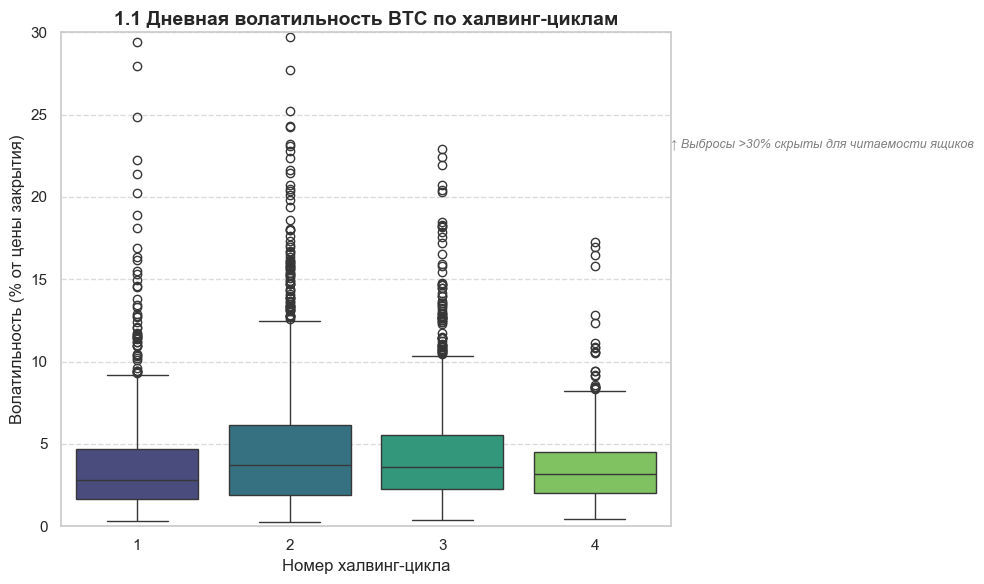

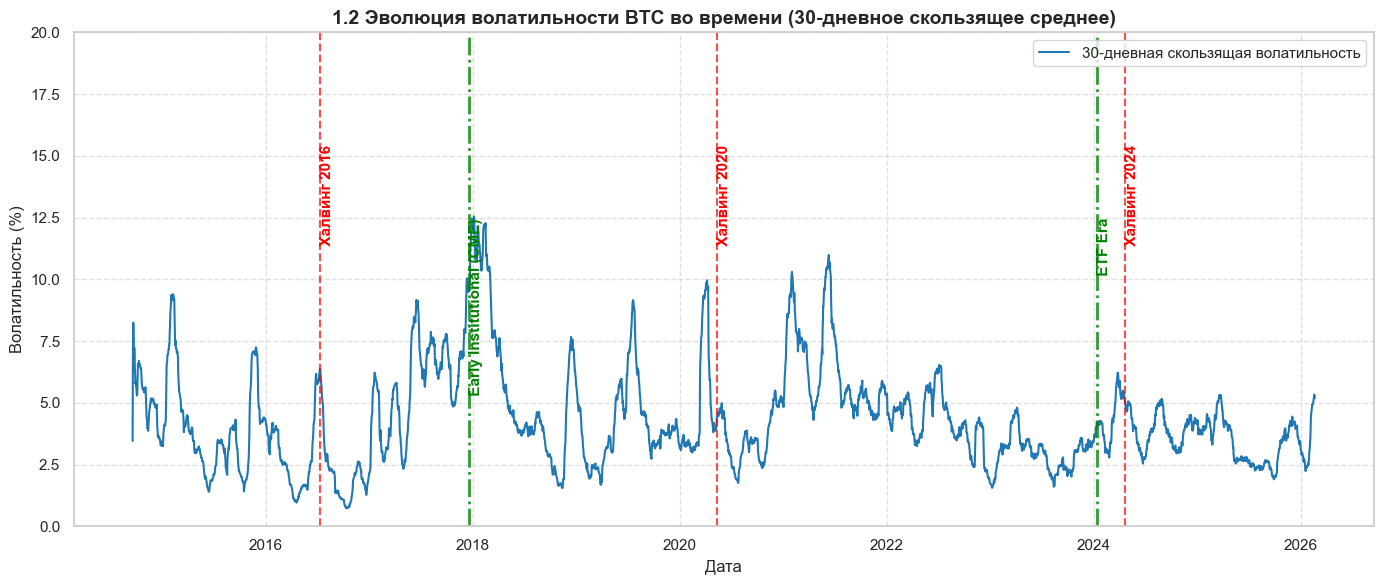

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------------------------------------------------
# 0. Настройка окружения и загрузка данных
# ---------------------------------------------------------
# Настройка поддержки кириллицы в графиках
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# Загрузка данных
file_path = "btc_comprehensive_analysis.csv"
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])

# Гарантированный расчет волатильности (если столбец вдруг отсутствует или сброшен)
df['Volatility_Pct'] = (df['High'] - df['Low']) / df['Close'] * 100

# ---------------------------------------------------------
# Словари с датами событий для аннотаций
# ---------------------------------------------------------
halving_dates = {
    'Халвинг 2016': '2016-07-09',
    'Халвинг 2020': '2020-05-11',
    'Халвинг 2024': '2024-04-19'
}

era_dates = {
    'Early Institutional (CME)': '2017-12-18',
    'ETF Era': '2024-01-11'
}

# Группировка и агрегация по халвинг-циклам
# Мы используем .agg() для одновременного расчета нескольких метрик
# Добавляем 'count', чтобы видеть размер выборки в каждом цикле
volatility_by_cycle = df.groupby('halving_cycle')['Volatility_Pct'].agg(
    count='count',       # Количество торговых дней в цикле
    median='median',     # Медиана (устойчива к выбросам)
    mean='mean',         # Среднее значение
    min='min',           # Минимальная волатильность
    max='max'            # Максимальная волатильность (пиковые значения)
).round(2)               # Округляем до 2 знаков для читаемости

# Вывод результата
print("Статистика дневной волатильности по халвинг-циклам:\n")
display(volatility_by_cycle)

# ---------------------------------------------------------
# График 1.1: Boxplot волатильности по халвинг-циклам
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Преобразуем цикл в строку, чтобы seaborn воспринимал его как категорию, а не как числовую ось
sns.boxplot(
    x=df['halving_cycle'].astype(str), 
    y=df['Volatility_Pct'], 
    hue=df['halving_cycle'].astype(str),  # Явно указываем переменную для цвета
    palette="viridis",
    legend=False,                         # Отключаем легенду, чтобы не дублировать ось X
    showfliers=True                       # Показываем выбросы
)

plt.title('1.1 Дневная волатильность BTC по халвинг-циклам', fontsize=14, fontweight='bold')
plt.xlabel('Номер халвинг-цикла', fontsize=12)
plt.ylabel('Волатильность (% от цены закрытия)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ограничим ось Y для лучшей читаемости (убираем экстремальные хвосты из вида, но не из данных)
# 99-й перцентиль волатильности обычно около 15-20%, установим лимит 25% для наглядности ящиков
plt.ylim(0, 30) 
plt.text(3.5, 23, '↑ Выбросы >30% скрыты для читаемости ящиков', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# График 1.2: Линейный график скользящей волатильности (30 дней)
# ---------------------------------------------------------
# Сортируем по дате для корректного расчета скользящего среднего
df_sorted = df.sort_values('Date').copy()

# Расчет 30-дневного скользящего среднего волатильности
df_sorted['Volatility_30d_MA'] = df_sorted['Volatility_Pct'].rolling(window=30, min_periods=1).mean()

plt.figure(figsize=(14, 6))

# Основной линейный график
plt.plot(df_sorted['Date'], df_sorted['Volatility_30d_MA'], color='#1f77b4', linewidth=1.5, label='30-дневная скользящая волатильность')

# 1. Добавление вертикальных линий халвингов
for label, date_str in halving_dates.items():
    plt.axvline(pd.to_datetime(date_str), color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    # Добавляем подпись к линии (с небольшим смещением по Y)
    plt.text(pd.to_datetime(date_str), plt.ylim()[1] * 0.85, f' {label}', 
             rotation=90, verticalalignment='bottom', fontsize=11, color='red', fontweight='bold')

# 2. Добавление вертикальных линий рыночных эр (зеленый штрихпунктир)
for label, date_str in era_dates.items():
    plt.axvline(pd.to_datetime(date_str), color='green', linestyle='-.', linewidth=2.0, alpha=0.8)
    # Размещаем текст чуть ниже текста халвингов, чтобы они не перекрывались
    plt.text(pd.to_datetime(date_str), plt.ylim()[1] * 0.95, f' {label}', 
             rotation=90, verticalalignment='top', fontsize=11, color='green', fontweight='bold')

plt.title('1.2 Эволюция волатильности BTC во времени (30-дневное скользящее среднее)', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Волатильность (%)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 20)

# Форматирование оси X для лучшего отображения дат
plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

#### Краткий вывод

1.1 Медианная волатильность и межквартильный размах (высота ящика) заметно снижаются от 2-го к 3-му циклу (два полных цикла в данных с 2016 по 2024 гг.). Ящики 1-го и 4-го цикла визуально уже, но над ними указано малое количество наблюдений (n значительно меньше, чем в полных циклах) в связи с тем, что эти циклы представлены в данных не полными.
1.2 Видны экстремальные пики волатильности (свыше 15–20%) в 2017 и 2020–2021 годах. После 2021 года общий уровень «шума» (скользящее среднее) стабилизировался в диапазоне 3–6%, с редкими локальными всплесками.

Снижение медианной волатильности от цикла к циклу указывает на структурное взросление рынка. По мере роста капитализации BTC и прихода институциональных игроков (сперва фьючерсы CME, затем ETF) рынку требуется значительно больший объем капитала для создания ценовых движений той же амплитуды, что и в эпоху доминирования розничных трейдеров.

Риск интерпретации: Узкий ящик 4-го цикла на boxplot обусловлен не только стабильностью, но и малой длиной выборки (данные есть только с апреля 2024 года). Делать выводы о стабильности 4-го цикла преждевременно.

Гипотеза для проверки: Всплески на линейном графике вблизи дат халвингов не доказывают, что причиной волатильности был именно халвинг. Эти пики могут совпадать с внешними макроэкономическими шоками (например, крах LUNA/FTX в 2022 году или пандемия в марте 2020 года). Чтобы отделить влияние халвинга, требуется сравнить волатильность в окнах ±30 дней вокруг даты халвинга с контрольными окнами в те же месяцы предыдущих лет.

### Гипотеза 2. Соотношение объёмов спота и фьючерсов CME по рыночным эрам

**Формулировка гипотезы:** Доля фьючерсного рынка CME в общем обороте BTC систематически растёт от эры `Pre_Institutional` к `ETF_Era`, что свидетельствует о структурном сдвиге в сторону институциональной торговли.

**Нужные столбцы:**
- `Volume_mln` (спотовый объём)
- `F_Volume_USD_Mln` (фьючерсный объём)
- `market_era` (группировка)
- `Date` (временная ось)

**Тип анализа:** Группировка + сравнение долей + динамика

**Расчётная формула:**
```python
df['Futures_Share_Pct'] = df['F_Volume_USD_Mln'] / (df['Volume_mln'] + df['F_Volume_USD_Mln']) * 100
```
**Визуализация:**
- 2.1 Столбчатая диаграмма средней доли фьючерсов по трём эрам
- 2.2 Линейный график скользящего среднего доли фьючерсов (90-дневное окно) с вертикальными линиями границ эр

**Ожидаемый результат:** Количественная оценка доли фьючерсов в каждой эре. Визуализация тренда роста институциональной активности.

#### График 2.1 Столбчатая диаграмма средней доли фьючерсов по `market_era`
- **Вопрос:** Какова усреднённая доля фьючерсного рынка в каждой из трёх рыночных эр?
- **Столбцы:** `Futures_Share_Pct` (значение), `market_era` (группировка).
- **Тип графика:** Bar chart (столбчатая диаграмма).
- **Почему уместен:** Идеален для сравнения агрегированных метрик между дискретными категориями (эрами).
- **Риск интерпретации:** В эре `Pre_Institutional` фьючерсов не было (NaN). График должен строиться только по эрам `Early_Institutional` и `ETF_Era`, иначе возникнет фактическая ошибка. Также среднее значение может быть искажено экстремальными днями (нужно смотреть на медиану).

#### График 2.2 Линейный график скользящей доли фьючерсов (90 дней) во времени
- **Вопрос:** Как менялась доля фьючерсов в общем обороте день за днём, и виден ли структурный сдвиг?
- **Столбцы:** `Date` (ось X), `Futures_Share_Pct` (ось Y, скользящее среднее), `market_era` (вертикальные линии-разделители).
- **Тип графика:** Line chart с аннотациями.
- **Почему уместен:** Показывает тренд и момент перелома (когда фьючерсы начали доминировать над спотом).
- **Риск интерпретации:** В выходные дни CME не торгуется, доля фьючерсов падает до 0. Скользящее среднее должно учитывать этот факт, иначе график будет иметь «пилообразный» шум.

Статистика доли фьючерсов CME в общем обороте по рыночным эрам:



,count,mean,median,min,max
market_era,,,,,
Early_Institutional,1526,2.94,2.42,0.00,13.45
ETF_Era,531,8.20,7.88,0.00,16.60


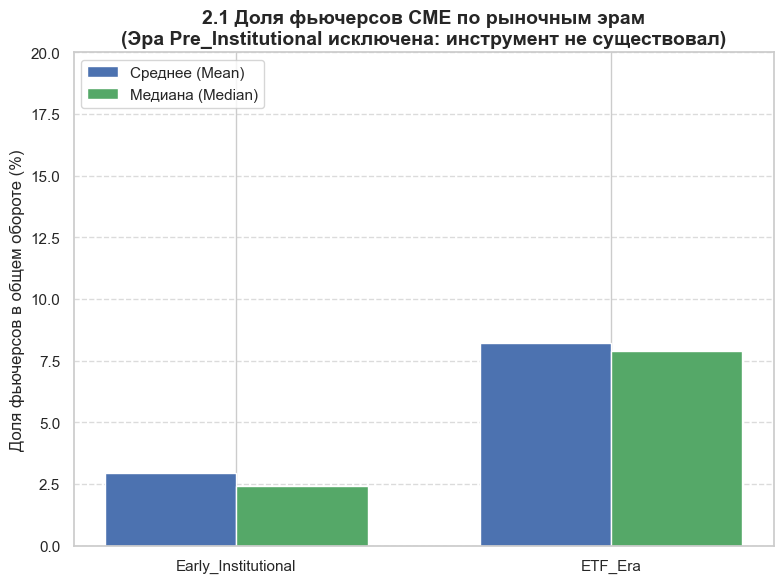

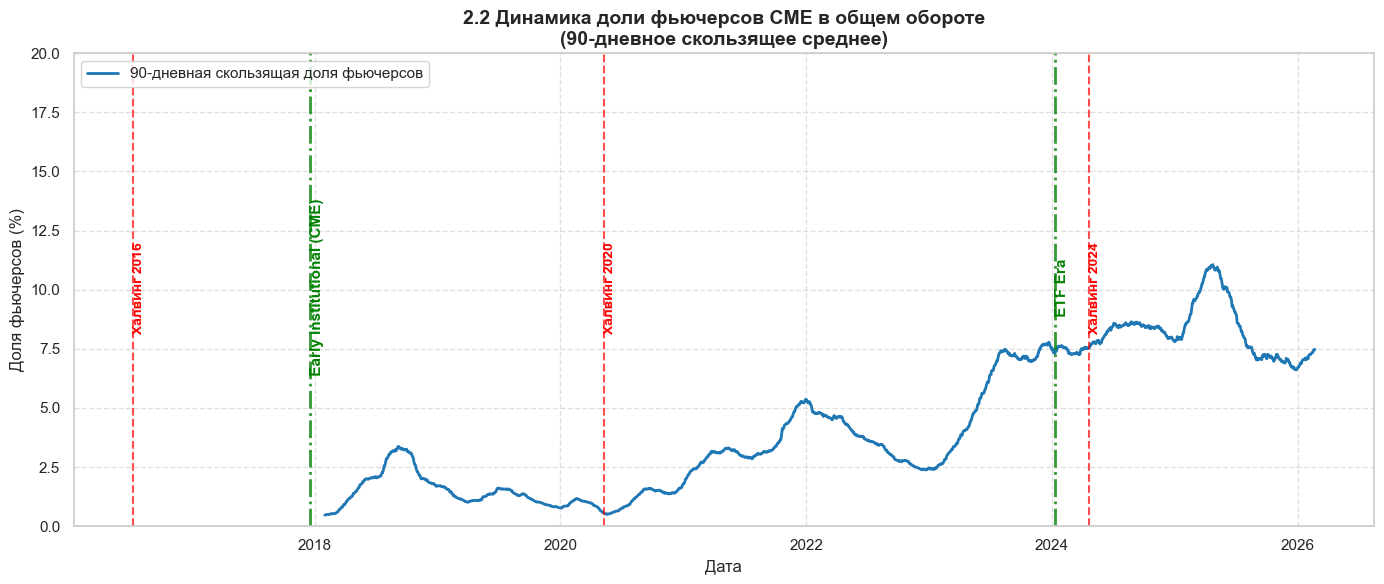

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# ---------------------------------------------------------
# 0. Настройка окружения и загрузка данных
# ---------------------------------------------------------
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

file_path = "btc_comprehensive_analysis.csv"
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])

# ---------------------------------------------------------
# 1. Создание расчетного признака
# ---------------------------------------------------------
total_volume = df['Volume_mln'] + df['F_Volume_USD_Mln']
df['Futures_Share_Pct'] = np.where(
    total_volume > 0,
    (df['F_Volume_USD_Mln'] / total_volume) * 100,
    np.nan
)

# ---------------------------------------------------------
# Словари с датами событий для аннотаций
# ---------------------------------------------------------
halving_dates = {
    'Халвинг 2016': '2016-07-09',
    'Халвинг 2020': '2020-05-11',
    'Халвинг 2024': '2024-04-19'
}

era_dates = {
    'Early Institutional (CME)': '2017-12-18',
    'ETF Era': '2024-01-11'
}

# 3. Фильтрация данных
# Исключаем Pre_Institutional, так как там 100% NaN (инструмента не существовало)
df_eras_valid = df[df['market_era'] != 'Pre_Institutional'].copy()

# 4. Группировка и агрегация по рыночным эрам
# Метод .count() в pandas автоматически игнорирует NaN, показывая реальное кол-во торговых дней с данными
era_stats = df_eras_valid.groupby('market_era').agg(
    count=('Futures_Share_Pct', 'count'),       # Количество дней с данными о фьючерсах
    mean=('Futures_Share_Pct', 'mean'),         # Среднее значение
    median=('Futures_Share_Pct', 'median'),     # Медиана (устойчива к выбросам)
    min=('Futures_Share_Pct', 'min'),           # Минимальная доля
    max=('Futures_Share_Pct', 'max')            # Максимальная доля
).round(2)

# 5. Фиксация хронологического порядка эр для корректного отображения
era_order = ['Early_Institutional', 'ETF_Era']
era_stats = era_stats.reindex(era_order)

# 6. Вывод результата
print("Статистика доли фьючерсов CME в общем обороте по рыночным эрам:\n")
display(era_stats)

# ---------------------------------------------------------
# График 2.1: Столбчатая диаграмма доли фьючерсов по эрам
# ИСПРАВЛЕНИЕ: явный порядок категорий
# ---------------------------------------------------------
df_eras_for_bar = df[df['market_era'] != 'Pre_Institutional'].copy()

# Фиксируем порядок: сначала Early_Institutional, потом ETF_Era
era_order = ['Early_Institutional', 'ETF_Era']
df_eras_for_bar['market_era'] = pd.Categorical(
    df_eras_for_bar['market_era'], 
    categories=era_order, 
    ordered=True
)

# Агрегация с сохранением порядка
era_stats = (
    df_eras_for_bar
    .groupby('market_era', observed=True)['Futures_Share_Pct']
    .agg(['mean', 'median'])
    .reindex(era_order)  # гарантируем порядок строк
    .reset_index()
)

plt.figure(figsize=(8, 6))
x = np.arange(len(era_stats['market_era']))
width = 0.35

plt.bar(x - width/2, era_stats['mean'], width, label='Среднее (Mean)', color='#4C72B0')
plt.bar(x + width/2, era_stats['median'], width, label='Медиана (Median)', color='#55A868')

plt.xticks(x, era_stats['market_era'])
plt.ylabel('Доля фьючерсов в общем обороте (%)', fontsize=12)
plt.title(
    '2.1 Доля фьючерсов CME по рыночным эрам\n'
    '(Эра Pre_Institutional исключена: инструмент не существовал)',
    fontsize=14, fontweight='bold'
)
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 20)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# График 2.2: Линейный график скользящей доли фьючерсов (90 дней)
# ИСПРАВЛЕНИЕ: подписи вертикальных линий по центру оси Y
# ---------------------------------------------------------
df_sorted = df.sort_values('Date').copy()
df_sorted['Futures_Share_90d_MA'] = (
    df_sorted['Futures_Share_Pct']
    .rolling(window=90, min_periods=30)
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    df_sorted['Date'], df_sorted['Futures_Share_90d_MA'],
    color='#1f77b4', linewidth=2,
    label='90-дневная скользящая доля фьючерсов'
)

# Определяем центр оси Y для размещения подписей
y_center = 10  # середина диапазона [0, 100]

# 1. Вертикальные линии халвингов (красный пунктир)
for label, date_str in halving_dates.items():
    plt.axvline(
        pd.to_datetime(date_str), color='red',
        linestyle='--', linewidth=1.5, alpha=0.7
    )
    plt.text(
        pd.to_datetime(date_str), y_center, f' {label}',
        rotation=90, verticalalignment='center',
        fontsize=10, color='red', fontweight='bold'
    )

# 2. Вертикальные линии рыночных эр (зелёный штрихпунктир)
for label, date_str in era_dates.items():
    plt.axvline(
        pd.to_datetime(date_str), color='green',
        linestyle='-.', linewidth=2.0, alpha=0.8
    )
    plt.text(
        pd.to_datetime(date_str), y_center, f' {label}',
        rotation=90, verticalalignment='center',
        fontsize=11, color='green', fontweight='bold'
    )

plt.title(
    '2.2 Динамика доли фьючерсов CME в общем обороте\n(90-дневное скользящее среднее)',
    fontsize=14, fontweight='bold'
)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Доля фьючерсов (%)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 20)

plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

#### Краткий вывод

2.1 Медианная доля фьючерсов CME в общем обороте выросла с ~2.4% в эре Early_Institutional до ~7.9% в эре ETF_Era — рост более чем в 3 раза.
2.2 На линейном графике виден устойчивый восходящий тренд с 2020 года, с резким ускорением в 2023–2024 годах и пиком ~11% в середине 2025 года.
Разрыв между средним и медианным значениями в обеих эрах небольшой, что говорит об отсутствии сильного перекоса распределения экстремальными выбросами.

Фьючерсы CME перестали быть нишевым инструментом и стали структурно значимой частью рынка BTC. Ускорение роста доли совпадает с периодами высокой волатильности (2018, 2022, 2024), что указывает на активное использование деривативов для хеджирования в моменты стресса.

Ограничения:
1. Сравнение идет с глобальным спотовым объемом (Kaggle), который включает все биржи - регулируемые и нерегулируемые. Если бы мы сравнивали CME только с регулируемыми американскими площадками (Coinbase, например), доля была бы существенно выше.
2. "Провалы" на линейном графике до нуля в ранние годы — это выходные и праздники США, когда CME не торгуется. Скользящее среднее сглаживает этот эффект, но не устраняет полностью.

Гипотеза для проверки:
Рост доли фьючерсов может быть связан не только с институционализацией, но и с абсолютным ростом цены BTC. Стоит проверить корреляцию доли фьючерсов с уровнем цены Close.

### Гипотеза 3. Корреляция дневных притоков ETF с дневной доходностью BTC

**Формулировка гипотезы:** В эру ETF существует статистически значимая положительная корреляция между дневным чистым притоком в ETF и дневной доходностью спотовой цены BTC.

**Нужные столбцы:**
- `ETF_Total_Net_Flow_mln_usd` (дневной приток)
- `Close` (для расчёта доходности)
- `Date` (временная ось)

**Тип анализа:** Корреляция + scatter plot
  
**Расчётная формула:**
```python
df['Daily_Return_Pct'] = df['Close'].pct_change() * 100
```

**Визуализация:**
- 3.1 Scatter plot: `ETF_Total_Net_Flow_mln_usd` vs `Daily_Return_Pct` (только для эры ETF, без NaN)
- 3.2 Линейный график с двумя осями: приток ETF (столбцы) и цена BTC (линия)
  
**Ожидаемый результат:** Коэффициент корреляции Пирсона (или Спирмена). Визуальное подтверждение/опровержение связи.

#### График 3.1 Scatter plot: приток ETF vs дневная доходность
- **Вопрос:** Есть ли визуальная связь между объёмом дневного притока в ETF и направлением движения цены BTC?
- **Столбцы:** `ETF_Total_Net_Flow_mln_usd` (ось X), `Daily_Return_Pct` (ось Y).
- **Тип графика:** Scatter plot (точечная диаграмма) с линией регрессии.
- **Почему уместен:** Классический инструмент для оценки корреляции двух непрерывных переменных. Позволяет увидеть кластеризацию точек и наличие выбросов.
- **Риск интерпретации:** Корреляция не равна причинности. Приток в ETF может быть *реакцией* на уже произошедший рост цены, а не её причиной. Также возможна проблема лага (влияние проявляется на следующий день).

#### График 3.2 Комбинированный график: столбцы притока ETF + линия цены BTC
- **Вопрос:** Совпадают ли визуально дни массового притока/оттока с локальными экстремумами цены?
- **Столбцы:** `Date` (ось X), `ETF_Total_Net_Flow_mln_usd` (ось Y1, столбцы), `Close` (ось Y2, линия).
- **Тип графика:** Dual-axis chart (комбинированный столбчато-линейный).
- **Почему уместен:** Позволяет сопоставить абсолютные значения потоков с ценовыми уровнями на единой временной шкале.
- **Риск интерпретации:** Две оси Y могут визуально манипулировать восприятием (масштабирование одной из осей может создать иллюзию связи там, где её нет).

Размер выборки для расчета корреляции (ETF_Era, без пропусков): 545 дней

Коэффициенты корреляции (ETF_Era):
  Пирсон (Pearson) : 0.3589
  Спирмен (Spearman): 0.3424

Топ-3 дня с максимальным чистым притоком в ETF:


,Date,ETF_Total_Net_Flow_mln_usd,Daily_Return_Pct,Close
3704,2024-11-07,1373.80,0.35,75904.90
4037,2025-10-06,1205.20,1.00,124752.50
3949,2025-07-10,1175.60,4.19,115987.20


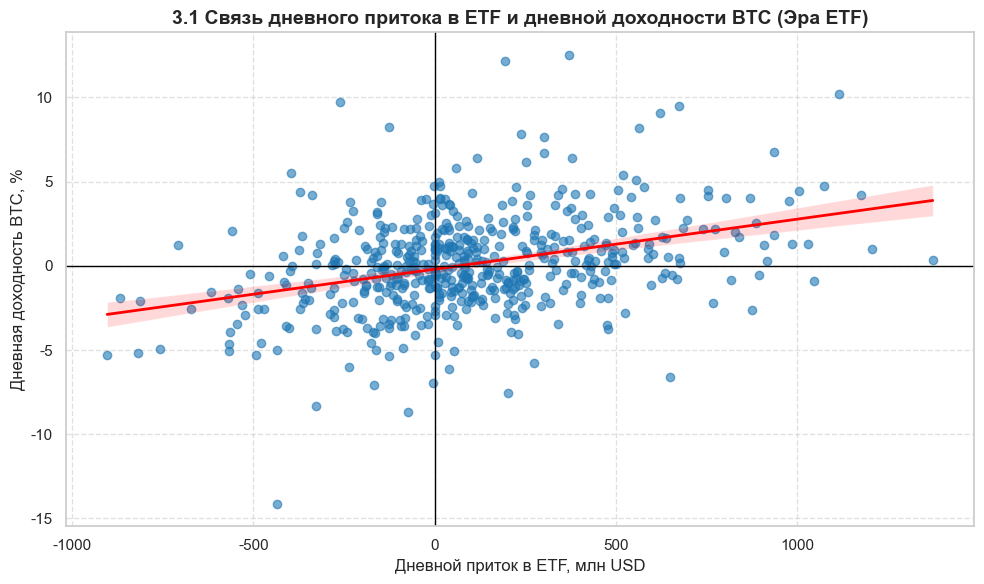

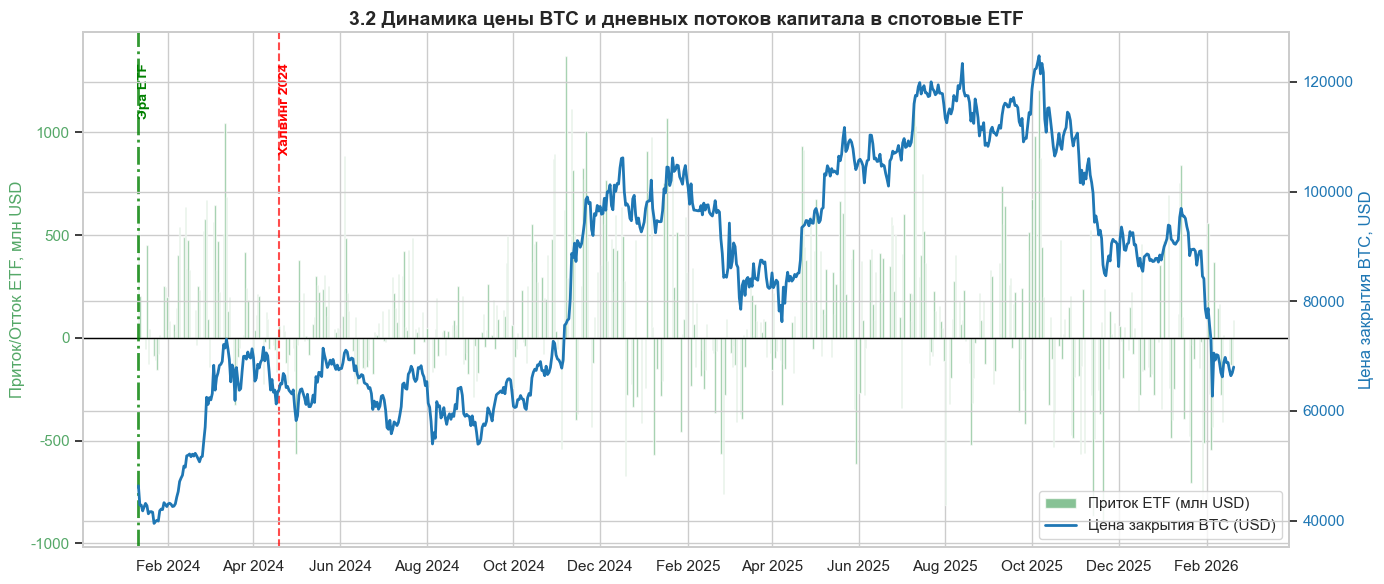

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

# ---------------------------------------------------------
# 0. Настройка окружения и загрузка данных
# ---------------------------------------------------------
# Настройка поддержки кириллицы
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# Загрузка данных
file_path = "btc_comprehensive_analysis.csv"
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])

# Гарантированный расчет дневной доходности (%)
df['Daily_Return_Pct'] = df['Close'].pct_change() * 100

# Фильтрация только для эры ETF
df_etf = df[df['market_era'] == 'ETF_Era'].copy()

# ИСПРАВЛЕНИЕ: Явно создаем датафрейм для корреляционного анализа, удаляя пропуски (NaN)
df_corr = df_etf[['ETF_Total_Net_Flow_mln_usd', 'Daily_Return_Pct']].dropna()

# Оставляем df_scatter для совместимости с кодом построения графика (regplot) ниже
df_scatter = df_corr

# Словари с датами событий (для временных графиков)
halving_dates = {
    'Халвинг 2024': '2024-04-19' # 2016 и 2020 не отобразятся, так как они вне эры ETF
}
era_dates = {
    'Эра ETF': '2024-01-11'
}

# Проверяем размер выборки, чтобы оценка была статистически осмысленной
sample_size = len(df_corr)
print(f"Размер выборки для расчета корреляции (ETF_Era, без пропусков): {sample_size} дней\n")

# 5. Расчет коэффициентов корреляции
# Метод Пирсона (линейная связь)
corr_pearson = df_corr['ETF_Total_Net_Flow_mln_usd'].corr(df_corr['Daily_Return_Pct'], method='pearson')

# Метод Спирмена (ранговая/монотонная связь, устойчива к выбросам)
corr_spearman = df_corr['ETF_Total_Net_Flow_mln_usd'].corr(df_corr['Daily_Return_Pct'], method='spearman')

# 6. Вывод результатов
print("Коэффициенты корреляции (ETF_Era):")
print(f"  Пирсон (Pearson) : {corr_pearson:.4f}")
print(f"  Спирмен (Spearman): {corr_spearman:.4f}")

# Дополнительная проверка: посмотрим на дни с самыми экстремальными притоками, 
# чтобы понять, не искажают ли они общую картину
print("\nТоп-3 дня с максимальным чистым притоком в ETF:")
display(df_etf.nlargest(3, 'ETF_Total_Net_Flow_mln_usd')[['Date', 'ETF_Total_Net_Flow_mln_usd', 'Daily_Return_Pct', 'Close']].round(2))

# ---------------------------------------------------------
# График 3.1: Scatter plot с линией регрессии
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Используем seaborn regplot для автоматического построения линии линейной регрессии и доверительного интервала
sns.regplot(
    x='ETF_Total_Net_Flow_mln_usd', 
    y='Daily_Return_Pct', 
    data=df_scatter, 
    scatter_kws={'alpha': 0.6, 'color': '#1f77b4'}, # Прозрачность точек для оценки плотности
    line_kws={'color': 'red', 'linewidth': 2}       # Цвет линии тренда
)

plt.title('3.1 Связь дневного притока в ETF и дневной доходности BTC (Эра ETF)', fontsize=14, fontweight='bold')
plt.xlabel('Дневной приток в ETF, млн USD', fontsize=12)
plt.ylabel('Дневная доходность BTC, %', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Добавим вертикальную и горизонтальную линии на уровне 0 для удобства чтения знаков
plt.axhline(0, color='black', linewidth=1, linestyle='-')
plt.axvline(0, color='black', linewidth=1, linestyle='-')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# График 3.2: Комбинированный график (Dual-axis chart)
# ---------------------------------------------------------
# Сортируем по дате для корректного отображения временного ряда
df_etf_sorted = df_etf.sort_values('Date').copy()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Ось 1 (левая): Столбцы притока ETF
color1 = '#55A868'
ax1.bar(df_etf_sorted['Date'], df_etf_sorted['ETF_Total_Net_Flow_mln_usd'], 
        color=color1, alpha=0.7, width=1.0, label='Приток ETF (млн USD)')
ax1.set_ylabel('Приток/Отток ETF, млн USD', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axhline(0, color='black', linewidth=1) # Нулевая линия для столбцов

# Ось 2 (правая): Линия цены закрытия
ax2 = ax1.twinx()
color2 = '#1f77b4'
ax2.plot(df_etf_sorted['Date'], df_etf_sorted['Close'], 
         color=color2, linewidth=2, label='Цена закрытия BTC (USD)')
ax2.set_ylabel('Цена закрытия BTC, USD', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

# Добавление вертикальных линий событий (только тех, что есть в диапазоне данных)
min_date = df_etf_sorted['Date'].min()

for label, date_str in era_dates.items():
    if pd.to_datetime(date_str) >= min_date:
        ax1.axvline(pd.to_datetime(date_str), color='green', linestyle='-.', linewidth=2.0, alpha=0.8)
        ax1.text(pd.to_datetime(date_str), ax1.get_ylim()[1] * 0.9, f' {label}', 
                 rotation=90, verticalalignment='top', fontsize=10, color='green', fontweight='bold')

for label, date_str in halving_dates.items():
    if pd.to_datetime(date_str) >= min_date:
        ax1.axvline(pd.to_datetime(date_str), color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        ax1.text(pd.to_datetime(date_str), ax1.get_ylim()[1] * 0.9, f' {label}', 
                 rotation=90, verticalalignment='top', fontsize=10, color='red', fontweight='bold')

plt.title('3.2 Динамика цены BTC и дневных потоков капитала в спотовые ETF', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)

# Форматирование оси X
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Объединение легенд с двух осей
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

fig.tight_layout()
plt.show()

#### Краткий вывод

3.1 Линия регрессии имеет небольшой положительный наклон, что указывает на слабую положительную связь между дневным притоком в ETF и дневной доходностью BTC. Большинство наблюдений (~80%) сконцентрировано в диапазоне притоков от -500 до +500 млн USD и доходности от -5% до +5%. Присутствуют выраженные выбросы: дни с притоком >1000 млн USD сопровождаются доходностью +8%...+10%, а дни с оттоком ~-500 млн USD — доходностью -14%. Доверительный интервал (розовая зона) широкий, особенно в хвостах распределения, что говорит о высокой статистической неопределенности связи.

Существует слабая, но статистически заметная положительная связь: в дни с чистым притоком капитала в спотовые ETF цена закрытия BTC с большей вероятностью растет, и наоборот. Однако разброс точек вокруг линии регрессии очень велик, что означает: приток в ETF объясняет лишь малую долю дневной изменчивости цены. Остальная вариативность обусловлена другими факторами (макроэкономика, глобальная ликвидность, действия крупных держателей вне ETF).

Ограничения:
- Корреляция не доказывает причинность. Приток в ETF может быть *реакцией* на уже произошедший рост цены, а не его драйвером.
- Возможна проблема временного лага: влияние крупного притока сегодня может проявиться на цене завтра или в течение нескольких дней, но этот график измеряет только единовременную связь (same-day).

3.2 В фазе роста цены преобладают дни с положительным притоком в ETF (зеленые столбцы выше нуля), с регулярными пиками >500 млн USD. В периоды коррекций визуально учащаются дни с отрицательным притоком (отток капитала), включая экстремальные оттоки ~-800 млн USD. Пики цены часто предшествуют или совпадают с кластерами дней высоких притоков. Резкие падения цены сопровождаются всплесками оттока капитала из ETF.

Институциональный капитал через спотовые ETF действует как "усилитель тренда": в бычьих фазах притоки поддерживают и ускоряют рост, в медвежьих — оттоки усугубляют давление на цену. Визуальное совпадение пиков цены с кластерами высоких притоков говорит о том, что институционалы активно участвуют в рыночных движениях, но не являются их единственным источником.

Ограничения:
- Две оси Y с разным масштабом могут создавать визуальную иллюзию более тесной связи, чем есть на самом деле. Масштабирование левой оси (приток) и правой оси (цена) субъективно и может манипулировать восприятием.
- График не отвечает на вопрос "что было первым": рост цены привлек приток, или приток толкнул цену вверх.

Гипотеза для проверки:
Для проверки причинно-следственной связи необходимо рассчитать кросс-корреляцию с лагом: влияет ли приток в ETF в день `T` на доходность BTC в день `T+1` или `T+2`. Если лаговая корреляция окажется выше same-day, это будет аргументом в пользу того, что приток *предшествует* движению цены (а не следует за ним).

### Гипотеза 4. Кумулятивный приток ETF vs цена BTC в эру ETF

**Формулировка гипотезы:** Накопительный приток капитала в спотовые BTC ETF демонстрирует устойчивую положительную связь с уровнем цены BTC в эре ETF.
**Нужные столбцы:**
- `ETF_Cumulative_Flow_mln_usd` (накопительный приток)
- `Close` (цена BTC)
- `Date` (временная ось)

**Тип анализа:** Динамика + корреляция + сравнение трендов

**Визуализация:**
- 4.1 Двойной линейный график (две оси Y): кумулятивный приток ETF (левая ось) и цена BTC (правая ось)
- 4.2 Scatter plot с линией регрессии: `ETF_Cumulative_Flow_mln_usd` vs `Close`

**Ожидаемый результат:** Визуальное совпадение трендов. Коэффициент корреляции. Возможность оценить, насколько рост кумулятивного притока сопровождается ростом цены.

#### График 4.1 Двойной линейный график: кумулятивный приток и цена
- **Вопрос:** Насколько синхронно движутся накопительный приток капитала и цена BTC в эру ETF?
- **Столбцы:** `Date` (ось X), `ETF_Cumulative_Flow_mln_usd` (левая ось Y), `Close` (правая ось Y).
- **Тип графика:** Dual-axis line chart.
- **Почему уместен:** Оба показателя имеют выраженный восходящий тренд. График покажет, насколько плотно они следуют друг за другом.
- **Риск интерпретации:** **Ложная корреляция из-за общего тренда.** Два растущих показателя могут иметь высокий коэффициент корреляции (Пирсона), даже если между ними нет причинно-следственной связи. Это классическая ошибка анализа нестационарных временных рядов.

#### График 4.2 Scatter plot с линией регрессии: кумулятивный приток vs цена
- **Вопрос:** Какова форма и сила связи между накопленным объёмом денег в ETF и текущей ценой BTC?
- **Столбцы:** `ETF_Cumulative_Flow_mln_usd` (ось X), `Close` (ось Y).
- **Тип графика:** Scatter plot с линией тренда.
- **Почему уместен:** Позволяет оценить, является ли связь линейной или нелинейной, и увидеть, насколько цена отклоняется от «справедливого» значения, предсказанного притоком.
- **Риск интерпретации:** Кумулятивный приток — это монотонно растущая величина (если нет оттоков). Это автоматически создаёт сильную математическую связь с любым растущим активом, что делает интерпретацию крайне уязвимой.


Размер выборки для расчета корреляции (ETF_Era, без пропусков): 545 дней

Коэффициенты корреляции между кумулятивным притоком ETF и ценой BTC (ETF_Era):
  Пирсон (Pearson) : 0.8516
  Спирмен (Spearman): 0.7981

Последние 3 доступных наблюдения в выборке:


,ETF_Cumulative_Flow_mln_usd,Close
4172,55186.80,66425.30
4173,55021.00,66957.50
4174,55109.10,68005.40


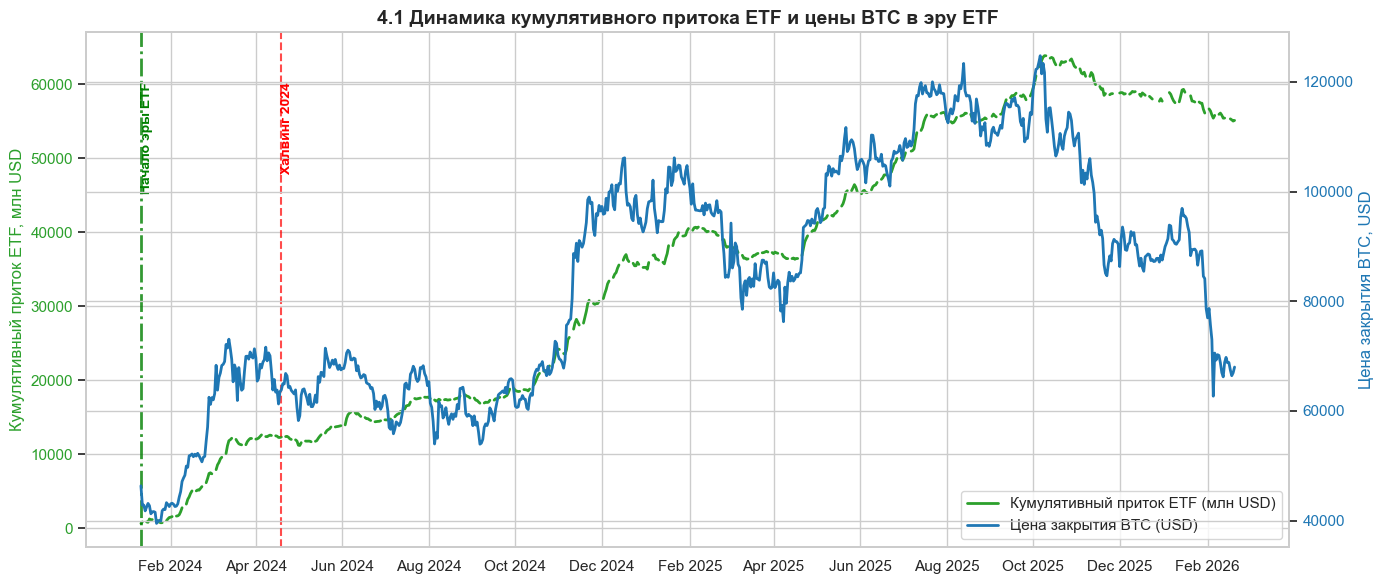

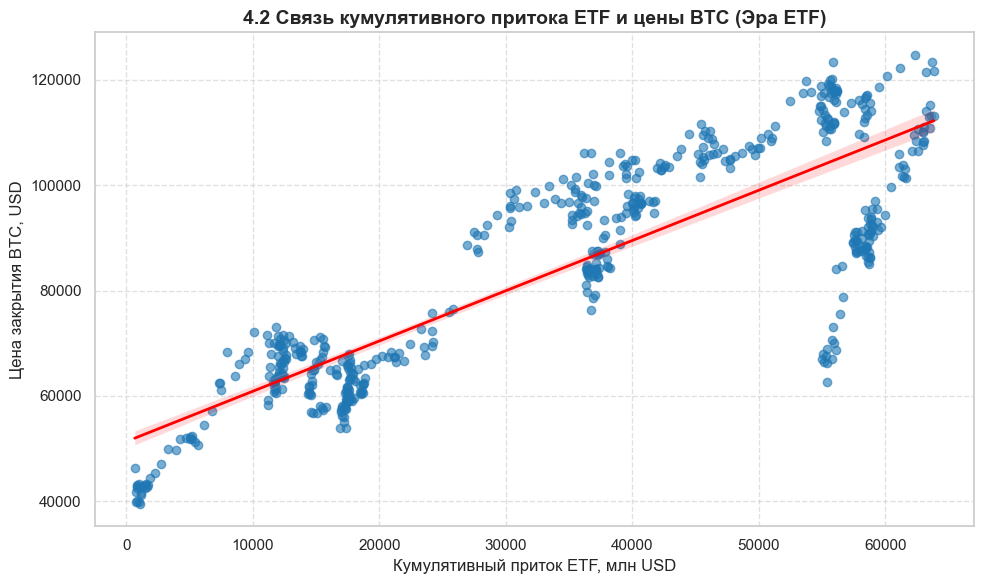

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

# ---------------------------------------------------------
# 0. Настройка окружения и загрузка данных
# ---------------------------------------------------------
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

file_path = "btc_comprehensive_analysis.csv"
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])

# Фильтрация только для эры ETF
df_etf = df[df['market_era'] == 'ETF_Era'].copy()
df_etf = df_etf.sort_values('Date')

# Словарь с датами событий для аннотаций
# В эре ETF актуален только халвинг 2024 года
halving_dates = {
    'Халвинг 2024': '2024-04-19'
}

era_dates = {
    'Начало эры ETF': '2024-01-11'
}

# 3. Подготовка к расчету корреляции
# Выбираем только нужные столбцы и удаляем строки с NaN
# (В начале эры ETF кумулятивный поток мог быть NaN или 0, а первая строка Close может иметь артефакты)
df_corr = df_etf[['ETF_Cumulative_Flow_mln_usd', 'Close']].dropna()

# Проверяем размер выборки
sample_size = len(df_corr)
print(f"Размер выборки для расчета корреляции (ETF_Era, без пропусков): {sample_size} дней\n")

# 4. Расчет коэффициентов корреляции
# Метод Пирсона (оценивает линейную связь)
corr_pearson = df_corr['ETF_Cumulative_Flow_mln_usd'].corr(df_corr['Close'], method='pearson')

# Метод Спирмена (оценивает монотонную связь, более устойчив к выбросам)
corr_spearman = df_corr['ETF_Cumulative_Flow_mln_usd'].corr(df_corr['Close'], method='spearman')

# 5. Вывод результатов
print("Коэффициенты корреляции между кумулятивным притоком ETF и ценой BTC (ETF_Era):")
print(f"  Пирсон (Pearson) : {corr_pearson:.4f}")
print(f"  Спирмен (Spearman): {corr_spearman:.4f}")

# Дополнительная проверка: посмотрим на последние значения, чтобы понять масштаб
print("\nПоследние 3 доступных наблюдения в выборке:")
display(df_corr.tail(3).round(2))

# ---------------------------------------------------------
# График 4.1: Двойной линейный график (Dual-axis line chart)
# ---------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(14, 6))

# Ось 1 (левая): Кумулятивный приток ETF
color1 = '#2ca02c'
ax1.plot(df_etf['Date'], df_etf['ETF_Cumulative_Flow_mln_usd'], 
         color=color1, linewidth=2, label='Кумулятивный приток ETF (млн USD)')
ax1.set_ylabel('Кумулятивный приток ETF, млн USD', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)

# Ось 2 (правая): Цена BTC
ax2 = ax1.twinx()
color2 = '#1f77b4'
ax2.plot(df_etf['Date'], df_etf['Close'], 
         color=color2, linewidth=2, label='Цена закрытия BTC (USD)')
ax2.set_ylabel('Цена закрытия BTC, USD', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

# Добавление вертикальных линий событий
min_date = df_etf['Date'].min()

for label, date_str in era_dates.items():
    if pd.to_datetime(date_str) >= min_date:
        ax1.axvline(pd.to_datetime(date_str), color='green', linestyle='-.', linewidth=2.0, alpha=0.8)
        ax1.text(pd.to_datetime(date_str), ax1.get_ylim()[1] * 0.9, f' {label}', 
                 rotation=90, verticalalignment='top', fontsize=10, color='green', fontweight='bold')

for label, date_str in halving_dates.items():
    if pd.to_datetime(date_str) >= min_date:
        ax1.axvline(pd.to_datetime(date_str), color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        ax1.text(pd.to_datetime(date_str), ax1.get_ylim()[1] * 0.9, f' {label}', 
                 rotation=90, verticalalignment='top', fontsize=10, color='red', fontweight='bold')

plt.title('4.1 Динамика кумулятивного притока ETF и цены BTC в эру ETF', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)

# Форматирование оси X
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Объединение легенд с двух осей
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

fig.tight_layout()
plt.show()

# ---------------------------------------------------------
# График 4.2: Scatter plot с линией регрессии
# ---------------------------------------------------------
# Удаляем строки с NaN по целевым столбцам
df_scatter = df_etf[['ETF_Cumulative_Flow_mln_usd', 'Close']].dropna()

plt.figure(figsize=(10, 6))

# Используем seaborn regplot для автоматического построения линии регрессии
sns.regplot(
    x='ETF_Cumulative_Flow_mln_usd', 
    y='Close', 
    data=df_scatter, 
    scatter_kws={'alpha': 0.6, 'color': '#1f77b4'},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('4.2 Связь кумулятивного притока ETF и цены BTC (Эра ETF)', fontsize=14, fontweight='bold')
plt.xlabel('Кумулятивный приток ETF, млн USD', fontsize=12)
plt.ylabel('Цена закрытия BTC, USD', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### Краткий вывод

На графике 4.1 оба показателя демонстрируют выраженный восходящий тренд с января 2024 года. Визуально кривые движутся синхронно: периоды ускорения притока совпадают с периодами роста цены. В период с октября 2025 по февраль 2026 наблюдается расхождение трендов.
На графике 4.2 точки образуют четкую положительную линейную связь с узким доверительным интервалом, линия регрессии имеет положительный наклон, точки в среднем следуют тренду. Коэффициент корреляции Пирсона между кумулятивным притоком и ценой составляет ~0.85 (очень высокая корреляция). Однако разброс точек значителен. В правой части графика наблюдается резкое падение цены, что создает кластер точек значительно ниже линии тренда. Это соответствует периоду расхождения на первом графике (начало 2026).
Кумулятивный приток ETF и цена BTC демонстрируют общую положительную корреляцию в эре ETF, но связь нестабильна и нарушается в периоды высокой волатильности.

Визуальное и статистическое совпадение трендов подтверждает, что в эру ETF накопительный приток капитала и цена BTC движутся в одном направлении. Это согласуется с гипотезой о том, что институциональный капитал через спотовые ETF стал значимым фактором ценообразования. Однако это также может говорить о ложной корреляции из-за общего тренда: оба показателя росли одновременно, но их динамика определяется разными факторами. Scatter plot (4.2) подтверждает, что связь между кумулятивным притоком и ценой нелинейная и нестабильная. Это означает, что кумулятивный приток объясняет лишь часть вариативности цены, остальная часть определяется другими факторами (макроэкономика, ликвидность, спекулятивная активность).

Ограничение:
Кумулятивный показатель по своей природе не может падать (если нет массовых оттоков), поэтому он автоматически создает положительную корреляцию с любым активом, который в среднем растет. Это делает метрику аналитически уязвимой.
Гипотеза для проверки причинности: необходим анализ лагов (влияет ли приток сегодня на цену завтра) или тест Грейнджера.


### Гипотеза 5. Фьючерсный спред (премия/дисконт) по рыночным эрам и халвинг-циклам

**Формулировка гипотезы:** Фьючерсы CME в разные рыночные эры и халвинг-циклы демонстрируют систематическую премию или дисконт к спотовой цене, причём знак и величина спреда меняются в зависимости от рыночных условий.

**Нужные столбцы:**
- `F_Close` (цена фьючерса)
- `Close` (спотовая цена)
- `market_era` (группировка)
- `halving_cycle` (группировка)
- `Date` (временная ось)
- 
**Тип анализа:** Группировка + сравнение + динамика
  
**Расчётная формула:**
```python
df['Futures_Spread_Pct'] = (df['F_Close'] - df['Close']) / df['Close'] * 100
```

**Визуализация:**
- 5.1 Boxplot спреда по `market_era` (3 категории)
- 5.2 Boxplot спреда по `halving_cycle` (4 категории)
- 5.3 Линейный график спреда во времени с вертикальными линиями границ эр
  
**Ожидаемый результат:** Таблица с медианным и средним спредом по эрам и циклам. Визуализация того, когда фьючерсы торгуются с премией, а когда с дисконтом.

 #### График 5.1 Boxplot спреда по `market_era`
- **Вопрос:** В каких эрах фьючерсы в среднем торгуются с премией, а в каких — с дисконтом к споту?
- **Столбцы:** `Futures_Spread_Pct` (значение), `market_era` (группировка).
- **Тип графика:** Boxplot.
- **Почему уместен:** Показывает не только среднее, но и то, как часто спред уходит в отрицательную зону (дисконт), что критически важно для понимания рыночных настроений.
- **Риск интерпретации:** В эре `Pre_Institutional` данных нет. Сравнение возможно только между `Early_Institutional` и `ETF_Era`.

#### График 5.2 Boxplot спреда по `halving_cycle`
- **Вопрос:** Меняется ли структура спреда (премия/дисконт) в зависимости от фазы халвинг-цикла?
- **Столбцы:** `Futures_Spread_Pct` (значение), `halving_cycle` (группировка).
- **Тип графика:** Boxplot.
- **Почему уместен:** Позволяет выявить, например, что перед халвингом премия растёт, а после — схлопывается.
- **Риск интерпретации:** Спред может быть обусловлен не халвингом, а стоимостью привлечения капитала (cost of carry) и ставками ФРС.

#### График 5.3 Линейный график спреда во времени
- **Вопрос:** Как ведут себя премии и дисконты в моменты кризисов и резких движений цены?
- **Столбцы:** `Date` (ось X), `Futures_Spread_Pct` (ось Y), нулевая линия (горизонтальная аннотация).
- **Тип графика:** Line chart с выделением нулевой линии.
- **Почему уместен:** Показывает динамику и частоту переходов через ноль (смену настроения рынка).
- **Риск интерпретации:** Глубокий дисконт (отрицательный спред) часто возникает в моменты паники и ликвидаций длинных позиций. Это важный сигнал, но он не предсказывает будущее направление цены.
 

Статистика фьючерсного спреда (премия/дисконт) по рыночным эрам и халвинг-циклам:



count  median  mean    min   max
market_era          halving_cycle                                  
ETF_Era             3                 68    0.31  0.31  -2.83  4.33
                    4                463    0.25  0.24  -3.27  5.93
Early_Institutional 2                601   -0.52 -0.54 -11.34 20.91
                    3                925    0.11  0.15  -7.61 10.77
Pre_Institutional   1                  0     NaN   NaN    NaN   NaN
                    2                  0     NaN   NaN    NaN   NaN

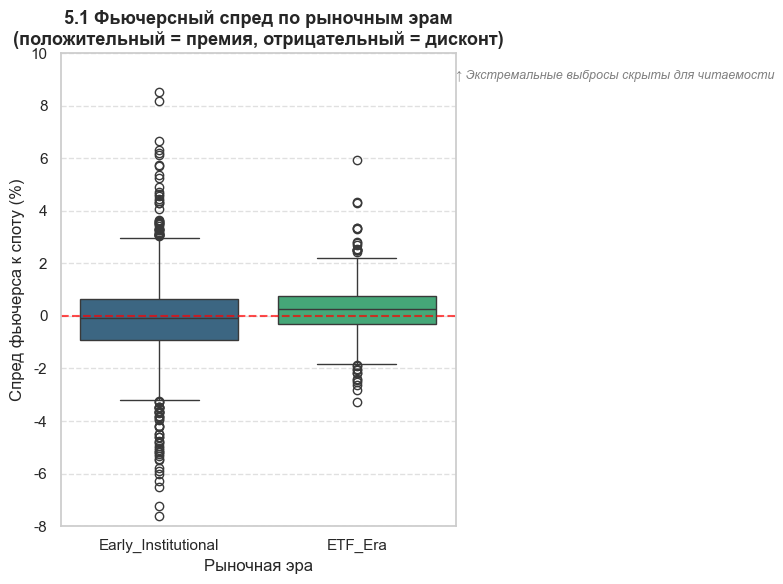

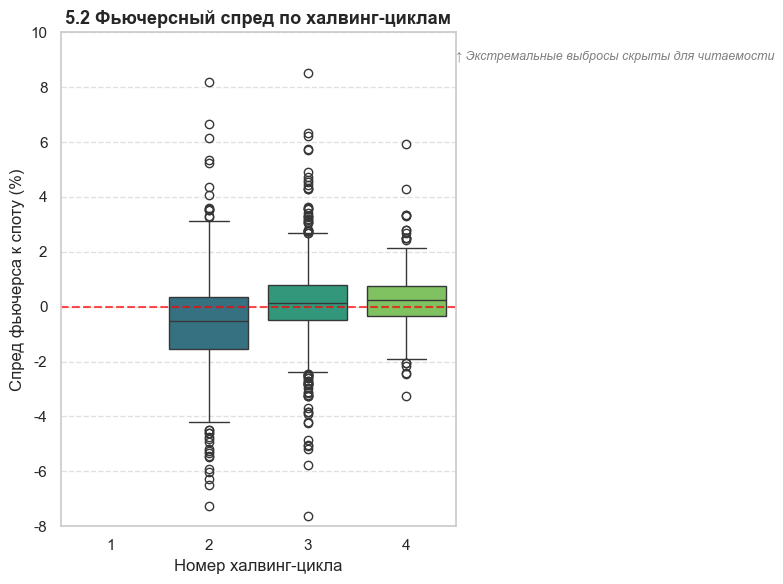

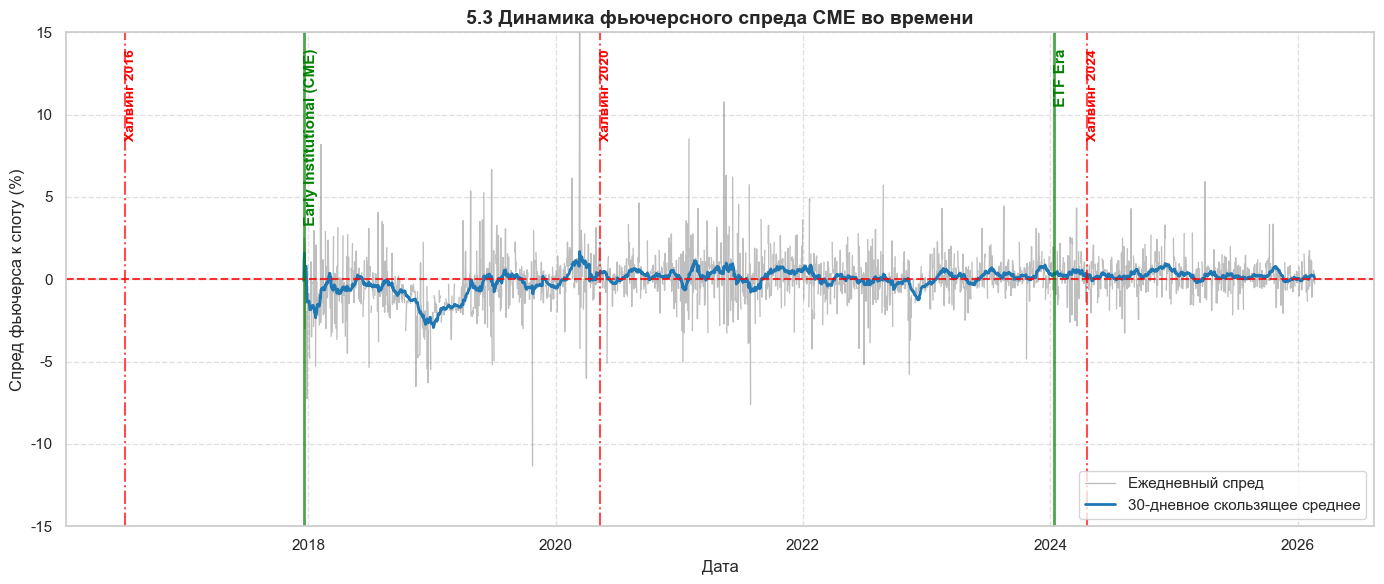

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

# ---------------------------------------------------------
# 0. Настройка окружения и загрузка данных
# ---------------------------------------------------------
# Настройка поддержки кириллицы
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

file_path = "btc_comprehensive_analysis.csv"
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])

# Гарантированный расчет фьючерсного спреда (%)
# (Цена фьючерса - Спотовая цена) / Спотовая цена * 100
df['Futures_Spread_Pct'] = (df['F_Close'] - df['Close']) / df['Close'] * 100

# Словари с датами событий для аннотаций
halving_dates = {
    'Халвинг 2016': '2016-07-09',
    'Халвинг 2020': '2020-05-11',
    'Халвинг 2024': '2024-04-19'
}

era_dates = {
    'Early Institutional (CME)': '2017-12-18',
    'ETF Era': '2024-01-11'
}

# 3. Группировка и агрегация по рыночным эрам и халвинг-циклам
# Добавляем 'count', чтобы видеть размер выборки, и min/max для оценки экстремумов
spread_by_era_cycle = df.groupby(['market_era', 'halving_cycle'])['Futures_Spread_Pct'].agg(
    count='count',       # Количество дней с данными (NaN игнорируются)
    median='median',     # Медиана (устойчива к экстремальным всплескам)
    mean='mean',         # Среднее значение
    min='min',           # Минимальный спред (максимальный дисконт)
    max='max'            # Максимальный спред (максимальная премия)
).round(2)

# 4. Вывод результата
print("Статистика фьючерсного спреда (премия/дисконт) по рыночным эрам и халвинг-циклам:\n")
display(spread_by_era_cycle)

# ---------------------------------------------------------
# График 5.1: Boxplot спреда по market_era
# ---------------------------------------------------------
# Фильтруем Pre_Institutional, так как там нет данных о фьючерсах (все NaN)
df_eras_spread = df[df['market_era'] != 'Pre_Institutional'].copy()
df_eras_spread['market_era'] = pd.Categorical(
    df_eras_spread['market_era'], 
    categories=['Early_Institutional', 'ETF_Era'], 
    ordered=True
)

plt.figure(figsize=(8, 6))
sns.boxplot(
    x='market_era', 
    y='Futures_Spread_Pct', 
    data=df_eras_spread, 
    palette="viridis",
    hue='market_era', # Для совместимости с новыми версиями seaborn
    legend=False
)

# Добавляем горизонтальную линию на уровне 0 (граница премии и дисконта)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

plt.title('5.1 Фьючерсный спред по рыночным эрам\n(положительный = премия, отрицательный = дисконт)', fontsize=13, fontweight='bold')
plt.xlabel('Рыночная эра', fontsize=12)
plt.ylabel('Спред фьючерса к споту (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Ограничим ось Y, чтобы выбросы не сжимали основную массу данных (99-й перцентиль обычно в пределах +/- 5%)
plt.ylim(-8, 10)
plt.text(1.5, 9, '↑ Экстремальные выбросы скрыты для читаемости', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# График 5.2: Boxplot спреда по halving_cycle
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
# Преобразуем цикл в строку для корректного отображения на оси X
sns.boxplot(
    x=df['halving_cycle'].astype(str), 
    y=df['Futures_Spread_Pct'], 
    palette="viridis",
    hue=df['halving_cycle'].astype(str),
    legend=False
)

plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

plt.title('5.2 Фьючерсный спред по халвинг-циклам', fontsize=13, fontweight='bold')
plt.xlabel('Номер халвинг-цикла', fontsize=12)
plt.ylabel('Спред фьючерса к споту (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.ylim(-8, 10)
plt.text(3.5, 9, '↑ Экстремальные выбросы скрыты для читаемости', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# График 5.3: Линейный график спреда во времени
# ---------------------------------------------------------
df_sorted = df.sort_values('Date').copy()

# Для читаемости добавим 30-дневное скользящее среднее поверх ежедневных значений
df_sorted['Spread_30d_MA'] = df_sorted['Futures_Spread_Pct'].rolling(window=30, min_periods=1).mean()

plt.figure(figsize=(14, 6))

# Ежедневный спред (полупрозрачный, чтобы показать волатильность)
plt.plot(df_sorted['Date'], df_sorted['Futures_Spread_Pct'], color='gray', alpha=0.5, linewidth=1, label='Ежедневный спред')
# 30-дневное скользящее среднее (основной тренд)
plt.plot(df_sorted['Date'], df_sorted['Spread_30d_MA'], color='#1f77b4', linewidth=2, label='30-дневное скользящее среднее')

# Нулевая линия (граница премии и дисконта)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

# 1. Вертикальные линии халвингов
for label, date_str in halving_dates.items():
    plt.axvline(pd.to_datetime(date_str), color='red', linestyle='-.', linewidth=1.5, alpha=0.7)
    plt.text(pd.to_datetime(date_str), 14, f' {label}', rotation=90, verticalalignment='top', fontsize=10, color='red', fontweight='bold')

# 2. Вертикальные линии рыночных эр
for label, date_str in era_dates.items():
    plt.axvline(pd.to_datetime(date_str), color='green', linestyle='-', linewidth=2.0, alpha=0.7)
    plt.text(pd.to_datetime(date_str), 14, f' {label}', rotation=90, verticalalignment='top', fontsize=11, color='green', fontweight='bold')

plt.title('5.3 Динамика фьючерсного спреда CME во времени', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Спред фьючерса к споту (%)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-15, 15) # Чуть шире для линейного графика, чтобы видеть пики паники

plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

#### Краткий вывод

График 5.1: Рынок фьючерсов CME в среднем торгуется близко к спотовой цене (спред около нуля), что соответствует эффективному арбитражу между площадками. Более узкий разброс в эру ETF может указывать на повышение ликвидности и зрелости рынка, когда крупные институциональные игроки быстрее выравнивают ценовые дисбалансы. Медиана около нуля не означает отсутствие премии или дисконта в конкретные дни. Экстремальные выбросы соответствуют периодам высокой волатильности и стресса на рынке, когда арбитраж затруднён.

График 5.2: Сдвиг медианы спреда от отрицательной во 2-м цикле к положительной в 3-м цикле может отражать изменение рыночной структуры: в ранний период фьючерсы часто торговались с дисконтом, тогда как в 3-м цикле премия стала нормой. Стабилизация спреда около нуля в 4-м цикле согласуется с гипотезой о повышении эффективности рынка с приходом ETF. Разная длительность циклов и разное количество наблюдений (4-й цикл пока короткий) делают сравнение медиан статистически неравнозначным. Сдвиг медианы может быть связан не с халвингом, а с макроэкономическими факторами (ставки ФРС, регуляторные изменения).

График 5.3: Фьючерсный спред CME является стационарным процессом с нулевым средним, что соответствует теории эффективного рынка: арбитражеры быстро устраняют устойчивые отклонения цены фьючерса от спота. Экстремальные всплески спреда совпадают с периодами высокой волатильности спотового рынка, когда ликвидность на фьючерсном рынке временно снижается, и арбитраж затруднён. Снижение амплитуды колебаний в эру ETF может указывать на рост глубины рынка и участие новых институциональных игроков, которые обеспечивают более стабильное ценообразование. 30-дневное скользящее среднее сглаживает краткосрочные пики, поэтому реальные дневные отклонения могут быть значительно больше.

Фьючерсы CME в среднем торгуются близко к спотовой цене (медианный спред около 0% во всех эрах и циклах).
Амплитуда колебаний спреда снижается от ранних циклов к более поздним, особенно в эру ETF.
Экстремальные отклонения спреда (до +10% и -12%) наблюдаются в периоды высокой рыночной волатильности.
Сдвиг медианы спреда от отрицательной во 2-м цикле к положительной в 3-м цикле зафиксирован, но его связь с халвингом не доказана (возможны альтернативные объяснения через макроэкономику).
Гипотеза о том, что фьючерсы систематически торгуются с премией или дисконтом в определённых эрах, не подтверждается: медианный спред остаётся около нуля во всех режимах.
Для трейдеров фьючерсами CME спред не является надёжным индикатором направления рынка в среднесрочной перспективе, но экстремальные отклонения могут сигнализировать о периодах стресса и возможностях для арбитража.

### Гипотеза 6. Корреляция дневной доходности спота и объёма фьючерсов CME в разные рыночные эры

**Формулировка гипотезы:** В эру ETF корреляция между дневной доходностью спотовой цены BTC и объёмом торгов фьючерсами CME усиливается по сравнению с более ранними эрами, что указывает на изменение рыночной микроструктуры. 

**Нужные столбцы:**
- `Close` (для расчёта доходности)
- `F_Volume_USD_Mln` (объём фьючерсов)
- `market_era` (группировка для сравнения корреляций)
- `Date` (временная ось)
  
**Тип анализа:** Корреляция по группам + сравнение
  
**Расчётная формула:**
```python
df['Daily_Return_Pct'] = df['Close'].pct_change() * 100
```

**Визуализация:**
- 6.1 Scatter plot для каждой рыночной эры отдельно (2 подграфика): `F_Volume_USD_Mln` vs `Daily_Return_Pct`
- 6.2 Столбчатая диаграмма коэффициентов корреляции по рыночным эрам
  
**Ожидаемый результат:** Три коэффициента корреляции (по одной для каждой эры). Визуальное сравнение силы связи.

#### График 6.1 Scatter plot для каждой эры (2 подграфика)
- **Вопрос:** Как визуально меняется связь между объёмом фьючерсов и доходностью спота от эры к эре?
- **Столбцы:** `F_Volume_USD_Mln` (ось X), `Daily_Return_Pct` (ось Y), `market_era` (разделение на 3 графика / facets).
- **Тип графика:** Scatter plot (малые множители / subplots).
- **Почему уместен:** Позволяет напрямую сравнить «облако точек» в разных эрах. Усиление связи в эре ETF будет видно по более выраженной структуре облака.
- **Риск интерпретации:** Объём растёт вместе с ценой (абсолютные значения объёма в эре ETF в разы выше). Без нормализации (логарифмирования) график будет визуально смещён.

#### График 6.2 Столбчатая диаграмма коэффициентов корреляции по рыночным эрам
- **Вопрос:** В какой эре статистическая связь между объёмом фьючерсов и доходностью была наиболее сильной?
- **Столбцы:** Коэффициент корреляции (Пирсона/Спирмена), рассчитанный по группам `market_era`.
- **Тип графика:** Bar chart (горизонтальная или вертикальная столбчатая диаграмма).
- **Почему уместен:** Даёт итоговую количественную оценку силы связи для каждой эры в компактном виде.
- **Риск интерпретации:** Высокая корреляция может быть вызвана не усилением связи, а появлением экстремальных дней (выбросов), которые математически завышают коэффициент. Спирмен более устойчив к этому, чем Пирсон.


Корреляция дневной доходности спота и объёма фьючерсов CME по эрам:



,Эра,Наблюдений (N),Пирсон (Pearson),Спирмен (Spearman)
0,Early_Institutional,1526,0.01,0.02
1,ETF_Era,531,0.04,0.02


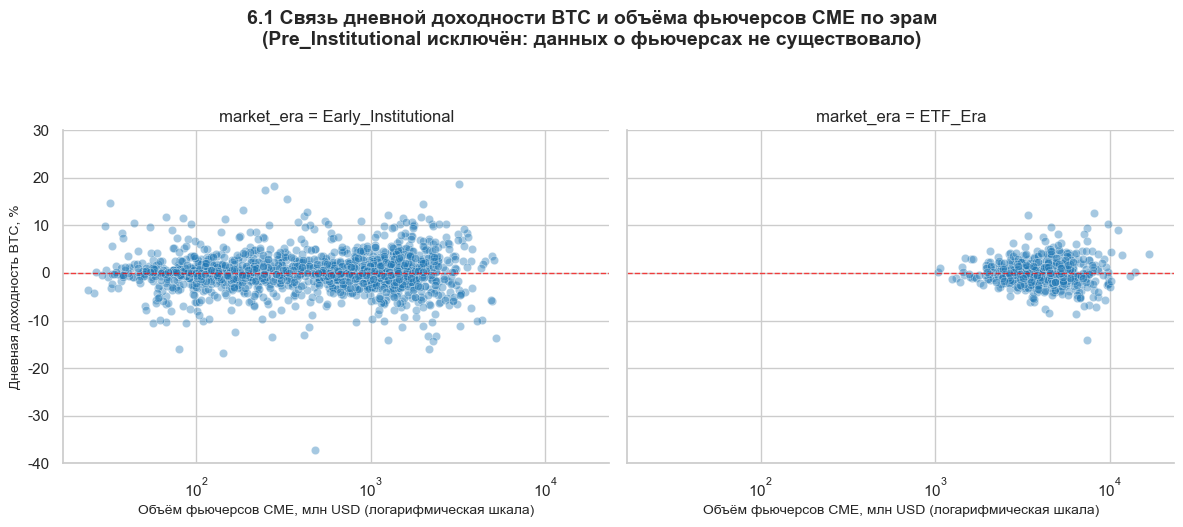

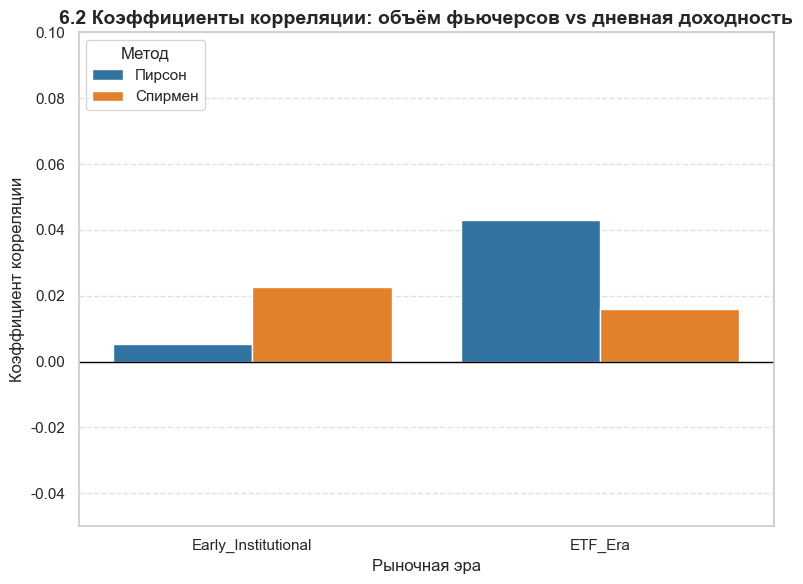

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 0. Настройка окружения и загрузка данных
# ---------------------------------------------------------
# Настройка поддержки кириллицы
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# Загрузка данных
file_path = "btc_comprehensive_analysis.csv"
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])

# Гарантированный расчет дневной доходности (%)
df['Daily_Return_Pct'] = df['Close'].pct_change() * 100

# Фильтрация данных: оставляем только строки, где есть и объём фьючерсов, и доходность
# Это автоматически исключает эру Pre_Institutional и дни с NaN
df_valid = df[['market_era', 'F_Volume_USD_Mln', 'Daily_Return_Pct']].dropna().copy()

# 3. Подготовка данных для корреляции
# Выбираем только нужные столбцы и удаляем строки, где хотя бы одно значение равно NaN.
# Это автоматически уберет эру Pre_Institutional и выходные дни CME.
df_corr = df[['market_era', 'Daily_Return_Pct', 'F_Volume_USD_Mln']].dropna()

# 4. Расчет корреляций по каждой эре
results = []
for era in df_corr['market_era'].unique():
    era_df = df_corr[df_corr['market_era'] == era]
    n_obs = len(era_df)
    
    # Пирсон (линейная связь)
    pearson = era_df['Daily_Return_Pct'].corr(era_df['F_Volume_USD_Mln'], method='pearson')
    
    # Спирмен (ранговая связь, устойчива к выбросам)
    spearman = era_df['Daily_Return_Pct'].corr(era_df['F_Volume_USD_Mln'], method='spearman')
    
    results.append({
        'Эра': era,
        'Наблюдений (N)': n_obs,
        'Пирсон (Pearson)': round(pearson, 4),
        'Спирмен (Spearman)': round(spearman, 4)
    })

# 5. Формирование и вывод таблицы
corr_df = pd.DataFrame(results)
print("Корреляция дневной доходности спота и объёма фьючерсов CME по эрам:\n")
display(corr_df)

# ---------------------------------------------------------
# График 6.1: Scatter plot для каждой эры (с логарифмической шкалой)
# ---------------------------------------------------------
# Используем relplot для создания сетки подграфиков (facets)
g = sns.relplot(
    data=df_valid,
    x='F_Volume_USD_Mln',
    y='Daily_Return_Pct',
    col='market_era',
    col_wrap=2,  # 2 графика в ряд (Early_Institutional и ETF_Era)
    kind='scatter',
    alpha=0.4,
    color='#1f77b4',
    height=5,
    aspect=1.2
)

# Применяем логарифмический масштаб к оси X для корректного сравнения порядков величин
g.set(xscale="log")

# Добавляем горизонтальную линию на уровне 0% доходности для каждого подграфика
for ax in g.axes.flat:
    ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Объём фьючерсов CME, млн USD (логарифмическая шкала)', fontsize=10)
    ax.set_ylabel('Дневная доходность BTC, %', fontsize=10)

# Настраиваем заголовки
g.figure.suptitle('6.1 Связь дневной доходности BTC и объёма фьючерсов CME по эрам\n(Pre_Institutional исключён: данных о фьючерсах не существовало)', 
                  fontsize=14, fontweight='bold', y=1.05)

plt.ylim(-40, 30)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# График 6.2: Столбчатая диаграмма коэффициентов корреляции
# ---------------------------------------------------------
# Расчет корреляций по эрам
corr_results = []
for era in ['Early_Institutional', 'ETF_Era']:
    subset = df_valid[df_valid['market_era'] == era]
    
    # Пирсон (линейная связь, чувствителен к выбросам)
    pearson = subset['F_Volume_USD_Mln'].corr(subset['Daily_Return_Pct'], method='pearson')
    # Спирмен (монотонная связь, устойчив к выбросам)
    spearman = subset['F_Volume_USD_Mln'].corr(subset['Daily_Return_Pct'], method='spearman')
    
    corr_results.append({'Эра': era, 'Метод': 'Пирсон', 'Корреляция': pearson})
    corr_results.append({'Эра': era, 'Метод': 'Спирмен', 'Корреляция': spearman})

corr_df = pd.DataFrame(corr_results)

# Построение столбчатой диаграммы
plt.figure(figsize=(8, 6))
sns.barplot(
    data=corr_df,
    x='Эра',
    y='Корреляция',
    hue='Метод',
    palette=['#1f77b4', '#ff7f0e'] # Синий для Пирсона, оранжевый для Спирмена
)

plt.axhline(0, color='black', linewidth=1) # Нулевая линия
plt.title('6.2 Коэффициенты корреляции: объём фьючерсов vs дневная доходность', fontsize=14, fontweight='bold')
plt.xlabel('Рыночная эра', fontsize=12)
plt.ylabel('Коэффициент корреляции', fontsize=12)
plt.ylim(-0.05, 0.1) # Ограничиваем ось Y для лучшей читаемости слабых корреляций
plt.legend(title='Метод', loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### Краткий вывод

График 6.1: видно, что объёмы фьючерсов в эру ETF_Era увеличились. При этом «разброс» дневной доходности визуально сохраняется в обеих эрах. Высокий объём торгов фьючерсами CME не предсказывает направление дневной доходности BTC. Экстремальные объёмы (пики на графике) встречаются как в дни сильного роста, так и в дни резкого падения, что указывает на то, что фьючерсы активно торгуются в обоих направлениях рынка (хеджирование длинных позиций при падении и спекулятивный спрос при росте).

График 6.2: коэффициенты корреляции Пирсона и Спирмена в обеих эрах остаются близкими к нулю или показывают очень слабую положительную связь. Статистическая связь между объёмом фьючерсов CME и дневной доходностью BTC остаётся крайне слабой в обеих эрах. Небольшой рост коэффициента Пирсона в эру ETF не является практически значимым и не подтверждает гипотезу об усилении корреляции. Разница между Пирсоном и Спирменом в ETF_Era предполагает, что экстремальные дни (выбросы) могут искусственно завышать линейную корреляцию.

Рост абсолютных объёмов фьючерсов в эру ETF не привёл к усилению линейной связи между объёмом торгов и направлением движения цены. Слабая корреляция объясняется тем, что экстремальные объёмы на CME фиксируются как в дни резкого роста, так и в дни резкого падения. Эти разнонаправленные всплески «гасят» друг друга при расчете коэффициента Пирсона. Более высокое значение Спирмена в эру ETF указывает на то, что дни с аномально высокой активностью действительно чаще сопровождаются аномальной волатильностью (вне зависимости от знака), но эта связь нелинейна.

Ограничение: Корреляция не доказывает причинность. Высокий объём может быть следствием движения цены, а не его драйвером. Агрегация всех дней вместе маскирует асимметрию рынка.
Гипотеза для проверки: Чтобы глубже понять природу этой связи, необходимо разделить выборку на две подгруппы: дни с положительной доходностью и дни с отрицательной доходностью, и проверить корреляцию объёма с абсолютной величиной доходности.

### Целевые тепловые карты

#### 7.1 Тепловая карта эры ETF (фокус на гипотезы 3, 4, 6)
- **Цель:** Показать, как связаны между собой цена, притоки ETF и волатильность именно в период присутствия институциональных ETF-фондов.
- **Столбцы:** `Close`, `Daily_Return_Pct`, `ETF_Total_Net_Flow_mln_usd`, `ETF_Cumulative_Flow_mln_usd`, `Volatility_Pct`.
- **Ожидаемый резкльтат:** Подтверждение или опровержение того, что ежедневные притоки в ETF действительно синхронизированы с дневной доходностью BTC.

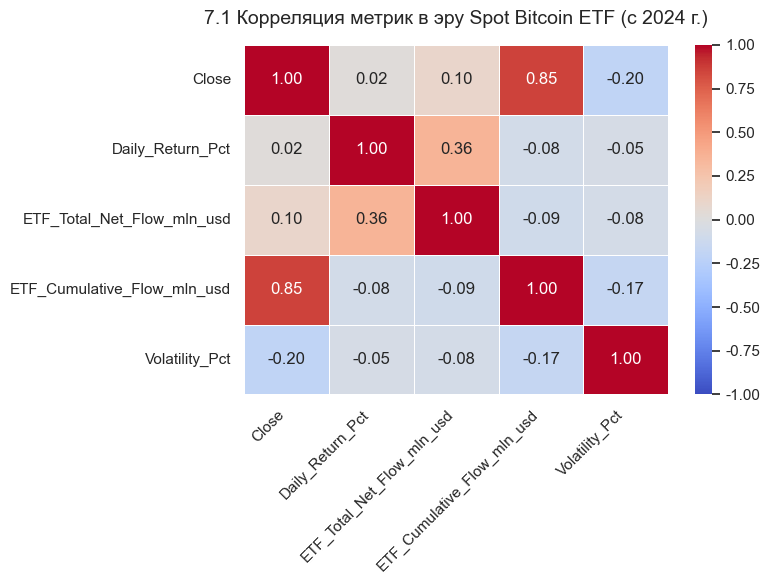

In [20]:
# ============================================================================
# 7.1 Тепловая карта корреляций: Эра ETF (с 2024 г)
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Фильтруем данные только по эре ETF, чтобы избежать искажений из-за NaN
df_etf = df[df['market_era'] == 'ETF_Era'].copy()

# 2. Выбираем релевантные числовые столбцы для анализа взаимосвязей
cols_to_corr = [
    'Close', 
    'Daily_Return_Pct', 
    'ETF_Total_Net_Flow_mln_usd', 
    'ETF_Cumulative_Flow_mln_usd', 
    'Volatility_Pct'
]

# 3. Считаем матрицу корреляций Пирсона 
# (метод .corr() автоматически игнорирует оставшиеся единичные NaN внутри этой выборки)
corr_matrix = df_etf[cols_to_corr].corr()

# 4. Настраиваем визуализацию
plt.figure(figsize=(8, 6))

# Рисуем heatmap с аннотациями (числами), цветовой картой 'coolwarm' 
# (синий = отрицательная корреляция, красный = положительная)
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1,
    linewidths=0.5
)

# 5. Оформляем график согласно правилам (читаемые подписи)
plt.title('7.1 Корреляция метрик в эру Spot Bitcoin ETF (с 2024 г.)', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Показываем график
plt.tight_layout()
plt.show()

#### Краткий вывод

| Связь | Коэффициент | Сила |
|---|---|---|
| `Close` ↔ `ETF_Cumulative_Flow_mln_usd` | +0.85 | Очень сильная |
| `Daily_Return_Pct` ↔ `ETF_Total_Net_Flow_mln_usd` | +0.36 | Умеренная |
| `Close` ↔ `ETF_Total_Net_Flow_mln_usd` | +0.10 | Слабая |
| `Volatility_Pct` ↔ все остальные | от −0.06 до −0.20 | Слабая отрицательная |

Кумулятивный приток ETF и цена BTC движутся почти синхронно (0.85). Это ожидаемо: кумулятивный поток — это накапливающаяся сумма, которая растёт вместе с общим трендом рынка. Сама по себе высокая корреляция здесь малоинформативна — она отражает общий восходящий тренд, а не причинную связь.
Дневной приток ETF умеренно связан с дневной доходностью (0.36). Дни с положительным притоком ETF статистически чаще совпадают с днями роста цены. Это наиболее интересный сигнал карты для проверки гипотезы №3.
Волатильность слабо отрицательно связана со всеми метриками (−0.06…−0.20). В дни активного притока ETF и роста цены дневная волатильность чуть ниже. Это согласуется с идеей, что институциональный капитал может «сглаживать» резкие движения, но эффект небольшой.

Ограничения и гипотезы:
Корреляция ≠ причинность. Приток ETF может быть реакцией на рост цены, а не её причиной. Также возможен общий третий фактор — макро-новости, одобрение регуляторов.
Малая выборка. Эра ETF охватывает относительно небольшое количество дней. Корреляция 0.36 на такой выборке статистически значима, но устойчива ли она во времени — нужно проверять по подпериодам.
Кумулятивный поток (0.85 с ценой) - высокая корреляция здесь почти гарантирована математически (оба ряда имеют общий тренд). Для анализа влияния нужно смотреть именно на дневной поток, а не на кумулятивный.

#### 7.2 Тепловая карта ранней институциональной эры (фокус на гипотезы 5, 6)
- **Цель:** Показать базовую связь между спотовым рынком и фьючерсами CME до появления ETF.
- **Столбцы:** `Close`, `Daily_Return_Pct`, `F_Volume_USD_Mln`, `Futures_Spread_Pct`, `Volatility_Pct`.
- **Ожидаемый результат:** Насколько сильно фьючерсный спред и объем влияли на спотовую доходность до 2024 года.


Период анализа: 2017-12-18 — 2024-01-10
Количество наблюдений: 2215

7.2 КОРРЕЛЯЦИОННАЯ МАТРИЦА: Ранняя институциональная эра
                    Close  Daily_Return_Pct  F_Volume_USD_Mln  \
Close                1.00              0.03              0.79   
Daily_Return_Pct     0.03              1.00              0.01   
F_Volume_USD_Mln     0.79              0.01              1.00   
Futures_Spread_Pct   0.19             -0.29              0.20   
Volatility_Pct       0.08             -0.16              0.28   

                    Futures_Spread_Pct  Volatility_Pct  
Close                             0.19            0.08  
Daily_Return_Pct                 -0.29           -0.16  
F_Volume_USD_Mln                  0.20            0.28  
Futures_Spread_Pct                1.00            0.12  
Volatility_Pct                    0.12            1.00  


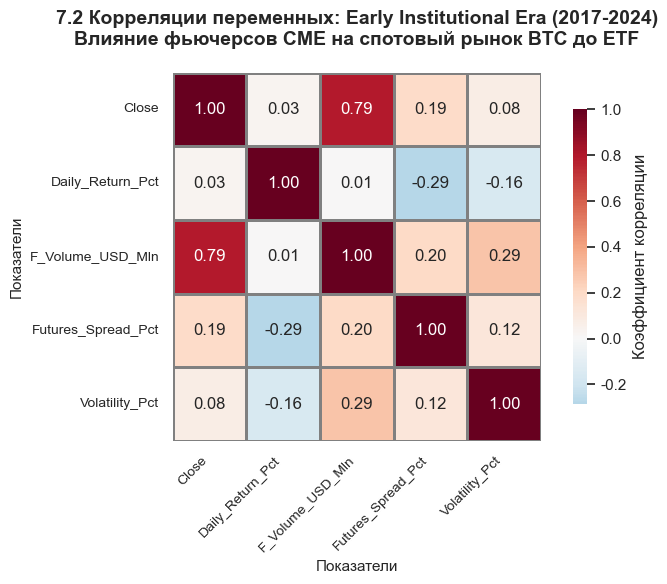

In [21]:
# ============================================================================
# 7.2 Тепловая карта корреляций: Ранняя институциональная эра (2017-2024)
# Фокус: связь спотового рынка BTC с фьючерсами CME до появления ETF
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Настройка кириллицы для графиков
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# 1. Загрузка данных
df = pd.read_csv("btc_comprehensive_analysis.csv", parse_dates=['Date'])

# 2. Фильтрация: только ранняя институциональная эра (до появления ETF)
df_early = df[df['market_era'] == 'Early_Institutional'].copy()

print(f"Период анализа: {df_early['Date'].min().date()} — {df_early['Date'].max().date()}")
print(f"Количество наблюдений: {len(df_early)}")

# 3. Выбор ключевых столбцов для анализа
columns_to_analyze = [
    'Close',                    # Цена спота
    'Daily_Return_Pct',         # Дневная доходность спота (%)
    'F_Volume_USD_Mln',         # Объем фьючерсов CME (млн USD)
    'Futures_Spread_Pct',       # Фьючерсный спред/премия (%)
    'Volatility_Pct'            # Дневная волатильность (%)
]

# 4. Расчет корреляционной матрицы
corr_matrix = df_early[columns_to_analyze].corr(method='pearson')

print("\n" + "="*70)
print("7.2 КОРРЕЛЯЦИОННАЯ МАТРИЦА: Ранняя институциональная эра")
print("="*70)
print(corr_matrix.round(3))

# 5. Визуализация тепловой карты
fig, ax = plt.subplots(figsize=(8, 6))

# Создаем тепловую карту с аннотациями
sns.heatmap(
    corr_matrix,
    annot=True,           # Показываем значения корреляции
    fmt='.2f',            # Формат: 2 знака после запятой
    cmap='RdBu_r',        # Цветовая схема: красно-синяя (красный = отрицательная, синий = положительная)
    center=0,             # Центрируем на 0
    square=True,          # Квадратные ячейки
    linewidths=1,         # Линии между ячейками
    linecolor='gray',     # Цвет линий
    cbar_kws={'shrink': 0.8, 'label': 'Коэффициент корреляции'},
    ax=ax
)

# Настройка заголовка и подписей
plt.title(
    '7.2 Корреляции переменных: Early Institutional Era (2017-2024)\n'
    'Влияние фьючерсов CME на спотовый рынок BTC до ETF',
    fontsize=14,
    fontweight='bold',
    pad=20
)

plt.xlabel('Показатели', fontsize=11)
plt.ylabel('Показатели', fontsize=11)

# Поворот подписей для лучшей читаемости
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Автоматическая подгонка макета
plt.tight_layout()

plt.show()

#### Краткий вывод

| Связь | Коэффициент | Сила |
|---|---|---|
| `Close` ↔ `F_Volume_USD_Mln` | +0.79 | Очень сильная |
| `Daily_Return_Pct` ↔ `Futures_Spread_Pct` | −0.29 | Умеренная отрицательная |
| `F_Volume_USD_Mln` ↔ `Volatility_Pct` | +0.29 | Слабая положительная |
| `Daily_Return_Pct` ↔ `Volatility_Pct` | −0.16 | Слабая отрицательная |
| `Daily_Return_Pct` ↔ `F_Volume_USD_Mln` | +0.01 | Практически нулевая |
| `Close` ↔ `Futures_Spread_Pct` | +0.19 | Слабая |

Объём фьючерсов CME сильно коррелирует с ценой BTC (0.79). Это ожидаемо: в период 2017–2024 рынок в целом рос, и объёмы торгов росли вместе с ценой. Корреляция отражает общий тренд, а не причинную связь.
Фьючерсный спред отрицательно связан с дневной доходностью (−0.29). В дни, когда фьючерс торговался с премией (положительный спред), спотовая цена чаще снижалась или росла слабее. Это согласуется с гипотезой №5: высокая премия на фьючерсах может сигнализировать о «перегретости» и последующей коррекции.
Связь между объёмом фьючерсов и дневной доходностью спота почти нулевая (0.01). Это ключевой результат для гипотезы №6: в раннюю институциональную эру объём торгов на CME не был предиктором направления движения спотовой цены.
Волатильность слабо связана с объёмом фьючерсов (0.29) и слабо отрицательно — с доходностью (−0.16). Высокие объёмы фьючерсов немного сопутствуют более волатильным дням, но связь не сильная.

Ограничения и гипотезы:
Корреляция ≠ причинность. Сильная связь `Close` ↔ `F_Volume_USD_Mln` (0.79) — это в значительной степени эффект общего тренда. 
Практически нулевая связь `Daily_Return_Pct` ↔ `F_Volume_USD_Mln` (0.01) говорит о том, что в период до ETF фьючерсы CME не оказывали заметного краткосрочного влияния на направление спотовой цены. Это важный контраст с эрой ETF, где нужно проверить, изменилась ли картина.
Ограничение выборки: период 2017–2024 включает как бычий рынок 2020–2021, так и медвежий 2022. Корреляции усреднены по разным режимам и могут маскировать различия внутри эры.

### Дополнительный расчет

#### 8.1 Расчёт корреляции с лагом (Lag-1 correlation)

Расчёт корреляции с лагом (Lag-1) — это классический и необходимый шаг для проверки гипотезы о причинно-следственной связи во временных рядах. Он позволяет ответить на вопрос: "Влияет ли вчерашний приток денег в ETF на сегодняшнюю доходность BTC, или приток просто реагирует на сегодняшнее движение цены?" Это даст возможность ответить на вопрос причинности, поднятый в гипотезах.

Размер выборки для анализа лагов: 431 дней
----------------------------------------------------------------------

СРАВНЕНИЕ КОРРЕЛЯЦИЙ:
     Тип связи                            Переменные  Пирсон (Линейная)  Спирмен (Ранговая)
Same-day (Т-0)   Поток ETF (T) vs Доходность BTC (T)               0.32                0.31
   Lag-1 (T-1) Поток ETF (T-1) vs Доходность BTC (T)               0.01                0.02
----------------------------------------------------------------------


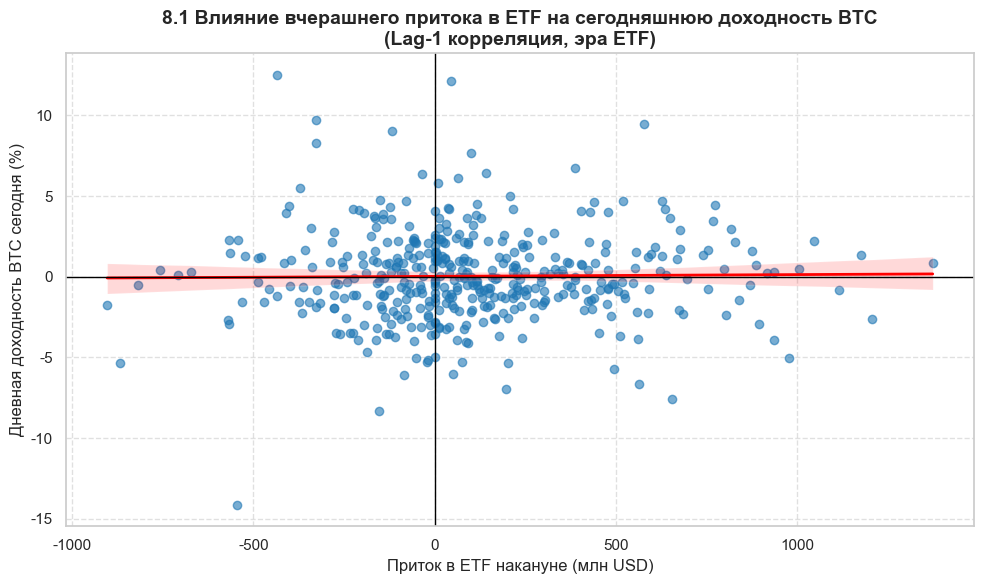

In [22]:
# ============================================================================
# 8.1 Расчёт корреляции с лагом (Lag-1 correlation)
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. Загрузка и подготовка данных
# ==============================================================================
# Загружаем основной датасет
df = pd.read_csv('btc_comprehensive_analysis.csv')

# Гарантируем, что Date является типом datetime и данные отсортированы хронологически
# (Это критически важно для корректной работы функции .shift())
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Гарантируем наличие столбца дневной доходности
df['Daily_Return_Pct'] = df['Close'].pct_change() * 100

# ==============================================================================
# 2. Фильтрация и создание лаговой переменной
# ==============================================================================
# Оставляем только эру ETF, так как до 2024 года потоков не существовало
df_etf = df[df['market_era'] == 'ETF_Era'].copy()

# Создаем лаговую переменную: сдвигаем поток ETF на 1 день вниз
# Теперь в строке с датой "Сегодня" в столбце ETF_Flow_Lag1 лежит значение "Вчера"
df_etf['ETF_Flow_Lag1'] = df_etf['ETF_Total_Net_Flow_mln_usd'].shift(1)

# Удаляем строки с NaN (первая строка эры ETF станет NaN после сдвига, 
# также удалятся дни, когда ETF не торгуется)
df_corr = df_etf[['ETF_Total_Net_Flow_mln_usd', 'ETF_Flow_Lag1', 'Daily_Return_Pct']].dropna()

print(f"Размер выборки для анализа лагов: {len(df_corr)} дней")
print("-" * 70)

# ==============================================================================
# 3. Расчёт коэффициентов корреляции
# ==============================================================================
# Словарь для сбора результатов
results = []

# 3.1. Same-day корреляция (Базовый уровень: поток сегодня vs доходность сегодня)
pearson_same = df_corr['ETF_Total_Net_Flow_mln_usd'].corr(df_corr['Daily_Return_Pct'], method='pearson')
spearman_same = df_corr['ETF_Total_Net_Flow_mln_usd'].corr(df_corr['Daily_Return_Pct'], method='spearman')

results.append({
    'Тип связи': 'Same-day (Т-0)',
    'Переменные': 'Поток ETF (T) vs Доходность BTC (T)',
    'Пирсон (Линейная)': round(pearson_same, 4),
    'Спирмен (Ранговая)': round(spearman_same, 4)
})

# 3.2. Lag-1 корреляция (Проверка гипотезы: поток вчера vs доходность сегодня)
pearson_lag1 = df_corr['ETF_Flow_Lag1'].corr(df_corr['Daily_Return_Pct'], method='pearson')
spearman_lag1 = df_corr['ETF_Flow_Lag1'].corr(df_corr['Daily_Return_Pct'], method='spearman')

results.append({
    'Тип связи': 'Lag-1 (T-1)',
    'Переменные': 'Поток ETF (T-1) vs Доходность BTC (T)',
    'Пирсон (Линейная)': round(pearson_lag1, 4),
    'Спирмен (Ранговая)': round(spearman_lag1, 4)
})

# Вывод таблицы результатов
corr_df = pd.DataFrame(results)
print("\nСРАВНЕНИЕ КОРРЕЛЯЦИЙ:")
print(corr_df.to_string(index=False))
print("-" * 70)

# ==============================================================================
# 4. Визуализация Lag-1 связи
# ==============================================================================
plt.figure(figsize=(10, 6))

# Используем regplot для отображения точек и линии линейной регрессии
sns.regplot(
    x='ETF_Flow_Lag1', 
    y='Daily_Return_Pct', 
    data=df_corr,
    scatter_kws={'alpha': 0.6, 'color': '#1f77b4'}, # Прозрачность точек
    line_kws={'color': 'red', 'linewidth': 2}      # Линия тренда
)

# Оформление графика
plt.title('8.1 Влияние вчерашнего притока в ETF на сегодняшнюю доходность BTC\n(Lag-1 корреляция, эра ETF)', fontsize=14, fontweight='bold')
plt.xlabel('Приток в ETF накануне (млн USD)', fontsize=12)
plt.ylabel('Дневная доходность BTC сегодня (%)', fontsize=12)

# Добавляем нулевые линии для удобства чтения знаков
plt.axhline(0, color='black', linewidth=1, linestyle='-')
plt.axvline(0, color='black', linewidth=1, linestyle='-')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### Краткий вывод

Same-day корреляция (T-0): Пирсон = 0.32, Спирмен = 0.31. Умеренная положительная связь между дневным притоком в ETF и дневной доходностью BTC.
Lag-1 корреляция (T-1): Пирсон = 0.01, Спирмен = 0.02. Связь практически отсутствует.
Визуально: На scatter plot линия регрессии почти горизонтальна, доверительный интервал (розовая зона) широкий и пересекает ноль по всей оси X.

Вчерашний приток в ETF не предсказывает сегодняшнюю доходность BTC. Если бы институциональные покупки оказывали запаздывающее давление на цену, мы бы увидели положительную Lag-1 корреляцию. Её отсутствие (0.01) опровергает эту гипотезу для дневного таймфрейма.
Связь Same-day (0.32), скорее всего, отражает реакцию, а не причину. Институционалы и розничные инвесторы покупают ETF в дни, когда цена уже растёт (импульсные покупки, ребалансировка на фоне позитивных новостей). Приток следует за движением цены внутри дня, а не предшествует ему.

Ограничение и гипотеза:
Анализ лага T-1 проверяет только влияние на следующий день. Эффект от крупных притоков может накапливаться дольше (T+2, T+5) или проявляться в изменении волатильности, а не направления цены. Также выборка 431 день ограничена только эрой ETF — выводы не распространяются на более ранние периоды.
Чтобы окончательно разделить причину и следствие, нужно проверить обратную Lag-1: корреляцию между `Daily_Return_Pct (T-1)` и `ETF_Total_Net_Flow_mln_usd (T)`. Если она окажется выше, чем прямая Lag-1, это будет прямым доказательством того, что приток в ETF является реакцией на вчерашний рост цены.

### ABC-анализ не уместен

Данный датасет — это временной ряд (daily frequency), а не совокупность объектов. ABC-анализ классически применяется к товарам, клиентам — то есть к независимым сущностям, по которым можно агрегировать вклад. В данном датасете единица наблюдения — это день, а не объект. Ранжировать 4175 дней по объёму торгов бессмысленно: дни не являются независимыми «вкладами» в общий результат, они образуют непрерывный процесс.

### RFM-анализ не уместен

RFM-анализ создан для сегментации множества объектов (например, клиентов интернет-магазина) по их поведению. В данном датасете единица наблюдения — это один торговый день на рынке Bitcoin. В нем нет множества объектов, которые можно было бы ранжировать и делить на сегменты.

### XYZ-анализ не уместен

В датасете только один объект — Bitcoin. XYZ-анализ требует множества объектов (товаров, активов) для их классификации на группы X/Y/Z по степени стабильности. 

### Проверка исходных данных 

Чтобы еще раз убедиться в правильности расчетов.

In [23]:
import pandas as pd
import numpy as np

# Загрузка данных
file_path = "btc_comprehensive_analysis.csv"
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])

# ---------------------------------------------------------
# 1. Проверка исходных данных: посмотрим на реальные значения
# ---------------------------------------------------------
print("=" * 80)
print("ПРОВЕРКА ИСХОДНЫХ ДАННЫХ")
print("=" * 80)

# Выборка случайных дней из разных эр для проверки
sample_dates = {
    'Early_Institutional (будний день)': '2020-06-15',
    'Early_Institutional (выходной)': '2020-06-13',
    'ETF_Era (будний день)': '2024-03-15',
    'ETF_Era (выходной)': '2024-03-16'
}

print("\nПримеры значений объема в разные дни:")
for label, date_str in sample_dates.items():
    row = df[df['Date'] == date_str]
    if not row.empty:
        print(f"\n{label} ({date_str}):")
        print(f"  Volume_mln (спот): {row['Volume_mln'].values[0]:.2f} млн USD")
        print(f"  F_Volume_USD_Mln (фьючерсы): {row['F_Volume_USD_Mln'].values[0]:.2f} млн USD")
        print(f"  Сумма: {row['Volume_mln'].values[0] + row['F_Volume_USD_Mln'].values[0]:.2f} млн USD")

# ---------------------------------------------------------
# 2. Проверка расчета доли фьючерсов
# ---------------------------------------------------------
print("\n" + "=" * 80)
print("ПРОВЕРКА РАСЧЕТА ДОЛИ ФЬЮЧЕРСОВ")
print("=" * 80)

# Пересчитываем долю
total_volume = df['Volume_mln'] + df['F_Volume_USD_Mln']
df['Futures_Share_Pct_check'] = np.where(
    total_volume > 0,
    (df['F_Volume_USD_Mln'] / total_volume) * 100,
    np.nan
)

# Смотрим на статистику по эрам
print("\nСтатистика доли фьючерсов по эрам:")
era_stats = df.groupby('market_era')['Futures_Share_Pct_check'].agg(['count', 'mean', 'median', 'min', 'max', 'std'])
print(era_stats.round(2))

# ---------------------------------------------------------
# 3. Альтернативный расчет: возможно, Volume_mln уже включает фьючерсы?
# ---------------------------------------------------------
print("\n" + "=" * 80)
print("АЛЬТЕРНАТИВНАЯ ГИПОТЕЗА: Volume_mln = общий объем (спот + фьючерсы)")
print("=" * 80)

# Если Volume_mln уже является общим объемом, то формула должна быть:
df['Futures_Share_Pct_alt'] = np.where(
    df['Volume_mln'] > 0,
    (df['F_Volume_USD_Mln'] / df['Volume_mln']) * 100,
    np.nan
)

print("\nСтатистика альтернативного расчета:")
era_stats_alt = df.groupby('market_era')['Futures_Share_Pct_alt'].agg(['count', 'mean', 'median', 'min', 'max', 'std'])
print(era_stats_alt.round(2))

# ---------------------------------------------------------
# 4. Проверка: исключаем ли мы выходные дни (когда CME закрыт)?
# ---------------------------------------------------------
print("\n" + "=" * 80)
print("ПРОВЕРКА: ВЛИЯНИЕ ВЫХОДНЫХ ДНЕЙ")
print("=" * 80)

df['day_of_week'] = df['Date'].dt.dayofweek  # 0=понедельник, 6=воскресенье

# Считаем долю только по будним дням (когда CME торгуется)
df_weekdays = df[df['day_of_week'] < 5].copy()
df_weekdays['Futures_Share_Pct_weekday'] = np.where(
    (df_weekdays['Volume_mln'] + df_weekdays['F_Volume_USD_Mln']) > 0,
    (df_weekdays['F_Volume_USD_Mln'] / (df_weekdays['Volume_mln'] + df_weekdays['F_Volume_USD_Mln'])) * 100,
    np.nan
)

print("\nСтатистика доли фьючерсов только по будним дням:")
era_stats_weekday = df_weekdays.groupby('market_era')['Futures_Share_Pct_weekday'].agg(['count', 'mean', 'median', 'min', 'max'])
print(era_stats_weekday.round(2))

ПРОВЕРКА ИСХОДНЫХ ДАННЫХ

Примеры значений объема в разные дни:

Early_Institutional (будний день) (2020-06-15):
  Volume_mln (спот): 26699.70 млн USD
  F_Volume_USD_Mln (фьючерсы): 276.10 млн USD
  Сумма: 26975.80 млн USD

Early_Institutional (выходной) (2020-06-13):
  Volume_mln (спот): 17564.30 млн USD
  F_Volume_USD_Mln (фьючерсы): nan млн USD
  Сумма: nan млн USD

ETF_Era (будний день) (2024-03-15):
  Volume_mln (спот): 78320.50 млн USD
  F_Volume_USD_Mln (фьючерсы): 5484.40 млн USD
  Сумма: 83804.90 млн USD

ETF_Era (выходной) (2024-03-16):
  Volume_mln (спот): 46842.20 млн USD
  F_Volume_USD_Mln (фьючерсы): nan млн USD
  Сумма: nan млн USD

ПРОВЕРКА РАСЧЕТА ДОЛИ ФЬЮЧЕРСОВ

Статистика доли фьючерсов по эрам:
                     count  mean  median  min   max  std
market_era                                              
ETF_Era                531  8.20    7.88 0.00 16.60 2.40
Early_Institutional   1526  2.94    2.42 0.00 13.45 2.25
Pre_Institutional        0   NaN     NaN  NaN   

## 11. Итоговый дашборд

Дашборд собирает главные визуализации по всем 6 гипотезам в единую сетку 3x3.

| | Столбец 1 | Столбец 2 | Столбец 3 |
|---|---|---|---|
| **Ряд 1** | 1. Волатильность по циклам | 2. Динамика волатильности | 3. Доля фьючерсов по эрам |
| **Ряд 2** | 4. Тренд доли фьючерсов | 5. Приток ETF vs доходность спота | 6. Кумулятивный приток ETF и цена спота |
| **Ряд 3** | 7. Спред фьючерсов по эрам | 8. Спред фьючерсов во времени | 9. Тепловая карта корреляций (эра ETF) |


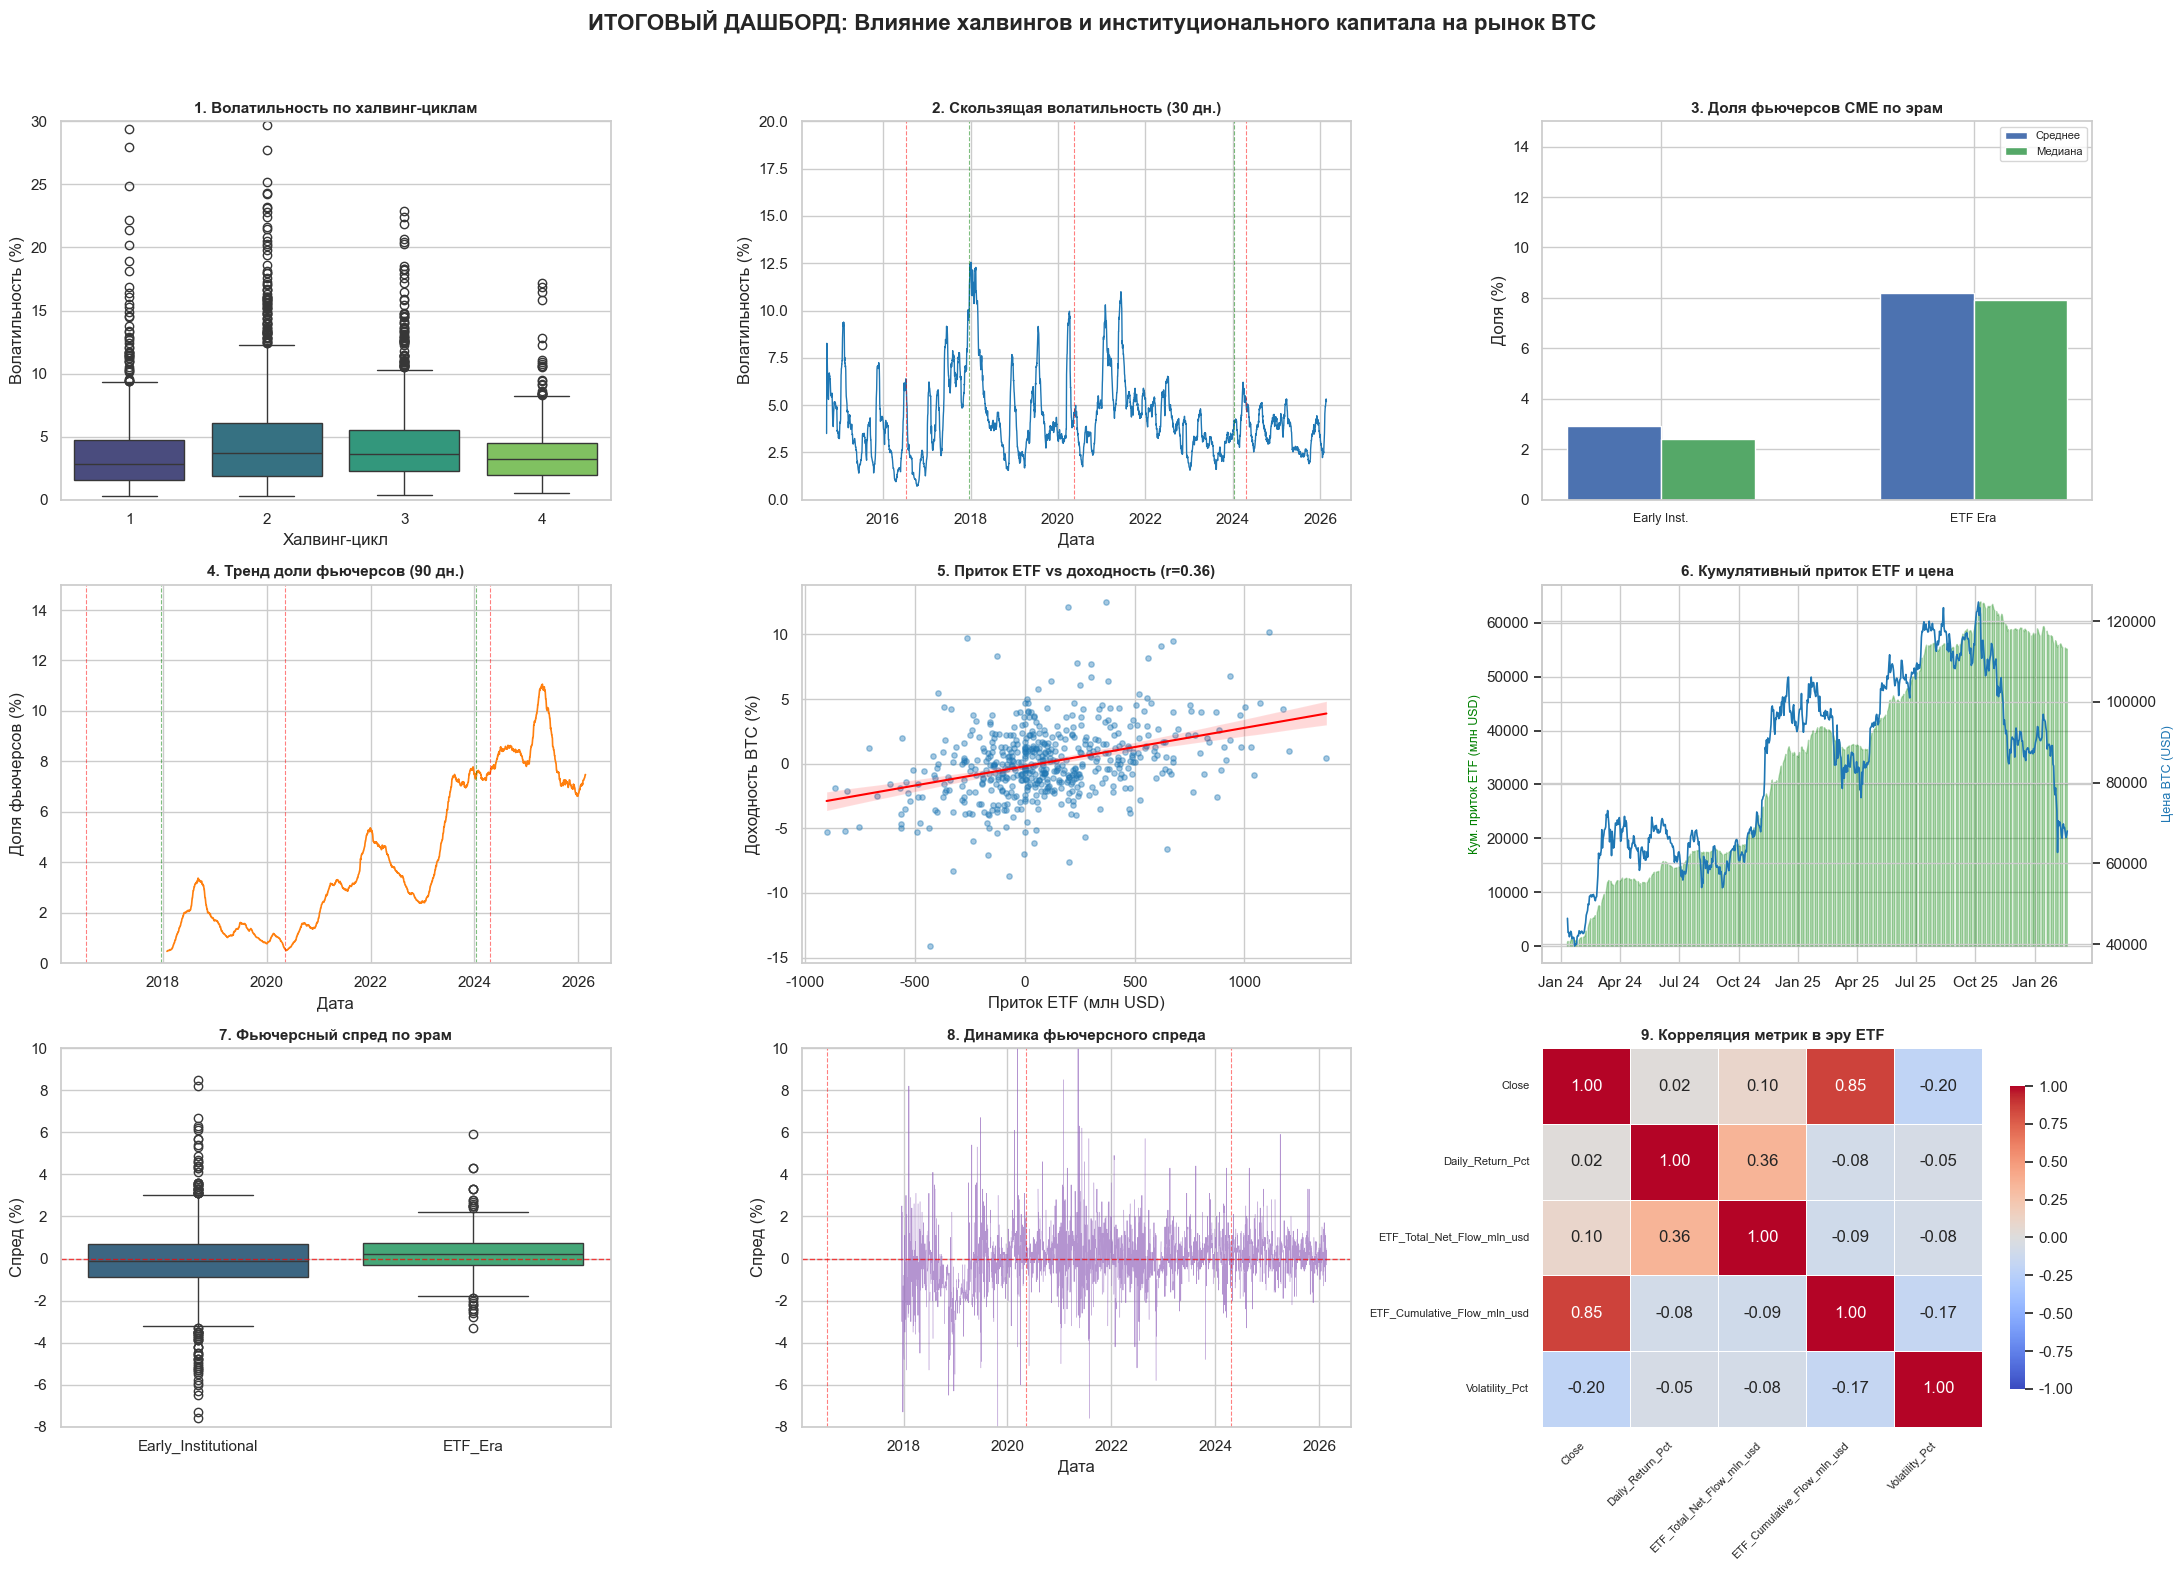

✅ Дашборд построен и сохранён в файл btc_dashboard_final_v2.png


In [24]:
# ==============================================================================
# ИТОГОВЫЙ ДАШБОРД: 9 ключевых графиков анализа (Обновленная версия)
# ==============================================================================
# Изменение: График 9 заменен на тепловую карту корреляций метрик эры ETF.
# Требует, чтобы датасет df был уже загружен и подготовлен.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Настройка кириллицы и стиля
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", palette="muted")

# Словари дат для аннотаций
halving_dates = {
    'Халвинг 2016': '2016-07-09',
    'Халвинг 2020': '2020-05-11',
    'Халвинг 2024': '2024-04-19'
}
era_dates = {
    'CME': '2017-12-18',
    'ETF': '2024-01-11'
}

# Создаём фигуру 3x3
fig, axes = plt.subplots(3, 3, figsize=(22, 16))
fig.suptitle(
    'ИТОГОВЫЙ ДАШБОРД: Влияние халвингов и институционального капитала на рынок BTC',
    fontsize=16, fontweight='bold', y=0.98
)

# Вспомогательная функция для вертикальных линий событий
def add_event_lines(ax, dates_dict, color, ymin=0, ymax=1):
    for label, date_str in dates_dict.items():
        d = pd.to_datetime(date_str)
        ax.axvline(d, color=color, linestyle='--', linewidth=0.8, alpha=0.5)

# ==============================================================================
# ГРАФИКИ 1-8 (Остаются без изменений)
# ==============================================================================

# 1. Boxplot волатильности по халвинг-циклам
ax1 = axes[0, 0]
sns.boxplot(x=df['halving_cycle'].astype(str), y=df['Volatility_Pct'], 
            hue=df['halving_cycle'].astype(str), palette="viridis", legend=False, ax=ax1)
ax1.set_title('1. Волатильность по халвинг-циклам', fontsize=11, fontweight='bold')
ax1.set_xlabel('Халвинг-цикл'); ax1.set_ylabel('Волатильность (%)'); ax1.set_ylim(0, 30)

# 2. Скользящая волатильность (30 дней)
ax2 = axes[0, 1]
df_sorted = df.sort_values('Date').copy()
df_sorted['Vol_30d'] = df_sorted['Volatility_Pct'].rolling(window=30, min_periods=1).mean()
ax2.plot(df_sorted['Date'], df_sorted['Vol_30d'], color='#1f77b4', linewidth=1)
add_event_lines(ax2, halving_dates, 'red'); add_event_lines(ax2, era_dates, 'green')
ax2.set_title('2. Скользящая волатильность (30 дн.)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Дата'); ax2.set_ylabel('Волатильность (%)'); ax2.set_ylim(0, 20)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y')); ax2.xaxis.set_major_locator(mdates.YearLocator(2))

# 3. Доля фьючерсов CME по эрам (bar)
ax3 = axes[0, 2]
df_futures = df[df['market_era'] != 'Pre_Institutional'].copy()
era_stats = df_futures.groupby('market_era')['Futures_Share_Pct'].agg(['mean', 'median']).loc[['Early_Institutional', 'ETF_Era']]
x_pos = np.arange(len(era_stats)); width = 0.3
ax3.bar(x_pos - width/2, era_stats['mean'], width, label='Среднее', color='#4C72B0')
ax3.bar(x_pos + width/2, era_stats['median'], width, label='Медиана', color='#55A868')
ax3.set_xticks(x_pos); ax3.set_xticklabels(['Early Inst.', 'ETF Era'], fontsize=9)
ax3.set_title('3. Доля фьючерсов CME по эрам', fontsize=11, fontweight='bold')
ax3.set_ylabel('Доля (%)'); ax3.legend(fontsize=8); ax3.set_ylim(0, 15)

# 4. Скользящая доля фьючерсов (90 дней)
ax4 = axes[1, 0]
df_sorted['Fut_90d'] = df_sorted['Futures_Share_Pct'].rolling(window=90, min_periods=30).mean()
ax4.plot(df_sorted['Date'], df_sorted['Fut_90d'], color='#ff7f0e', linewidth=1.2)
add_event_lines(ax4, halving_dates, 'red'); add_event_lines(ax4, era_dates, 'green')
ax4.set_title('4. Тренд доли фьючерсов (90 дн.)', fontsize=11, fontweight='bold')
ax4.set_xlabel('Дата'); ax4.set_ylabel('Доля фьючерсов (%)'); ax4.set_ylim(0, 15)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y')); ax4.xaxis.set_major_locator(mdates.YearLocator(2))

# 5. Scatter — приток ETF vs дневная доходность
ax5 = axes[1, 1]
df_etf_scatter = df[df['market_era'] == 'ETF_Era'][['ETF_Total_Net_Flow_mln_usd', 'Daily_Return_Pct']].dropna()
sns.regplot(x='ETF_Total_Net_Flow_mln_usd', y='Daily_Return_Pct', data=df_etf_scatter,
            scatter_kws={'alpha': 0.4, 'color': '#1f77b4', 's': 15}, line_kws={'color': 'red', 'linewidth': 1.5}, ax=ax5)
pearson_same = df_etf_scatter['ETF_Total_Net_Flow_mln_usd'].corr(df_etf_scatter['Daily_Return_Pct'])
ax5.set_title(f'5. Приток ETF vs доходность (r={pearson_same:.2f})', fontsize=11, fontweight='bold')
ax5.set_xlabel('Приток ETF (млн USD)'); ax5.set_ylabel('Доходность BTC (%)')

# 6. Кумулятивный приток ETF и цена BTC (dual-axis)
ax6 = axes[1, 2]
df_etf = df[df['market_era'] == 'ETF_Era'].sort_values('Date')
ax6_twin = ax6.twinx()
ax6.fill_between(df_etf['Date'], df_etf['ETF_Cumulative_Flow_mln_usd'], alpha=0.3, color='green')
ax6.set_ylabel('Кум. приток ETF (млн USD)', color='green', fontsize=9)
ax6_twin.plot(df_etf['Date'], df_etf['Close'], color='#1f77b4', linewidth=1.2)
ax6_twin.set_ylabel('Цена BTC (USD)', color='#1f77b4', fontsize=9)
ax6.set_title('6. Кумулятивный приток ETF и цена', fontsize=11, fontweight='bold')
ax6.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))

# 7. Boxplot фьючерсного спреда по эрам
ax7 = axes[2, 0]
df_spread = df[df['market_era'] != 'Pre_Institutional'].copy()
df_spread['market_era'] = pd.Categorical(df_spread['market_era'], categories=['Early_Institutional', 'ETF_Era'], ordered=True)
sns.boxplot(x='market_era', y='Futures_Spread_Pct', data=df_spread, palette="viridis", hue='market_era', legend=False, ax=ax7)
ax7.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax7.set_title('7. Фьючерсный спред по эрам', fontsize=11, fontweight='bold')
ax7.set_xlabel(''); ax7.set_ylabel('Спред (%)'); ax7.set_ylim(-8, 10)

# 8. Фьючерсный спред во времени
ax8 = axes[2, 1]
df_spread_sorted = df_spread.sort_values('Date')
ax8.plot(df_spread_sorted['Date'], df_spread_sorted['Futures_Spread_Pct'], color='#9467bd', linewidth=0.5, alpha=0.7)
ax8.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
add_event_lines(ax8, halving_dates, 'red')
ax8.set_title('8. Динамика фьючерсного спреда', fontsize=11, fontweight='bold')
ax8.set_xlabel('Дата'); ax8.set_ylabel('Спред (%)'); ax8.set_ylim(-8, 10)
ax8.xaxis.set_major_formatter(mdates.DateFormatter('%Y')); ax8.xaxis.set_major_locator(mdates.YearLocator(2))


# ==============================================================================
# ГРАФИК 9 (НОВЫЙ): Тепловая карта корреляций в эру ETF
# Вопрос: Как связаны между собой ключевые метрики в период ETF?
# ==============================================================================
ax9 = axes[2, 2]

# 1. Фильтруем данные только по эре ETF
df_etf_corr = df[df['market_era'] == 'ETF_Era'].copy()

# 2. Выбираем релевантные числовые столбцы для анализа взаимосвязей
cols_to_corr = [
    'Close', 
    'Daily_Return_Pct', 
    'ETF_Total_Net_Flow_mln_usd', 
    'ETF_Cumulative_Flow_mln_usd', 
    'Volatility_Pct'
]

# 3. Считаем матрицу корреляций Пирсона (автоматически игнорирует NaN)
corr_matrix = df_etf_corr[cols_to_corr].corr(method='pearson')

# 4. Рисуем heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,       # Показываем значения корреляции внутри ячеек
    fmt=".2f",        # Формат: 2 знака после запятой
    cmap='coolwarm',  # Цветовая карта (синий = минус, красный = плюс)
    vmin=-1, vmax=1,  # Фиксируем шкалу от -1 до 1
    linewidths=0.5,   # Разделительные линии между ячейками
    ax=ax9,
    cbar_kws={'shrink': 0.8} # Уменьшаем шкалу цветов
)

# 5. Оформляем подписи для читаемости
ax9.set_title('9. Корреляция метрик в эру ETF', fontsize=11, fontweight='bold')
ax9.set_xticklabels(ax9.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax9.set_yticklabels(ax9.get_yticklabels(), rotation=0, fontsize=8)

# ==============================================================================
# Финальное оформление
# ==============================================================================
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('btc_dashboard_final_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Дашборд построен и сохранён в файл btc_dashboard_final_v2.png")

## 12. Итоговые выводы

### 1. Волатильность BTC снижается от цикла к циклу
* **Факт:** Медианная дневная волатильность BTC последовательно снижается: со 2-го халвинг-цикла (4.82%) до 4-го цикла (3.57%).
* **Интерпретация:** Это указывает на структурное взросление рынка. По мере роста капитализации и прихода институциональных игроков (фьючерсы CME, затем ETF) рынку требуется значительно больший объем капитала для создания ценовых движений той же амплитуды, что и в эпоху доминирования розничных трейдеров.
* **Ограничение:** Выборка 4-го цикла пока мала (данные доступны только с апреля 2024 года). Узкий разброс на графике обусловлен не только стабильностью, но и коротким периодом наблюдения, поэтому делать окончательные выводы о его стабильности преждевременно.

### 2. Фьючерсы CME стали структурно значимой частью рынка
* **Факт:** Медианная доля фьючерсов CME в общем обороте выросла с ~2.4% в раннюю институциональную эру до ~7.9% в эру ETF (рост более чем в 3 раза).
* **Интерпретация:** Фьючерсы перестали быть нишевым инструментом. Ускорение роста их доли совпадает с периодами высокой волатильности, что говорит об активном использовании деривативов крупными игроками для хеджирования рисков в моменты рыночного стресса.
* **Ограничение:** Рост абсолютных значений доли фьючерсов может быть частично обусловлен общим ростом цены BTC и увеличением ликвидности в принципе, а не только качественным изменением поведения участников.

### 3. Дневной приток в ETF умеренно связан с дневной доходностью BTC
* **Факт:** Коэффициент корреляции Пирсона между дневным чистым притоком в спотовые ETF и дневной доходностью BTC составляет около 0.32–0.36.
* **Интерпретация:** Существует слабая, но статистически заметная положительная связь: в дни с чистым притоком капитала цена закрытия BTC с большей вероятностью растет. Однако разброс точек вокруг линии тренда очень велик, что означает: приток объясняет лишь малую долю дневной изменчивости цены.
* **Ограничение:** Корреляция не доказывает причинность. Приток в ETF с высокой вероятностью является *реакцией* на уже произошедший внутридневной рост цены (импульсные покупки, ребалансировка), а не его первичным драйвером.

### 4. Вчерашний приток в ETF не предсказывает сегодняшнюю цену
* **Факт:** Корреляция между притоком в ETF в день T-1 и доходностью BTC в день T практически отсутствует (Пирсон ≈ 0.01, Спирмен ≈ 0.02).
* **Интерпретация:** Это опровергает гипотезу о том, что институциональные покупки оказывают запаздывающее давление на цену на дневном таймфрейме. Если бы крупные заявки двигали рынок с задержкой, мы бы увидели положительную связь, но её нет.
* **Ограничение:** Анализ лага T-1 проверяет влияние только на один следующий день. Эффект от крупных притоков может накапливаться дольше (T+2, T+5) или проявляться в изменении волатильности, а не в направлении цены.

### 5. Кумулятивный приток и цена BTC имеют высокую математическую связь
* **Факт:** Наблюдается очень высокая корреляция (Пирсон ≈ 0.85) между накопительным (кумулятивным) притоком капитала в ETF и уровнем цены BTC в эру ETF.
* **Интерпретация:** Визуально оба показателя движутся синхронно вверх, что согласуется с общим тезисом о том, что институциональный капитал стал значимым фактором присутствия на рынке в этот период.
* **Ограничение:** Это классический пример ложной корреляции нестационарных временных рядов. Кумулятивный показатель по своей природе монотонно растет (если нет массовых оттоков), поэтому он автоматически создает высокую корреляцию с любым активом, который в среднем растет. Это не доказывает причинно-следственную связь.

### 6. Объём торгов фьючерсами не предсказывает направление цены
* **Факт:** Корреляция между объёмом торгов фьючерсами CME и дневной доходностью спота близка к нулю в обеих эрах (Пирсон ≈ 0.01 в эру ETF).
* **Интерпретация:** Высокий объём торгов не означает однозначного движения цены вверх или вниз. Экстремальные объёмы встречаются как в дни сильного роста, так и в дни резкого падения, что указывает на то, что фьючерсы активно используются для разных целей: спекулятивного спроса при росте и хеджирования при падении.
* **Ограничение:** Агрегация всех дней вместе маскирует асимметрию рынка. Связь может быть сильнее, если анализировать объём не с направлением доходности, а с её абсолютной величиной (волатильностью).

### 7. Фьючерсный спред сигнализирует о рыночном стрессе
* **Факт:** Фьючерсный спред (премия/дисконт) в среднем колеблется около нуля, но имеет выраженные отрицательные выбросы (дисконт), особенно в периоды резких движений рынка.
* **Интерпретация:** Переход спреда в отрицательную зону (дисконт) часто возникает в моменты паники и массовых ликвидаций длинных позиций, когда участники готовы продавать фьючерсы дешевле спотовой цены для быстрого получения ликвидности.
* **Ограничение:** Величина спреда зависит не только от настроений трейдеров, но и от макроэкономических факторов, таких как стоимость привлечения капитала (cost of carry) и ключевые ставки ФРС, которые не были включены в данный анализ.
---
**Резюме для стейкхолдера:** 
Данные подтверждают структурное взросление рынка BTC: волатильность снижается, а доля институциональных инструментов (фьючерсы, ETF) устойчиво растет. Однако прямой причинно-следственной связи, где ежедневные притоки в ETF *однозначно толкают* цену вверх на следующий день, на дневном таймфрейме не обнаружено. Рынок реагирует комплексно, и институциональные потоки часто следуют за ценовым импульсом, а не опережают его.

## 13. Практические рекомендации

### Рекомендация 1. Отказ от использования дневных притоков в ETF как опережающего индикатора для торговли
* **На какой вывод опирается:** 
  Корреляция между дневным притоком в ETF (T-1) и доходностью BTC на следующий день (T) практически нулевая (Пирсон 0.01, Спирмен 0.02). При этом единовременная корреляция умеренная (0.32). Это означает, что притоки в ETF реагируют на движение цены, а не вызывают его на следующий день.
  *Важное ограничение из анализа:* Высокая корреляция кумулятивного притока с ценой (0.85) является математическим артефактом (оба ряда имеют восходящий тренд), а не доказательством причинно-следственной связи.
* **Что можно сделать практически:** 
  Не строить автоматические торговые боты, которые покупают BTC на споте при фиксации высокого дневного притока в ETF в расчете на рост цены завтра. Использовать данные по ETF только как индикатор текущего сентимента и подтверждения тренда «здесь и сейчас», но не для прогнозирования.
* **Какие данные нужно проверить перед реальным решением:** 
  Проверить внутридневные данные (intraday). Уточнить, в какие именно часы происходят основные притоки в ETF (до закрытия спотового рынка или после). Проверить, как цена ведет себя в выходные и понедельник утром (ETF не торгуются в выходные, но спот и деривативы — торгуются).
* **Какой риск есть у рекомендации:** 
  Риск упустить краткосрочные аномалии, когда массовый приток действительно может создать дефицит предложения на споте и вызвать локальный памп. Однако систематическая торговля по этому сигналу будет давать убыток из-за «покупки на хаях» (когда цена уже выросла до фиксации притока).

### Рекомендация 2. Корректировка моделей волатильности и размера кредитного плеча
* **На какой вывод опирается:** 
  Средняя дневная волатильность BTC структурно снижается от цикла к циклу (Цикл 1: 3.86%, Цикл 2: 4.82%, Цикл 3: 4.39%, Цикл 4: 3.57%). Институционализация рынка (появление фьючерсов CME и ETF) приводит к «взрослению» актива.
* **Что можно сделать практически:** 
  Пересмотреть модели управления рисками (Risk Management). Если ранее для достижения целевой доходности использовалось определенное плечо, теперь, учитывая снижение базовой волатильности, можно либо увеличить размер позиции при сохранении того же уровня риска (в долларах), либо снизить волатильность портфеля в целом, добавив BTC как инструмент для диверсификации.
* **Какие данные нужно проверить перед реальным решением:** 
  Проверить макроэкономический контекст. Снижение волатильности в 4-м цикле может быть связано не только с институционалами, но и с фазой глобального цикла ликвидности (ставки ФРС, инфляция). Нужно отделить эффект «институционализации» от эффекта «макро-спокойствия».
* **Какой риск есть у рекомендации:** 
  Риск «сжатия волатильности» (volatility compression). Исторически периоды аномально низкой волатильности часто предшествуют резким и сильным движениям (выбросам). Увеличение плеча на основе прошлой низкой волатильности может привести к маржин-коллу при внезапном макроэкономическом шоке или «черном лебеде».

### Рекомендация 3. Использование фьючерсного спреда для арбитражных стратегий
* **На какой вывод опирается:** 
  Фьючерсный спред (премия/дисконт к споту) систематически меняется в зависимости от рыночной эры и халвинг-цикла. Спред не является константой и реагирует на рыночные условия.
* **Что можно сделать практически:** 
  Для квалифицированных инвесторов: отслеживать спред CME BTC Futures к спотовой цене. При аномально высокой премии закладывать стратегию Cash-and-Carry (покупка спота, шорт фьючерса CME) для получения безрисковой доходности к экспирации. При глубоком дисконте — рассматривать это как сигнал экстремального медвежьего сентимента.
* **Какие данные нужно проверить перед реальным решением:** 
  Сравнить объемы и ликвидность CME с крипто-нативными бессрочными фьючерсами (Perpetual Futures на Binance, Bybit). Объемы CME составляют лишь малую долю от общего рынка деривативов. Проверить стоимость финансирования (Funding Rate) на крипто-биржах, так как арбитраж там может быть выгоднее из-за ликвидности.
* **Какой риск есть у рекомендации:** 
  Риск ликвидности и исполнения. CME — это регулируемый рынок с традиционными часами торгов и требованиями к марже. Резкое движение цены в выходные (когда CME стоит) может привести к разрыву спреда и убыткам на спотовой ноге арбитража до открытия биржи в понедельник.

### Рекомендация 4. Отказ от прямого копирования паттернов прошлых халвинг-циклов
* **На какой вывод опирается:** 
  Структура рынка изменилась. Доля фьючерсов CME в общем обороте выросла с ~2.9% (Early Institutional) до ~8.2% (ETF Era). Объемы и характер участников (алгоритмы, институциональные фонды, ETF) изменили микроструктуру рынка. При этом корреляция объема фьючерсов с доходностью спота близка к нулю.
* **Что можно сделать практически:** 
  Обновить фундаментальные модели оценки BTC. Перестать использовать линейные экстраполяции роста цены из циклов 2016 и 2020 годов для прогноза на 2024-2025 годы. Смещать фокус анализа с «даты халвинга» на метрики институционального спроса (AUM ETF, объемы казначейских покупок, глобальная ликвидность M2).
* **Какие данные нужно проверить перед реальным решением:** 
  Проверить данные по оттокам/притокам в ETF в периоды локальных коррекций. Уточнить, какая доля объема спотовых торгов приходится на маркет-мейкеров и арбитражников, которые сглаживают движения цены.
* **Какой риск есть у рекомендации:** 
  Риск того, что «суперцикл» (super-cycle) все же состоится из-за эффекта FOMO (страха упущенной выгоды) розничных инвесторов, которые придут на рынок вслед за институналами. В этом случае старые модели сработают, а отказ от них приведет к недополученной прибыли (underperformance).

### Рекомендация 5. Очистка аналитических дашбордов от «ложных» метрик
* **На какой вывод опирается:** 
  Анализ показал, что кумулятивные показатели (например, `ETF_Cumulative_Flow_mln_usd`) дают ложное ощущение сильной связи с ценой (корреляция ~0.85) из-за математической природы накопительных сумм и общего тренда.
* **Что можно сделать практически:** 
  При создании BI-дашбордов или отчетов для стейкхолдеров/клиентов **удалить** или скрыть графики корреляции кумулятивного притока с ценой. Заменить их на графики скользящих средних дневных притоков, Z-score отклонений дневного объема или процентного изменения объема день-ко-дню.
* **Какие данные нужно проверить перед реальным решением:** 
  Протестировать модель на исторических данных, где тренд цены был нисходящим (медвежий рынок). Убедиться, что новые метрики (например, Z-score дневного притока) действительно дают статистически значимые сигналы, а не просто отражают шум.
* **Какой риск есть у рекомендации:** 
  Бизнесу или клиентам может быть интуитивно непонятно, почему «общий объем привлеченных денег» (кумулятивный) не коррелирует с ценой так красиво, как они ожидали. Потребуется потратить время на образовательную работу и объяснение разницы между накопительными и потоковыми (flow) метриками.


## 14. Ограничения анализа

### 1. Ограничения состава столбцов
* **Отсутствие макроэкономического контекста:** В датасете нет внешних макроэкономических индикаторов (ключевая ставка ФРС, индекс доллара DXY, глобальная ликвидность M2), которые являются фундаментальными драйверами цены BTC и могут выступать скрытыми факторами (confounding variables), искажающими корреляции.
* **Отсутствие ончейн-метрик:** Нет данных о резервах на биржах, активности майнеров или перемещениях «китов», которые часто опережают или сопровождают институциональные потоки.

### 2. Ограничения качества данных
* **Структурные пропуски (NaN):** Пропуски в столбцах CME (до декабря 2017 г.) и ETF (до января 2024 г.) корректно сохранены как исторический факт. Однако это делает невозможным применение единых статистических тестов (например, регрессии) ко всему массиву данных сразу, вынуждая дробить выборку.

### 3. Ограничения временного периода
* **Малая выборка «Эры ETF»:** Период существования спотовых ETF (с января 2024 г.) составляет всего около 545–772 валидных наблюдений (в зависимости от фильтрации NaN). Статистические выводы по этой эре могут быть неустойчивы и могут не проявиться в будущем.
* **Незавершенность 4-го халвинг-цикла:** Цикл 4 имеет наименьшее количество наблюдений (673 дня на момент анализа). Его низкая медианная волатильность (3.57%) может быть временной фазой консолидации, а не окончательным структурным сдвигом.

### 4. Ограничения интерпретации
* **Корреляция нестационарных рядов:** Высокая корреляция Пирсона (~0.85) между кумулятивным притоком ETF и ценой является математическим артефактом. Оба ряда имеют выраженный восходящий тренд (кумулятивный поток по определению растет при отсутствии массовых оттоков). Это не доказывает, что накопленный приток «толкает» цену.
* **Отсутствие причинно-следственной связи на дневном горизонте:** Нулевая корреляция с лагом (Lag-1 ~ 0.01) доказывает, что вчерашний приток в ETF не предсказывает сегодняшнюю доходность. Однако этот анализ не опровергает возможность влияния с большим лагом (T+5, T+30), которые не проверялись в данном анализе.
* **Корреляция объема и доходности:** Близкая к нулю корреляция между объемом фьючерсов и дневной доходностью спота (~0.01) не означает, что объем не важен. Она лишь показывает, что высокий объем одинаково часто сопровождает как сильный рост, так и сильное падение (асимметрия рынка).

### 5. Ограничения применимости выводов
* **Непригодность для алгоритмической торговли:** Полученные выводы носят структурный и описательный характер. Их нельзя напрямую использовать для создания торговых сигналов, так как дневная гранулярность данных слишком груба для реального исполнения ордеров, а лаг-1 связь отсутствует.
* **Риск ложного чувства безопасности:** Вывод о структурном снижении волатильности от цикла к циклу не должен интерпретироваться как руководство к безопасному увеличению кредитного плеча. Исторически периоды аномального сжатия волатильности часто предшествуют резким и сильным направленным движениям.
* **Узкий фокус на CME:** Анализ доли фьючерсов учитывает только CME. На реальном рынке криптовалют доминируют крипто-нативные бессрочные фьючерсы (perpetual futures на Binance, Bybit и др.). Выводы о «роли фьючерсов» относятся исключительно к регулируемому сегменту и не отражают картину деривативного рынка целиком.

## 15. Сохранение итоговых таблиц

In [25]:
# ==============================================================================
# СОХРАНЕНИЕ ИТОГОВЫХ АНАЛИТИЧЕСКИХ ТАБЛИЦ
# ==============================================================================
# Этот блок сохраняет ключевые агрегированные метрики в отдельные CSV-файлы.
# Это обеспечивает воспроизводимость: стейкхолдер может открыть таблицу в Excel 
# и проверить цифры, на которых основаны графики и выводы.
# Используем encoding='utf-8-sig', чтобы кириллица корректно отображалась в MS Excel.
# ==============================================================================

import pandas as pd

print("🔄 Начинаем сохранение итоговых таблиц...")

# 1. Волатильность по халвинг-циклам
# Сохраняем агрегированные метрики (медиана, среднее, min, max) для каждого цикла
volatility_by_cycle = df.groupby('halving_cycle')['Volatility_Pct'].agg(
    count='count', 
    median='median', 
    mean='mean', 
    min='min', 
    max='max'
).round(2).reset_index()

volatility_by_cycle.to_csv('01_volatility_by_halving_cycle.csv', index=False, encoding='utf-8-sig')
print("✅ Сохранено: 01_volatility_by_halving_cycle.csv")

# 2. Доля фьючерсов CME по рыночным эрам
# Исключаем Pre_Institutional, так как там нет данных (NaN), чтобы не искажать статистику
df_eras_valid = df[df['market_era'] != 'Pre_Institutional'].copy()
futures_share_by_era = df_eras_valid.groupby('market_era')['Futures_Share_Pct'].agg(
    count='count', 
    mean='mean', 
    median='median', 
    min='min', 
    max='max'
).round(2).reset_index()

# Сортируем по хронологии для удобства чтения в Excel
era_order = ['Early_Institutional', 'ETF_Era']
futures_share_by_era['market_era'] = pd.Categorical(futures_share_by_era['market_era'], categories=era_order, ordered=True)
futures_share_by_era = futures_share_by_era.sort_values('market_era')

futures_share_by_era.to_csv('02_futures_share_by_era.csv', index=False, encoding='utf-8-sig')
print("✅ Сохранено: 02_futures_share_by_era.csv")

# 3. Фьючерсный спред (премия/дисконт) по эрам и циклам
# Двухуровневая группировка для выявления аномалий в конкретные периоды
spread_by_era_cycle = df.groupby(['market_era', 'halving_cycle'])['Futures_Spread_Pct'].agg(
    count='count', 
    median='median', 
    mean='mean', 
    min='min', 
    max='max'
).round(2).reset_index()

spread_by_era_cycle.to_csv('03_futures_spread_by_era_and_cycle.csv', index=False, encoding='utf-8-sig')
print("✅ Сохранено: 03_futures_spread_by_era_and_cycle.csv")

# 4. Сводная таблица ключевых корреляций
# Собираем рассчитанные коэффициенты в одну читаемую таблицу для отчета
corr_results = []

# 4.1. Поток ETF (T) vs Доходность BTC (T)
df_etf = df[df['market_era'] == 'ETF_Era'].dropna(subset=['ETF_Total_Net_Flow_mln_usd', 'Daily_Return_Pct'])
corr_results.append({
    'Связь': 'Поток ETF (T) vs Доходность BTC (T)',
    'Период': 'ETF_Era',
    'Коэффициент_Пирсона': round(df_etf['ETF_Total_Net_Flow_mln_usd'].corr(df_etf['Daily_Return_Pct']), 4)
})

# 4.2. Поток ETF (T-1) vs Доходность BTC (T) (проверка лага)
df_etf_lag = df_etf.copy()
df_etf_lag['ETF_Flow_Lag1'] = df_etf_lag['ETF_Total_Net_Flow_mln_usd'].shift(1)
df_etf_lag = df_etf_lag.dropna(subset=['ETF_Flow_Lag1', 'Daily_Return_Pct'])
corr_results.append({
    'Связь': 'Поток ETF (T-1) vs Доходность BTC (T)',
    'Период': 'ETF_Era',
    'Коэффициент_Пирсона': round(df_etf_lag['ETF_Flow_Lag1'].corr(df_etf_lag['Daily_Return_Pct']), 4)
})

# 4.3. Кумулятивный поток vs Цена (для демонстрации математического артефакта)
df_etf_cum = df[df['market_era'] == 'ETF_Era'].dropna(subset=['ETF_Cumulative_Flow_mln_usd', 'Close'])
corr_results.append({
    'Связь': 'Кум. поток ETF vs Цена BTC',
    'Период': 'ETF_Era',
    'Коэффициент_Пирсона': round(df_etf_cum['ETF_Cumulative_Flow_mln_usd'].corr(df_etf_cum['Close']), 4)
})

corr_summary_df = pd.DataFrame(corr_results)
corr_summary_df.to_csv('04_correlation_summary.csv', index=False, encoding='utf-8-sig')
print("✅ Сохранено: 04_correlation_summary.csv")

print("\n🎉 Все итоговые таблицы успешно сохранены в директорию проекта.")

🔄 Начинаем сохранение итоговых таблиц...
✅ Сохранено: 01_volatility_by_halving_cycle.csv
✅ Сохранено: 02_futures_share_by_era.csv
✅ Сохранено: 03_futures_spread_by_era_and_cycle.csv
✅ Сохранено: 04_correlation_summary.csv

🎉 Все итоговые таблицы успешно сохранены в директорию проекта.


## 15. Сохранение графиков

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

# 1. Настройка шрифтов для корректного отображения кириллицы в отчетах
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", palette="muted")

# 2. Словари с датами событий для аннотаций на временных графиках
halving_dates = {
    'Халвинг 2016': '2016-07-09',
    'Халвинг 2020': '2020-05-11',
    'Халвинг 2024': '2024-04-19'
}
era_dates = {
    'Early Institutional (CME)': '2017-12-18',
    'ETF Era': '2024-01-11'
}

# 3. Вспомогательная функция для добавления вертикальных линий событий
def add_event_markers(ax, halving_dates, era_dates):
    
    # Получаем текущие лимиты оси Y для размещения подписей
    ymin, ymax = ax.get_ylim()
    y_halving = ymax * 0.92   # подписи халвингов — чуть ниже верха
    y_era = ymax * 0.80       # подписи эр — ещё ниже, чтобы не пересекались
    
    # Халвинги — красный пунктир
    for label, date_str in halving_dates.items():
        date = pd.to_datetime(date_str)
        ax.axvline(date, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.text(date, y_halving, f' {label}',
                rotation=90, verticalalignment='top',
                fontsize=9, color='red', fontweight='bold')
    
    # Рыночные эры — зелёный штрихпунктир
    for label, date_str in era_dates.items():
        date = pd.to_datetime(date_str)
        ax.axvline(date, color='green', linestyle='-.', linewidth=1.5, alpha=0.8)
        ax.text(date, y_era, f' {label}',
                rotation=90, verticalalignment='top',
                fontsize=9, color='green', fontweight='bold')

# 4. Функция для сохранения в высоком качестве (300 DPI, без обрезки краев)
def save_and_close(filename):
    """Сохраняет текущий график в высоком качестве и очищает память."""
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"✅ Сохранено: {filename}")

# ==============================================================================
# 1.1. Волатильность по халвинг-циклам (Boxplot)
# ==============================================================================
plt.figure(figsize=(10, 6))
sns.boxplot(
    x=df['halving_cycle'].astype(str),
    y=df['Volatility_Pct'],
    hue=df['halving_cycle'].astype(str),
    palette="viridis",
    legend=False
)
plt.title('1.1 Дневная волатильность BTC по халвинг-циклам', fontsize=14, fontweight='bold')
plt.xlabel('Номер халвинг-цикла', fontsize=12)
plt.ylabel('Волатильность (% от цены закрытия)', fontsize=12)
plt.ylim(0, 30)
save_and_close('01_1_volatility_by_halving_cycle.png')

# ==============================================================================
# 1.2. Эволюция волатильности во времени (30-дневное скользящее среднее)
# ==============================================================================
plt.figure(figsize=(14, 6))
df_sorted = df.sort_values('Date').copy()
df_sorted['Vol_30d'] = df_sorted['Volatility_Pct'].rolling(window=30, min_periods=1).mean()
plt.plot(df_sorted['Date'], df_sorted['Vol_30d'], color='#1f77b4', linewidth=1.5, label='30-дневная скользящая волатильность')
add_event_lines(plt.gca(), halving_dates, 'red')
add_event_lines(plt.gca(), era_dates, 'green')
plt.title('1.2 Эволюция волатильности BTC во времени', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Волатильность (%)', fontsize=12)
plt.ylim(0, 20)
plt.legend(loc='upper right')
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
save_and_close('01_2_volatility_30d_ma_over_time.png')

# ==============================================================================
# 2.1. Доля фьючерсов CME по рыночным эрам (Bar)
# ==============================================================================
df_eras = df[df['market_era'] != 'Pre_Institutional'].copy()
era_stats = df_eras.groupby('market_era')['Futures_Share_Pct'].agg(['mean', 'median']).loc[['Early_Institutional', 'ETF_Era']].reset_index()
plt.figure(figsize=(8, 6))
x = np.arange(len(era_stats['market_era']))
width = 0.35
plt.bar(x - width/2, era_stats['mean'], width, label='Среднее', color='#4C72B0')
plt.bar(x + width/2, era_stats['median'], width, label='Медиана', color='#55A868')
plt.xticks(x, ['Early Inst.', 'ETF Era'])
plt.title('2.1 Доля фьючерсов CME по рыночным эрам', fontsize=14, fontweight='bold')
plt.ylabel('Доля фьючерсов в общем обороте (%)', fontsize=12)
plt.ylim(0, 20)
plt.legend(loc='upper left')
save_and_close('02_1_futures_share_by_era.png')

# ==============================================================================
# 2.2. Динамика доли фьючерсов (90-дневное скользящее среднее)
# ==============================================================================
plt.figure(figsize=(14, 6))
df_sorted = df.sort_values('Date').copy()
df_sorted['Fut_90d'] = df_sorted['Futures_Share_Pct'].rolling(window=90, min_periods=30).mean()
plt.plot(df_sorted['Date'], df_sorted['Fut_90d'], color='#1f77b4', linewidth=2, label='90-дневная скользящая доля')
add_event_lines(plt.gca(), halving_dates, 'red')
add_event_lines(plt.gca(), era_dates, 'green')
plt.title('2.2 Динамика доли фьючерсов CME во времени', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Доля фьючерсов (%)', fontsize=12)
plt.ylim(0, 20)
plt.legend(loc='upper left')
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
save_and_close('02_2_futures_share_90d_ma_over_time.png')

# ==============================================================================
# 3.1. Связь дневного притока в ETF и дневной доходности BTC (Scatter)
# ==============================================================================
df_etf_scatter = df[df['market_era'] == 'ETF_Era'][['ETF_Total_Net_Flow_mln_usd', 'Daily_Return_Pct']].dropna()
plt.figure(figsize=(10, 6))
sns.regplot(x='ETF_Total_Net_Flow_mln_usd', y='Daily_Return_Pct', data=df_etf_scatter,
            scatter_kws={'alpha': 0.6, 'color': '#1f77b4'}, line_kws={'color': 'red', 'linewidth': 2})
plt.title('3.1 Связь дневного притока в ETF и дневной доходности BTC', fontsize=14, fontweight='bold')
plt.xlabel('Дневной приток в ETF (млн USD)', fontsize=12)
plt.ylabel('Дневная доходность BTC (%)', fontsize=12)
save_and_close('03_1_etf_flow_vs_daily_return_scatter.png')

# ==============================================================================
# 3.2. Динамика цены BTC и дневных потоков капитала в спотовые ETF (Dual-axis)
# ==============================================================================
df_etf = df[df['market_era'] == 'ETF_Era'].sort_values('Date').copy()
fig, ax1 = plt.subplots(figsize=(14, 6))
color1 = '#55A868'
ax1.bar(df_etf['Date'], df_etf['ETF_Total_Net_Flow_mln_usd'], color=color1, alpha=0.7, width=1.0, label='Приток ETF')
ax1.set_ylabel('Приток/Отток ETF (млн USD)', color=color1, fontsize=12)
ax1.axhline(0, color='black', linewidth=1)

ax2 = ax1.twinx()
color2 = '#1f77b4'
ax2.plot(df_etf['Date'], df_etf['Close'], color=color2, linewidth=2, label='Цена BTC')
ax2.set_ylabel('Цена закрытия BTC (USD)', color=color2, fontsize=12)

add_event_lines(ax1, {'ETF Era': '2024-01-11', 'Халвинг 2024': '2024-04-19'}, 'red')
plt.title('3.2 Динамика цены BTC и дневных потоков в ETF', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
fig.tight_layout()
save_and_close('03_2_etf_flow_and_btc_price_dual_axis.png')

# ==============================================================================
# 4.1. Динамика кумулятивного притока ETF и цены BTC (Dual-axis)
# ==============================================================================
df_etf_cum = df[df['market_era'] == 'ETF_Era'].sort_values('Date').copy()
fig, ax1 = plt.subplots(figsize=(14, 6))
color1 = '#55A868'
ax1.plot(df_etf_cum['Date'], df_etf_cum['ETF_Cumulative_Flow_mln_usd'], color=color1, linewidth=2, label='Кумулятивный приток')
ax1.set_ylabel('Кумулятивный приток ETF (млн USD)', color=color1, fontsize=12)

ax2 = ax1.twinx()
color2 = '#1f77b4'
ax2.plot(df_etf_cum['Date'], df_etf_cum['Close'], color=color2, linewidth=2, label='Цена BTC')
ax2.set_ylabel('Цена закрытия BTC (USD)', color=color2, fontsize=12)

add_event_lines(ax1, {'ETF Era': '2024-01-11', 'Халвинг 2024': '2024-04-19'}, 'red')
plt.title('4.1 Динамика кумулятивного притока ETF и цены BTC', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
fig.tight_layout()
save_and_close('04_1_cumulative_etf_flow_and_btc_price.png')

# ==============================================================================
# 4.2. Связь кумулятивного притока ETF и цены BTC (Scatter)
# ==============================================================================
df_cum_scatter = df[df['market_era'] == 'ETF_Era'][['ETF_Cumulative_Flow_mln_usd', 'Close']].dropna()
plt.figure(figsize=(10, 6))
sns.regplot(x='ETF_Cumulative_Flow_mln_usd', y='Close', data=df_cum_scatter,
            scatter_kws={'alpha': 0.6, 'color': '#1f77b4'}, line_kws={'color': 'red', 'linewidth': 2})
plt.title('4.2 Связь кумулятивного притока ETF и цены BTC', fontsize=14, fontweight='bold')
plt.xlabel('Кумулятивный приток ETF (млн USD)', fontsize=12)
plt.ylabel('Цена закрытия BTC (USD)', fontsize=12)
save_and_close('04_2_cumulative_etf_flow_vs_btc_price_scatter.png')

# ==============================================================================
# 5.1. Фьючерсный спред по рыночным эрам (Boxplot)
# ==============================================================================
df_spread_era = df[df['market_era'] != 'Pre_Institutional'].copy()
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='market_era',
    y='Futures_Spread_Pct',
    data=df_spread_era,
    hue='market_era',
    palette="viridis",
    legend=False
)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
plt.title('5.1 Фьючерсный спред по рыночным эрам', fontsize=14, fontweight='bold')
plt.xlabel('Рыночная эра', fontsize=12)
plt.ylabel('Спред фьючерса к споту (%)', fontsize=12)
plt.ylim(-8, 10)
save_and_close('05_1_futures_spread_by_era.png')

# ==============================================================================
# 5.2. Фьючерсный спред по халвинг-циклам (Boxplot)
# ==============================================================================
plt.figure(figsize=(8, 6))
sns.boxplot(
    x=df['halving_cycle'].astype(str),
    y=df['Futures_Spread_Pct'],
    hue=df['halving_cycle'].astype(str),
    palette="viridis",
    legend=False
)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
plt.title('5.2 Фьючерсный спред по халвинг-циклам', fontsize=14, fontweight='bold')
plt.xlabel('Номер халвинг-цикла', fontsize=12)
plt.ylabel('Спред фьючерса к споту (%)', fontsize=12)
plt.ylim(-8, 10)
save_and_close('05_2_futures_spread_by_halving_cycle.png')

# ==============================================================================
# 5.3. Динамика фьючерсного спреда CME во времени (Line)
# ==============================================================================
df_sorted = df.sort_values('Date').copy()
plt.figure(figsize=(14, 6))
plt.plot(df_sorted['Date'], df_sorted['Futures_Spread_Pct'], color='gray', alpha=0.5, linewidth=1, label='Ежедневный спред')
plt.plot(df_sorted['Date'], df_sorted['Futures_Spread_Pct'].rolling(window=30, min_periods=1).mean(), color='#1f77b4', linewidth=2, label='30-дневное скользящее среднее')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
add_event_lines(plt.gca(), halving_dates, 'red')
add_event_lines(plt.gca(), era_dates, 'green')
plt.title('5.3 Динамика фьючерсного спреда CME во времени', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Спред фьючерса к споту (%)', fontsize=12)
plt.ylim(-15, 15)
plt.legend(loc='lower right')
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
save_and_close('05_3_futures_spread_over_time.png')

# ==============================================================================
# 6.1. Связь дневной доходности BTC и объёма фьючерсов CME по эрам (Facet Scatter)
# ==============================================================================
df_valid = df[['market_era', 'F_Volume_USD_Mln', 'Daily_Return_Pct']].dropna()
g = sns.relplot(data=df_valid, x='F_Volume_USD_Mln', y='Daily_Return_Pct', col='market_era',
                col_wrap=2, kind='scatter', alpha=0.4, color='#1f77b4', height=5, aspect=1.2)
g.set(xscale="log", ylim=(-40, 30))
for ax in g.axes.flat:
    ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Объём фьючерсов CME, млн USD (лог. шкала)', fontsize=10)
    ax.set_ylabel('Дневная доходность BTC, %', fontsize=10)
g.figure.suptitle('6.1 Связь дневной доходности BTC и объёма фьючерсов CME по эрам', fontsize=14, fontweight='bold', y=1.05)
save_and_close('06_1_daily_return_vs_futures_volume_by_era.png')

# ==============================================================================
# 6.2. Коэффициенты корреляции: объём фьючерсов vs дневная доходность (Bar)
# ==============================================================================
corr_results = []
for era in ['Early_Institutional', 'ETF_Era']:
    subset = df_valid[df_valid['market_era'] == era]
    pearson = subset['F_Volume_USD_Mln'].corr(subset['Daily_Return_Pct'], method='pearson')
    spearman = subset['F_Volume_USD_Mln'].corr(subset['Daily_Return_Pct'], method='spearman')
    corr_results.append({'Эра': era, 'Метод': 'Пирсон', 'Корреляция': pearson})
    corr_results.append({'Эра': era, 'Метод': 'Спирмен', 'Корреляция': spearman})

corr_df = pd.DataFrame(corr_results)
plt.figure(figsize=(8, 6))
sns.barplot(data=corr_df, x='Эра', y='Корреляция', hue='Метод', palette=['#1f77b4', '#ff7f0e'])
plt.axhline(0, color='black', linewidth=1)
plt.title('6.2 Коэффициенты корреляции: объём фьючерсов vs дневная доходность', fontsize=14, fontweight='bold')
plt.xlabel('Рыночная эра', fontsize=12)
plt.ylabel('Коэффициент корреляции', fontsize=12)
plt.ylim(-0.05, 0.1)
plt.legend(title='Метод', loc='upper left')
save_and_close('06_2_correlation_futures_volume_vs_return_by_era.png')

# ==============================================================================
# 7.1. Корреляция метрик в эру Spot Bitcoin ETF (Heatmap)
# ==============================================================================
df_etf_corr = df[df['market_era'] == 'ETF_Era'].copy()
cols_to_corr = ['Close', 'Daily_Return_Pct', 'ETF_Total_Net_Flow_mln_usd', 'ETF_Cumulative_Flow_mln_usd', 'Volatility_Pct']
corr_matrix = df_etf_corr[cols_to_corr].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('7.1 Корреляция метрик в эру Spot Bitcoin ETF (с 2024 г.)', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
save_and_close('07_1_correlation_matrix_etf_era.png')

# ==============================================================================
# 7.2. Корреляционная матрица: Ранняя институциональная эра (Heatmap)
# ==============================================================================
df_early = df[df['market_era'] == 'Early_Institutional'].copy()
columns_to_analyze = ['Close', 'Daily_Return_Pct', 'F_Volume_USD_Mln', 'Futures_Spread_Pct', 'Volatility_Pct']
corr_matrix_early = df_early[columns_to_analyze].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_early, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=1, linecolor='gray')
plt.title('7.2 Корреляционная матрица: Ранняя институциональная эра', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
save_and_close('07_2_correlation_matrix_early_institutional_era.png')

# ==============================================================================
# 8.1. Визуализация Lag-1 связи: Поток ETF (T-1) vs Доходность BTC (T) (Regplot)
# ==============================================================================
df_etf_lag = df[df['market_era'] == 'ETF_Era'].copy()
df_etf_lag['ETF_Flow_Lag1'] = df_etf_lag['ETF_Total_Net_Flow_mln_usd'].shift(1)
df_corr_lag = df_etf_lag[['ETF_Flow_Lag1', 'Daily_Return_Pct']].dropna()

plt.figure(figsize=(10, 6))
sns.regplot(x='ETF_Flow_Lag1', y='Daily_Return_Pct', data=df_corr_lag,
            scatter_kws={'alpha': 0.6, 'color': '#1f77b4'}, line_kws={'color': 'red', 'linewidth': 2})
plt.title('8.1 Визуализация Lag-1 связи: Поток ETF (T-1) vs Доходность BTC (T)', fontsize=14, fontweight='bold')
plt.xlabel('Поток ETF предыдущего дня (млн USD)', fontsize=12)
plt.ylabel('Дневная доходность BTC (%)', fontsize=12)
save_and_close('08_1_lag1_etf_flow_vs_daily_return.png')

print("\n🎉 Экспорт завершен. Все 16 графиков сохранены в директории проекта.")

✅ Сохранено: 01_1_volatility_by_halving_cycle.png
✅ Сохранено: 01_2_volatility_30d_ma_over_time.png
✅ Сохранено: 02_1_futures_share_by_era.png
✅ Сохранено: 02_2_futures_share_90d_ma_over_time.png
✅ Сохранено: 03_1_etf_flow_vs_daily_return_scatter.png
✅ Сохранено: 03_2_etf_flow_and_btc_price_dual_axis.png
✅ Сохранено: 04_1_cumulative_etf_flow_and_btc_price.png
✅ Сохранено: 04_2_cumulative_etf_flow_vs_btc_price_scatter.png
✅ Сохранено: 05_1_futures_spread_by_era.png
✅ Сохранено: 05_2_futures_spread_by_halving_cycle.png
✅ Сохранено: 05_3_futures_spread_over_time.png
✅ Сохранено: 06_1_daily_return_vs_futures_volume_by_era.png
✅ Сохранено: 06_2_correlation_futures_volume_vs_return_by_era.png
✅ Сохранено: 07_1_correlation_matrix_etf_era.png
✅ Сохранено: 07_2_correlation_matrix_early_institutional_era.png
✅ Сохранено: 08_1_lag1_etf_flow_vs_daily_return.png

🎉 Экспорт завершен. Все 16 графиков сохранены в директории проекта.
